A123 ANR26650M1B - DFN MODEL
PyBaMM version: 26.8.0.0

Model:
Doyle-Fuller-Newman model

Parameter set: Prada2013

Selected parameters
------------------------------------------------------------
Nominal capacity: 2.3 Ah
Lower voltage cutoff: 2.0 V
Upper voltage cutoff: 3.6 V
Reference temperature: 298 K

Thermal effects: IGNORED
Model type: Isothermal DFN

1C current: 2.3 A


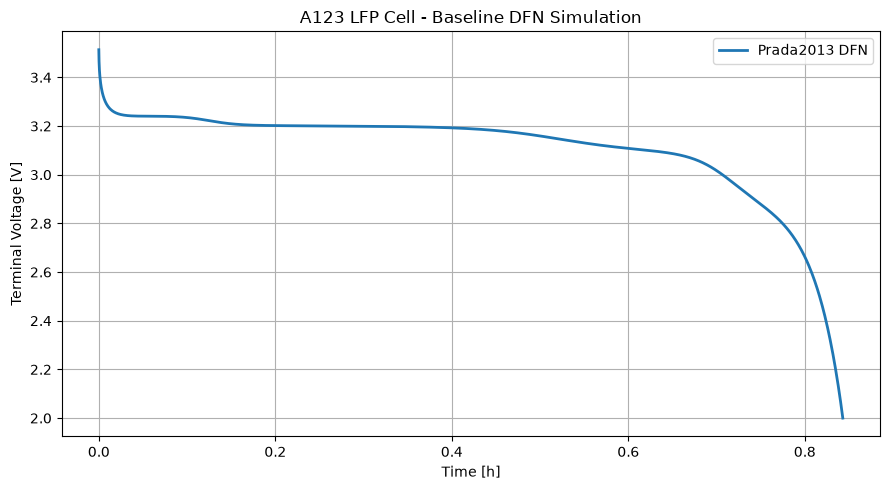


DFN simulation completed successfully.


In [1]:
# ============================================================
# A123 ANR26650M1B - LFP DFN MODEL
# Step 1: Baseline model construction
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PyBaMM version
# ------------------------------------------------------------
print("=" * 60)
print("A123 ANR26650M1B - DFN MODEL")
print("=" * 60)

print("PyBaMM version:", pybamm.__version__)

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------
model = pybamm.lithium_ion.DFN()

print("\nModel:")
print(model.name)

# ------------------------------------------------------------
# PARAMETER SET
# ------------------------------------------------------------
parameter_values = pybamm.ParameterValues("Prada2013")

print("\nParameter set: Prada2013")

# ------------------------------------------------------------
# IMPORTANT CELL PARAMETERS
# ------------------------------------------------------------
print("\nSelected parameters")
print("-" * 60)

print(
    "Nominal capacity:",
    parameter_values["Nominal cell capacity [A.h]"],
    "Ah"
)

print(
    "Lower voltage cutoff:",
    parameter_values["Lower voltage cut-off [V]"],
    "V"
)

print(
    "Upper voltage cutoff:",
    parameter_values["Upper voltage cut-off [V]"],
    "V"
)

print(
    "Reference temperature:",
    parameter_values["Reference temperature [K]"],
    "K"
)

# ------------------------------------------------------------
# ISOTHERMAL MODEL
# ------------------------------------------------------------
print("\nThermal effects: IGNORED")
print("Model type: Isothermal DFN")

# ------------------------------------------------------------
# BASELINE SIMULATION
# ------------------------------------------------------------
capacity = parameter_values["Nominal cell capacity [A.h]"]

# 1C discharge current
current_1C = capacity

parameter_values["Current function [A]"] = current_1C

print("\n1C current:", current_1C, "A")

# ------------------------------------------------------------
# CREATE SIMULATION
# ------------------------------------------------------------
sim = pybamm.Simulation(
    model=model,
    parameter_values=parameter_values
)

# ------------------------------------------------------------
# SOLVE
# ------------------------------------------------------------
t_eval = np.linspace(0, 3600, 500)

solution = sim.solve(t_eval=t_eval)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------
time = solution["Time [s]"].entries
voltage = solution["Terminal voltage [V]"].entries
current = solution["Current [A]"].entries

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    time / 3600,
    voltage,
    linewidth=2,
    label="Prada2013 DFN"
)

plt.xlabel("Time [h]")
plt.ylabel("Terminal Voltage [V]")
plt.title("A123 LFP Cell - Baseline DFN Simulation")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDFN simulation completed successfully.")

In [2]:
# ============================================================
# TASK 2
# HPPC SIMULATION AT A PARTICULAR SOC
#
# Cell: A123 ANR26650M1B
# Target capacity: 2.5 Ah
#
# Rates:
#     1C  = 2.5 A
#     5C  = 12.5 A
#     10C = 25.0 A
#     15C = 37.5 A
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ------------------------------------------------------------
# 1. Load HPPC data
# ------------------------------------------------------------

file_path = r"HPPC.mat"

data = loadmat(
    file_path,
    squeeze_me=True,
    struct_as_record=False
)

meas = data["meas"]

time = np.asarray(meas.Time, dtype=float)
voltage = np.asarray(meas.Voltage, dtype=float)
current = np.asarray(meas.Current, dtype=float)
ah = np.asarray(meas.Ah, dtype=float)

print("=" * 70)
print("HPPC DATA")
print("=" * 70)

print("Number of data points :", len(time))
print("Time [s]              :", time.min(), "to", time.max())
print("Voltage [V]            :", voltage.min(), "to", voltage.max())
print("Current [A]            :", current.min(), "to", current.max())
print("Ah range              :", ah.min(), "to", ah.max())

HPPC DATA
Number of data points : 55793
Time [s]              : 0.0 to 90702.03399807215
Voltage [V]            : 2.4999 to 3.5001
Current [A]            : -37.4989 to 19.9992
Ah range              : -2.4841 to 0.0039


In [3]:
# ------------------------------------------------------------
# 2. Target SOC
# ------------------------------------------------------------

Q_target = 2.5       # Ah
target_SOC = 0.80    # 80%

target_Ah = -(1 - target_SOC) * Q_target

print("\nTarget SOC :", target_SOC * 100, "%")
print("Target Ah  :", target_Ah, "Ah")


Target SOC : 80.0 %
Target Ah  : -0.4999999999999999 Ah


In [4]:
# ------------------------------------------------------------
# 3. Discharge rates
# ------------------------------------------------------------

rates = {
    "1C":  2.5,
    "5C":  12.5,
    "10C": 25.0,
    "15C": 37.5
}

print("\nDischarge rates:")
for rate, I in rates.items():
    print(f"{rate:>3} : {I:6.2f} A")


Discharge rates:
 1C :   2.50 A
 5C :  12.50 A
10C :  25.00 A
15C :  37.50 A


In [5]:
# ------------------------------------------------------------
# 4. Function to find a discharge pulse near target SOC
# ------------------------------------------------------------

def find_discharge_pulse(
    time,
    voltage,
    current,
    ah,
    target_ah,
    target_current,
    current_tolerance=0.15
):
    
    # Find points close to desired discharge current
    mask = (
        (current < 0) &
        (np.abs(current - (-target_current)) <= current_tolerance)
    )

    indices = np.where(mask)[0]

    if len(indices) == 0:
        raise ValueError(
            f"No pulse found for {target_current:.2f} A"
        )

    # Find contiguous groups
    groups = []

    start = indices[0]
    previous = indices[0]

    for idx in indices[1:]:

        if idx != previous + 1:
            groups.append((start, previous))
            start = idx

        previous = idx

    groups.append((start, previous))

    # Remove very short groups
    groups = [
        (s, e)
        for s, e in groups
        if (e - s + 1) >= 50
    ]

    if len(groups) == 0:
        raise ValueError(
            f"No sufficiently long pulse found for "
            f"{target_current:.2f} A"
        )

    # Select pulse whose STARTING Ah is closest to target Ah
    best_group = min(
        groups,
        key=lambda g: abs(ah[g[0]] - target_ah)
    )

    s, e = best_group

    return {
        "start_index": s,
        "end_index": e,
        "time": time[s:e+1],
        "voltage": voltage[s:e+1],
        "current": current[s:e+1],
        "ah": ah[s:e+1]
    }

In [6]:
# ------------------------------------------------------------
# 5. Extract 1C, 5C, 10C and 15C pulses
# ------------------------------------------------------------

pulses = {}

for rate, current_value in rates.items():

    pulse = find_discharge_pulse(
        time=time,
        voltage=voltage,
        current=current,
        ah=ah,
        target_ah=target_Ah,
        target_current=current_value
    )

    pulses[rate] = pulse

    print("\n" + "-" * 60)
    print(rate)

    print(
        "Start time      :",
        pulse["time"][0],
        "s"
    )

    print(
        "End time        :",
        pulse["time"][-1],
        "s"
    )

    print(
        "Starting Ah     :",
        pulse["ah"][0],
        "Ah"
    )

    print(
        "Starting SOC    :",
        (1 + pulse["ah"][0] / Q_target) * 100,
        "%"
    )

    print(
        "Measured current:",
        np.mean(pulse["current"]),
        "A"
    )

    print(
        "Number of points:",
        len(pulse["time"])
    )


------------------------------------------------------------
1C
Start time      : 19847.61699847877 s
End time        : 19857.532002031803 s
Starting Ah     : -0.5001 Ah
Starting SOC    : 79.996 %
Measured current: -2.497715841584159 A
Number of points: 101

------------------------------------------------------------
5C
Start time      : 20584.97700020671 s
End time        : 20594.876001030207 s
Starting Ah     : -0.5003 Ah
Starting SOC    : 79.988 %
Measured current: -12.49813069306931 A
Number of points: 101

------------------------------------------------------------
10C
Start time      : 21490.630999580026 s
End time        : 21500.527998805046 s
Starting Ah     : -0.5007 Ah
Starting SOC    : 79.972 %
Measured current: -24.999208910891095 A
Number of points: 101

------------------------------------------------------------
15C
Start time      : 22632.12799653411 s
End time        : 22642.022994160652 s
Starting Ah     : -0.5011 Ah
Starting SOC    : 79.956 %
Measured current: -37

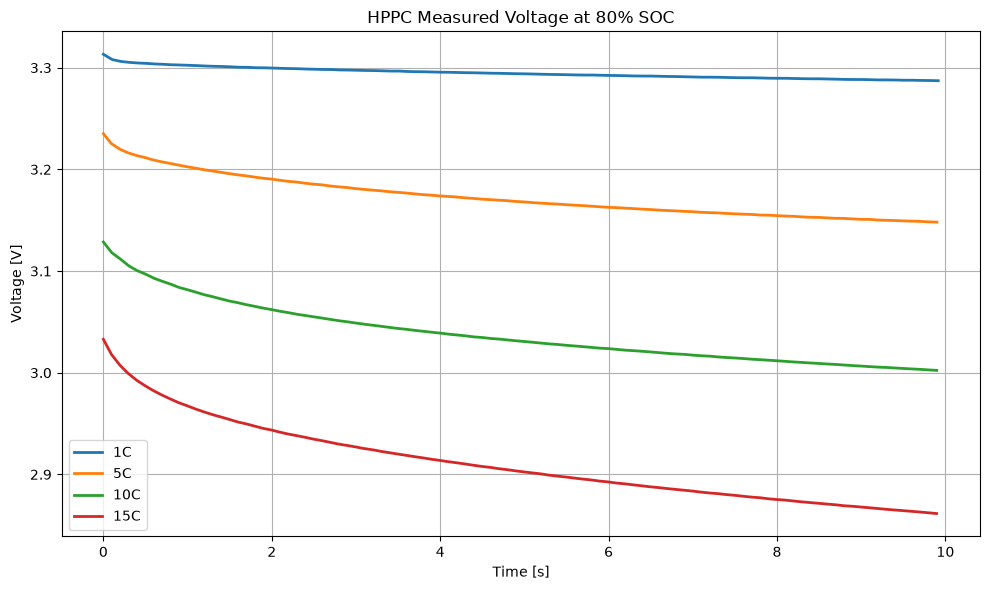

In [7]:
# ------------------------------------------------------------
# 6. Plot measured voltage response
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for rate, pulse in pulses.items():

    t_relative = pulse["time"] - pulse["time"][0]

    plt.plot(
        t_relative,
        pulse["voltage"],
        linewidth=2,
        label=rate
    )

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("HPPC Measured Voltage at 80% SOC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

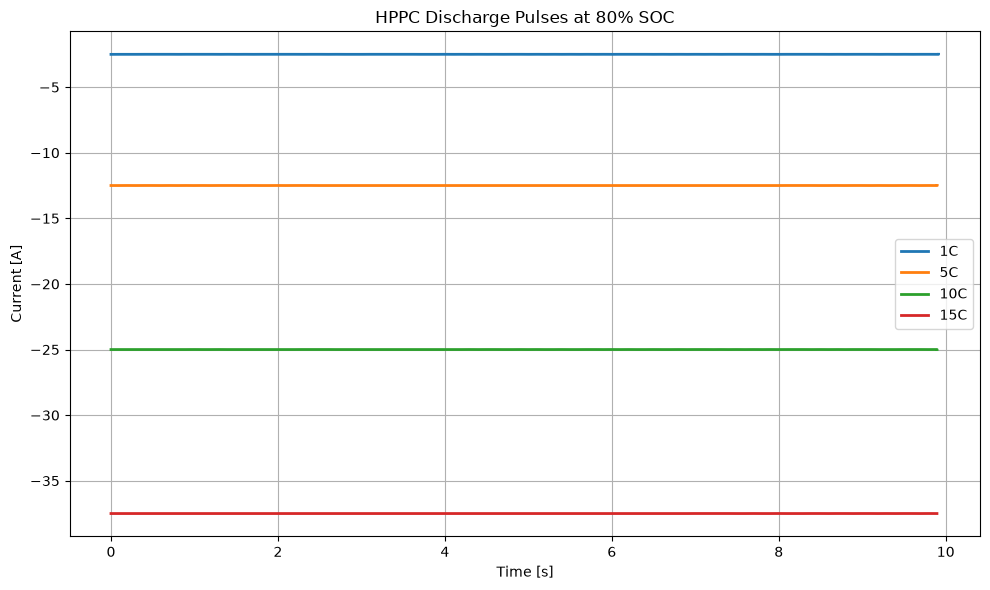

In [8]:
# ------------------------------------------------------------
# 7. Plot measured current pulses
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for rate, pulse in pulses.items():

    t_relative = pulse["time"] - pulse["time"][0]

    plt.plot(
        t_relative,
        pulse["current"],
        linewidth=2,
        label=rate
    )

plt.xlabel("Time [s]")
plt.ylabel("Current [A]")
plt.title("HPPC Discharge Pulses at 80% SOC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# RE-RUN DFN SIMULATION WITH PROPER TIME INTERPOLATION
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt

simulation_results = {}

model = pybamm.lithium_ion.DFN()

for rate, pulse in pulses.items():

    print("\n" + "=" * 60)
    print(f"Simulating {rate}")
    print("=" * 60)

    # Experimental relative time
    t_exp = pulse["time"] - pulse["time"][0]

    # Experimental convention:
    # discharge current = negative
    #
    # PyBaMM convention:
    # discharge current = positive
    current_pybamm = -pulse["current"]

    # Current interpolation
    current_function = pybamm.Interpolant(
        t_exp,
        current_pybamm,
        pybamm.t,
        name=f"HPPC_{rate}"
    )

    # Load fresh Prada2013 parameters
    params = pybamm.ParameterValues("Prada2013")

    # Apply HPPC current
    params["Current function [A]"] = current_function

    # Create simulation
    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    # Solve
    solution = sim.solve(
        t_eval=t_exp,
        initial_soc=0.80
    )

    # PyBaMM solver time
    t_sim = solution.t

    # Raw simulated voltage
    voltage_sim_raw = solution[
        "Terminal voltage [V]"
    ].entries

    # --------------------------------------------------------
    # Interpolate simulated voltage onto experimental points
    # --------------------------------------------------------

    voltage_sim = np.interp(
        t_exp,
        t_sim,
        voltage_sim_raw
    )

    # Store results
    simulation_results[rate] = {
        "time": t_exp,
        "voltage_measured": pulse["voltage"],
        "voltage_simulated": voltage_sim,
        "voltage_simulated_raw": voltage_sim_raw,
        "time_sim": t_sim,
        "current": pulse["current"]
    }

    print("Experimental points :", len(t_exp))
    print("DFN solver points   :", len(t_sim))
    print("Comparison points   :", len(voltage_sim))
    print("Simulation completed.")


Simulating 1C
Experimental points : 101
DFN solver points   : 653
Comparison points   : 101
Simulation completed.

Simulating 5C
Experimental points : 101
DFN solver points   : 689
Comparison points   : 101
Simulation completed.

Simulating 10C
Experimental points : 101
DFN solver points   : 716
Comparison points   : 101
Simulation completed.

Simulating 15C
Experimental points : 101
DFN solver points   : 741
Comparison points   : 101
Simulation completed.


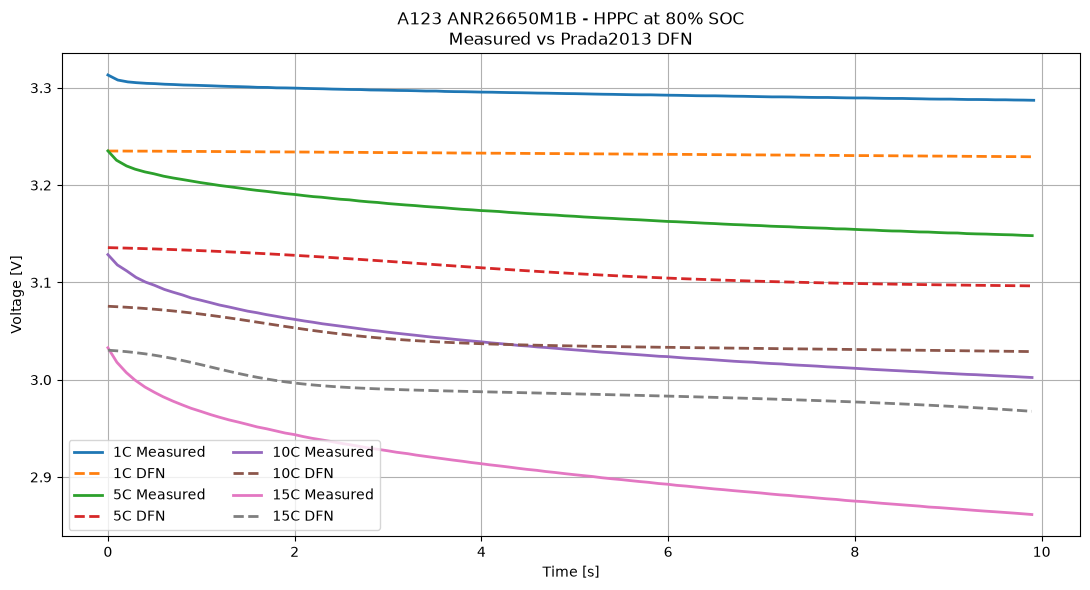

In [10]:
# ============================================================
# MEASURED VS SIMULATED VOLTAGE
# ============================================================

plt.figure(figsize=(11, 6))

for rate, result in simulation_results.items():

    plt.plot(
        result["time"],
        result["voltage_measured"],
        linewidth=2,
        label=f"{rate} Measured"
    )

    plt.plot(
        result["time"],
        result["voltage_simulated"],
        "--",
        linewidth=2,
        label=f"{rate} DFN"
    )

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")

plt.title(
    "A123 ANR26650M1B - HPPC at 80% SOC\n"
    "Measured vs Prada2013 DFN"
)

plt.grid(True)
plt.legend(ncol=2)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# ERROR METRICS FOR 1C / 5C / 10C / 15C
# ============================================================

print("=" * 70)
print("BASELINE Prada2013 DFN ERROR - 80% SOC")
print("=" * 70)

print(
    f"{'Rate':<10}"
    f"{'RMSE [V]':<15}"
    f"{'MAE [V]':<15}"
    f"{'Max Error [V]':<15}"
)

print("-" * 55)

rmse_results = {}
mae_results = {}
max_error_results = {}

for rate, result in simulation_results.items():

    measured = np.asarray(
        result["voltage_measured"]
    )

    simulated = np.asarray(
        result["voltage_simulated"]
    )

    residual = measured - simulated

    rmse = np.sqrt(
        np.mean(residual**2)
    )

    mae = np.mean(
        np.abs(residual)
    )

    max_error = np.max(
        np.abs(residual)
    )

    rmse_results[rate] = rmse
    mae_results[rate] = mae
    max_error_results[rate] = max_error

    print(
        f"{rate:<10}"
        f"{rmse:<15.6f}"
        f"{mae:<15.6f}"
        f"{max_error:<15.6f}"
    )

BASELINE Prada2013 DFN ERROR - 80% SOC
Rate      RMSE [V]       MAE [V]        Max Error [V]  
-------------------------------------------------------
1C        0.062698       0.062583       0.078142       
5C        0.060973       0.060452       0.099409       
10C       0.016706       0.013719       0.053090       
15C       0.081393       0.077684       0.106044       


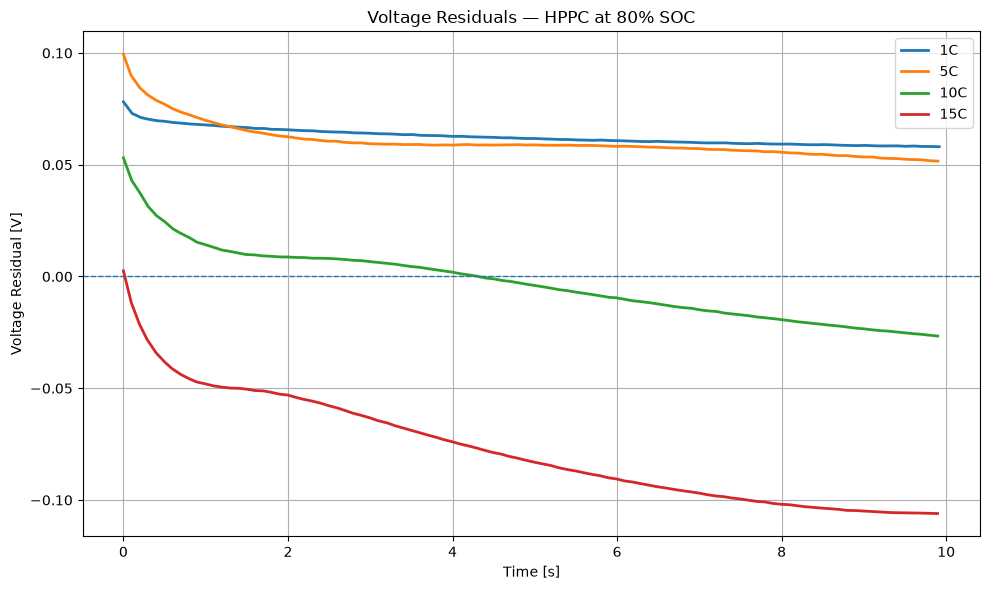

In [12]:
# ============================================================
# RESIDUALS
# Residual = Measured - Simulated
# ============================================================

plt.figure(figsize=(10, 6))

for rate, result in simulation_results.items():

    residual = (
        result["voltage_measured"]
        -
        result["voltage_simulated"]
    )

    plt.plot(
        result["time"],
        residual,
        linewidth=2,
        label=rate
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage Residual [V]")

plt.title(
    "Voltage Residuals — HPPC at 80% SOC"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# COMPLETE HPPC ANALYSIS AT ONE SOC
# Target SOC = 80%
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Target SOC
# ------------------------------------------------------------

Q_target = 2.5       # Ah
target_SOC = 0.80

target_Ah = -(1 - target_SOC) * Q_target

print("=" * 70)
print("HPPC ANALYSIS")
print("=" * 70)

print(f"Target SOC : {target_SOC*100:.1f}%")
print(f"Target Ah  : {target_Ah:.4f} Ah")

HPPC ANALYSIS
Target SOC : 80.0%
Target Ah  : -0.5000 Ah


In [14]:
# ============================================================
# FIND REGION AROUND 80% SOC
# ============================================================

# Window around target Ah
ah_window = 0.10   # Ah

mask_soc = (
    (ah >= target_Ah - ah_window) &
    (ah <= target_Ah + ah_window)
)

indices_soc = np.where(mask_soc)[0]

if len(indices_soc) == 0:
    raise ValueError("Could not find data around 80% SOC.")

i_start = indices_soc[0]
i_end = indices_soc[-1]

print("Start index :", i_start)
print("End index   :", i_end)

print("Start time  :", time[i_start], "s")
print("End time    :", time[i_end], "s")

print(
    "SOC range   :",
    (1 + ah[i_start]/Q_target)*100,
    "to",
    (1 + ah[i_end]/Q_target)*100,
    "%"
)

Start index : 11692
End index   : 15749
Start time  : 17566.053000837564 s
End time    : 24469.401998072863 s
SOC range   : 83.92399999999999 to 76.004 %


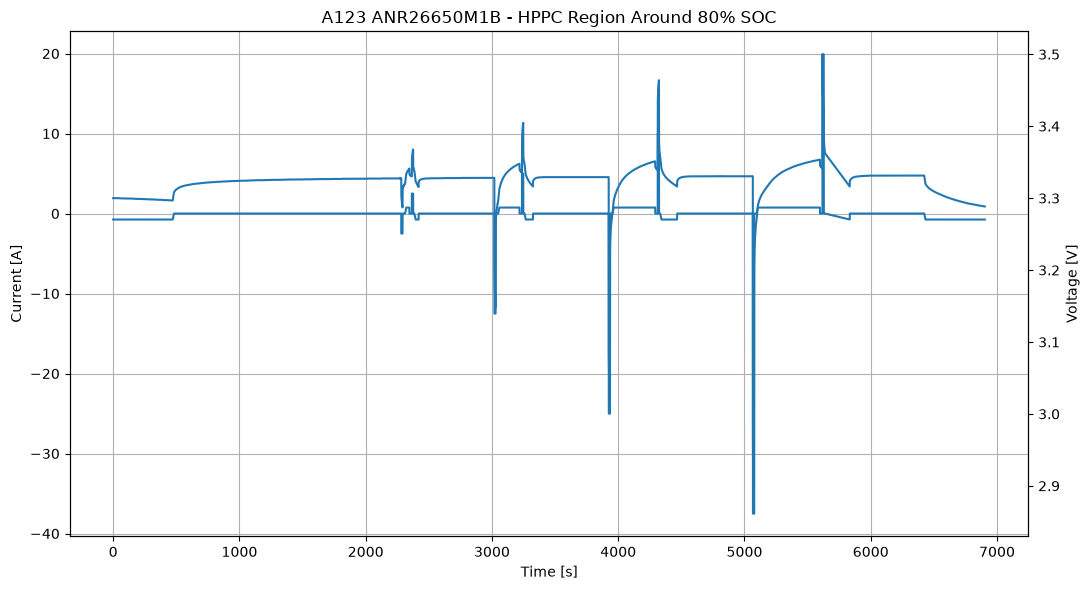

In [15]:
# ============================================================
# COMPLETE HPPC PROFILE AROUND 80% SOC
# ============================================================

t_region = time[i_start:i_end+1]
I_region = current[i_start:i_end+1]
V_region = voltage[i_start:i_end+1]

t_region_rel = t_region - t_region[0]

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    t_region_rel,
    I_region,
    linewidth=1.5
)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Current [A]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    t_region_rel,
    V_region,
    linewidth=1.5
)

ax2.set_ylabel("Voltage [V]")

plt.title(
    "A123 ANR26650M1B - HPPC Region Around 80% SOC"
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# IDENTIFY CURRENT PULSES
# ============================================================

# Current threshold to distinguish pulse from rest
current_threshold = 0.5  # A

active = np.abs(I_region) > current_threshold

# Find transitions
transitions = np.diff(active.astype(int))

pulse_starts = np.where(transitions == 1)[0] + 1
pulse_ends = np.where(transitions == -1)[0]

# Handle if profile starts during a pulse
if active[0]:
    pulse_starts = np.insert(pulse_starts, 0, 0)

# Handle if profile ends during a pulse
if active[-1]:
    pulse_ends = np.append(
        pulse_ends,
        len(active) - 1
    )

print("\n" + "=" * 70)
print("IDENTIFIED HPPC PULSES")
print("=" * 70)

pulse_list = []

for n, (s, e) in enumerate(
    zip(pulse_starts, pulse_ends),
    start=1
):

    duration = t_region[s:e+1][-1] - t_region[s:e+1][0]

    mean_current = np.mean(
        I_region[s:e+1]
    )

    start_ah = ah[i_start + s]

    start_soc = (
        1 + start_ah / Q_target
    ) * 100

    pulse_list.append({
        "number": n,
        "start": s,
        "end": e,
        "duration": duration,
        "current": mean_current,
        "ah": start_ah,
        "soc": start_soc
    })

    print(
        f"Pulse {n:2d} | "
        f"I = {mean_current:8.3f} A | "
        f"Duration = {duration:6.2f} s | "
        f"SOC = {start_soc:7.3f}%"
    )


IDENTIFIED HPPC PULSES
Pulse  1 | I =   -0.749 A | Duration = 471.41 s | SOC =  83.924%
Pulse  2 | I =   -2.498 A | Duration =   9.92 s | SOC =  79.996%
Pulse  3 | I =    0.747 A | Duration =  23.80 s | SOC =  79.804%
Pulse  4 | I =    2.497 A | Duration =   9.91 s | SOC =  80.004%
Pulse  5 | I =   -0.748 A | Duration =  23.35 s | SOC =  80.196%
Pulse  6 | I =  -12.498 A | Duration =   9.90 s | SOC =  79.988%
Pulse  7 | I =    0.747 A | Duration = 158.71 s | SOC =  78.680%
Pulse  8 | I =    4.999 A | Duration =   9.89 s | SOC =  80.008%
Pulse  9 | I =   -0.749 A | Duration =  56.79 s | SOC =  80.472%
Pulse 10 | I =  -24.999 A | Duration =   9.90 s | SOC =  79.972%
Pulse 11 | I =    0.747 A | Duration = 328.00 s | SOC =  77.276%
Pulse 12 | I =    9.997 A | Duration =   9.90 s | SOC =  80.012%
Pulse 13 | I =   -0.749 A | Duration = 123.33 s | SOC =  81.028%
Pulse 14 | I =  -37.498 A | Duration =   9.89 s | SOC =  79.956%
Pulse 15 | I =    0.747 A | Duration = 491.51 s | SOC =  75.920%
P

In [17]:
# ============================================================
# ASSIGN APPROXIMATE C-RATE
# ============================================================

C_capacity = 2.5  # Ah

for pulse in pulse_list:

    current_abs = abs(pulse["current"])

    C_rate = current_abs / C_capacity

    if pulse["current"] < 0:
        direction = "Discharge"
    else:
        direction = "Charge"

    pulse["C_rate"] = C_rate
    pulse["direction"] = direction

    print(
        f"Pulse {pulse['number']:2d}: "
        f"{direction:9s} | "
        f"{C_rate:6.2f}C | "
        f"{pulse['current']:8.3f} A"
    )

Pulse  1: Discharge |   0.30C |   -0.749 A
Pulse  2: Discharge |   1.00C |   -2.498 A
Pulse  3: Charge    |   0.30C |    0.747 A
Pulse  4: Charge    |   1.00C |    2.497 A
Pulse  5: Discharge |   0.30C |   -0.748 A
Pulse  6: Discharge |   5.00C |  -12.498 A
Pulse  7: Charge    |   0.30C |    0.747 A
Pulse  8: Charge    |   2.00C |    4.999 A
Pulse  9: Discharge |   0.30C |   -0.749 A
Pulse 10: Discharge |  10.00C |  -24.999 A
Pulse 11: Charge    |   0.30C |    0.747 A
Pulse 12: Charge    |   4.00C |    9.997 A
Pulse 13: Discharge |   0.30C |   -0.749 A
Pulse 14: Discharge |  15.00C |  -37.498 A
Pulse 15: Charge    |   0.30C |    0.747 A
Pulse 16: Charge    |   5.85C |   14.630 A
Pulse 17: Discharge |   0.30C |   -0.750 A
Pulse 18: Discharge |   0.30C |   -0.749 A


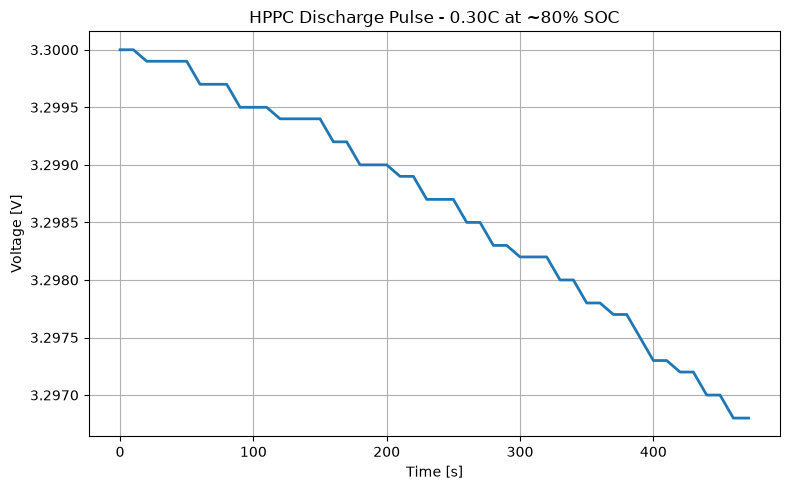

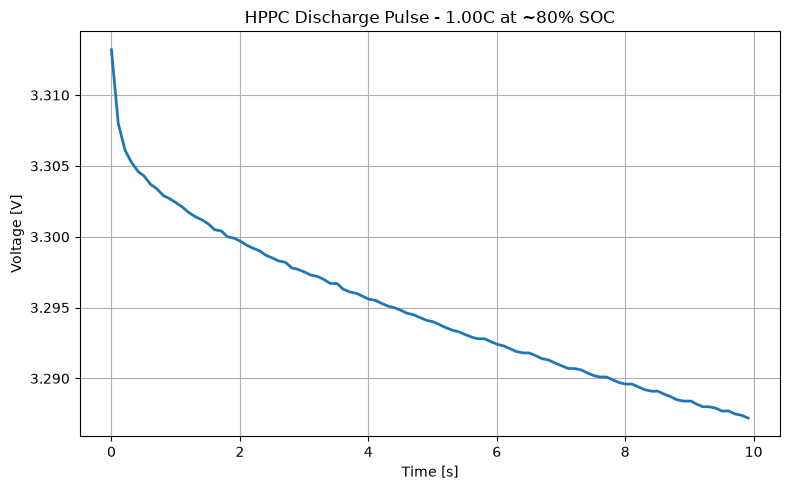

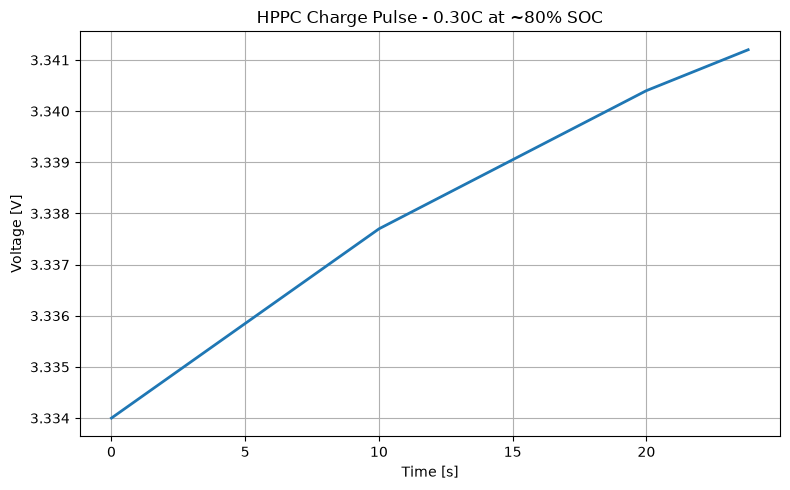

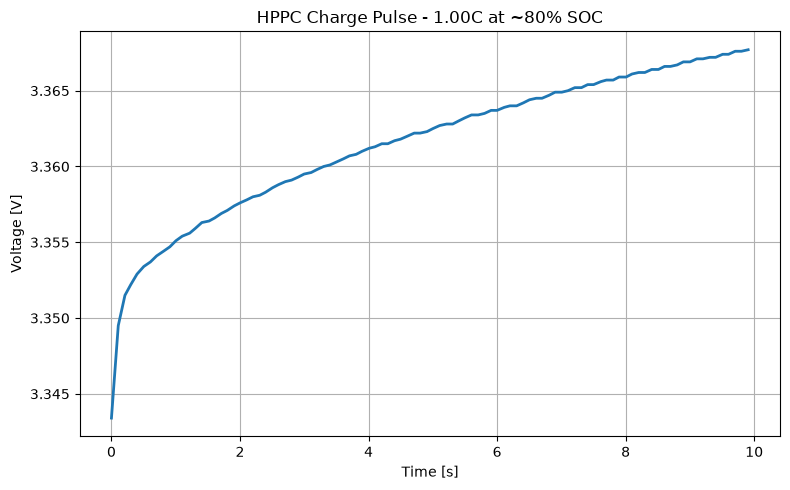

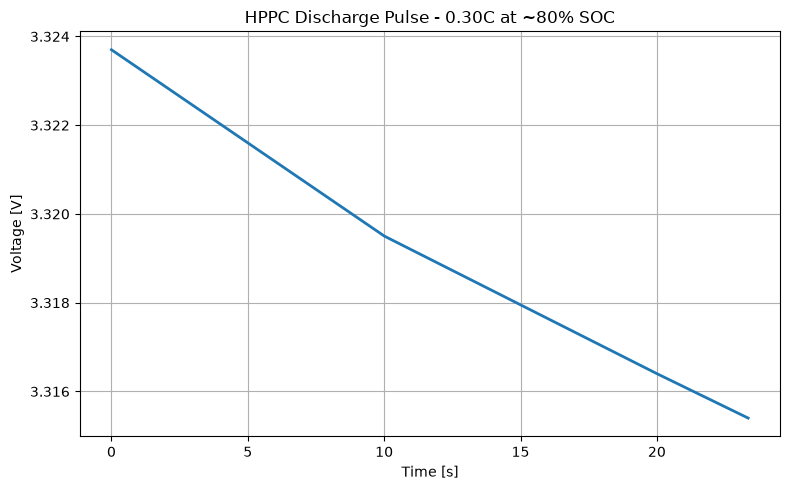

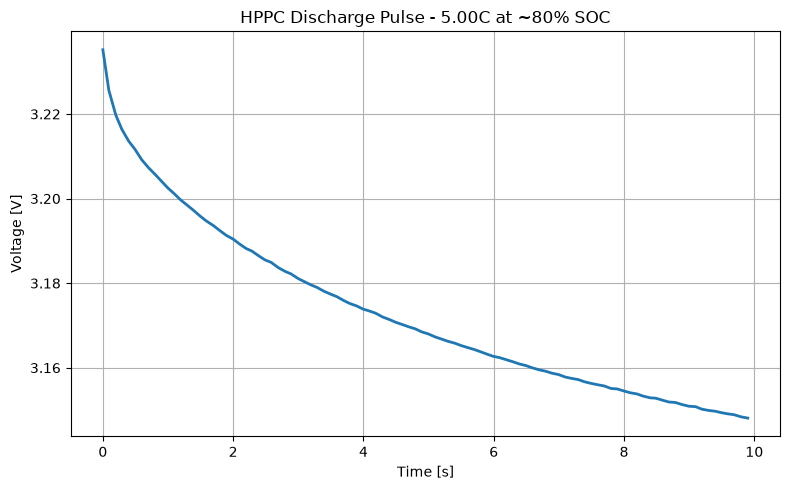

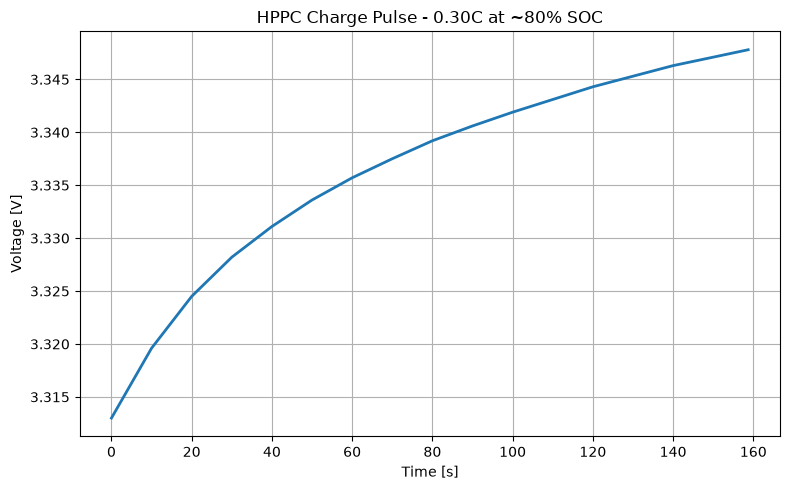

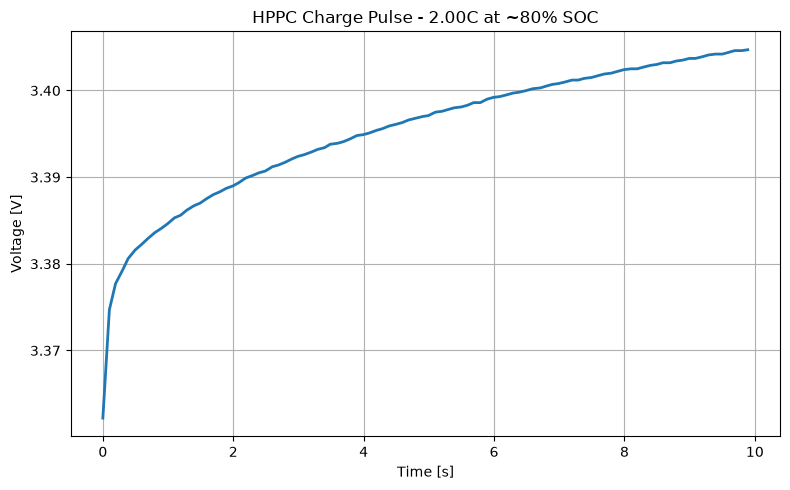

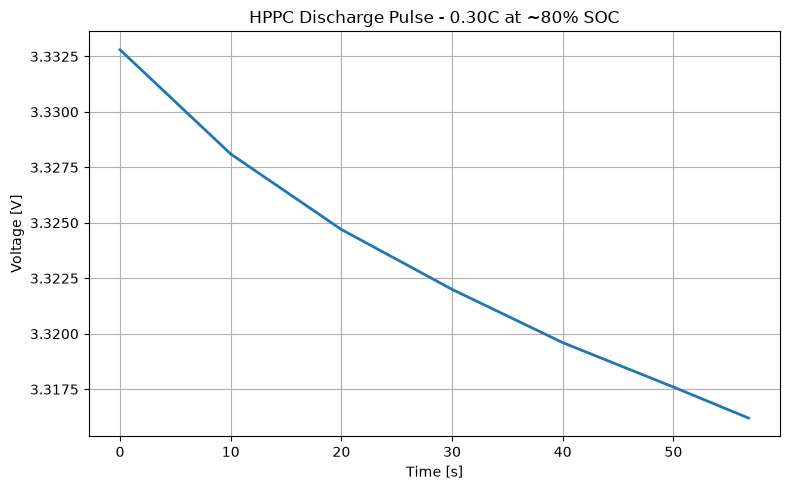

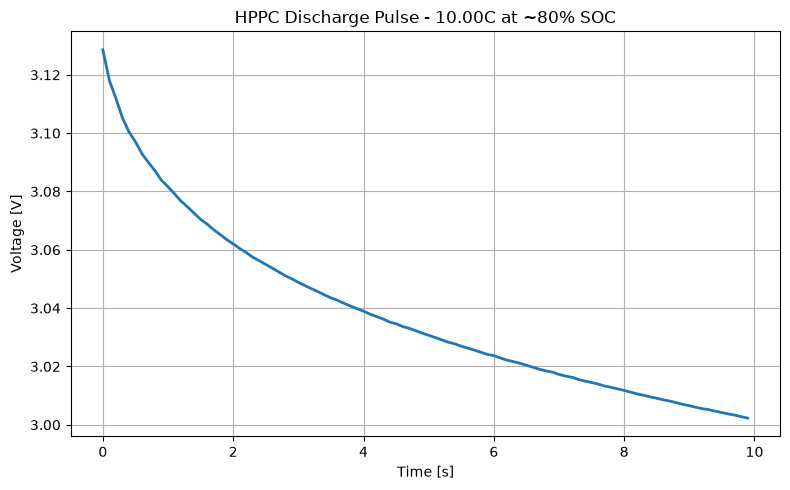

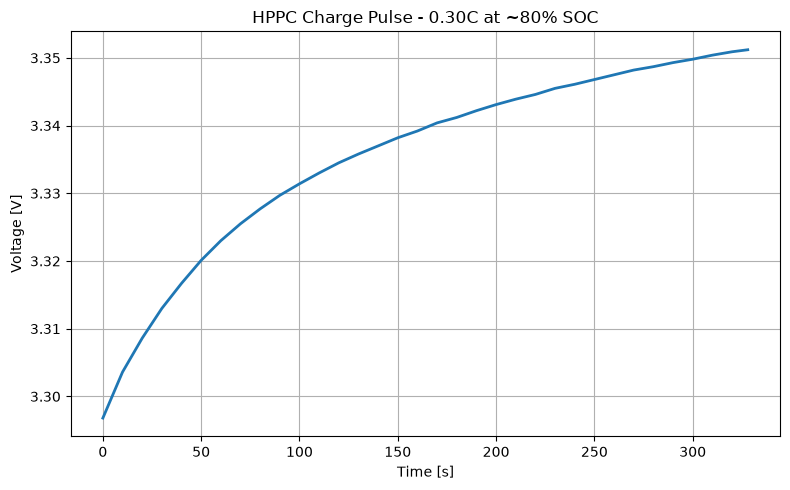

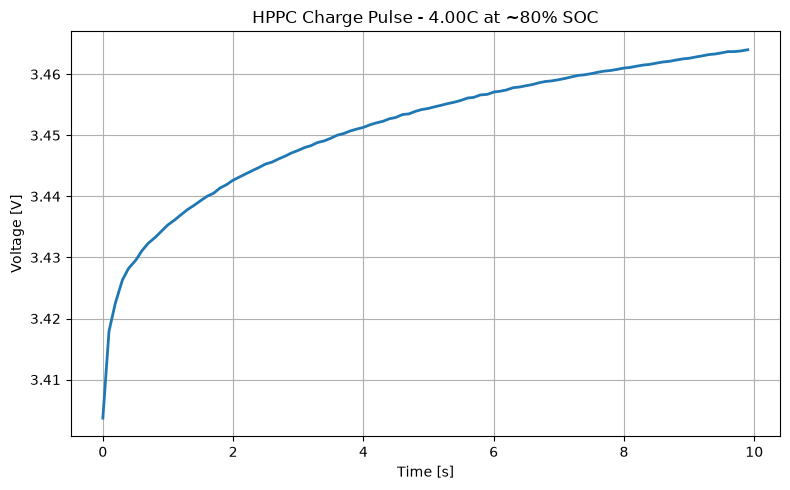

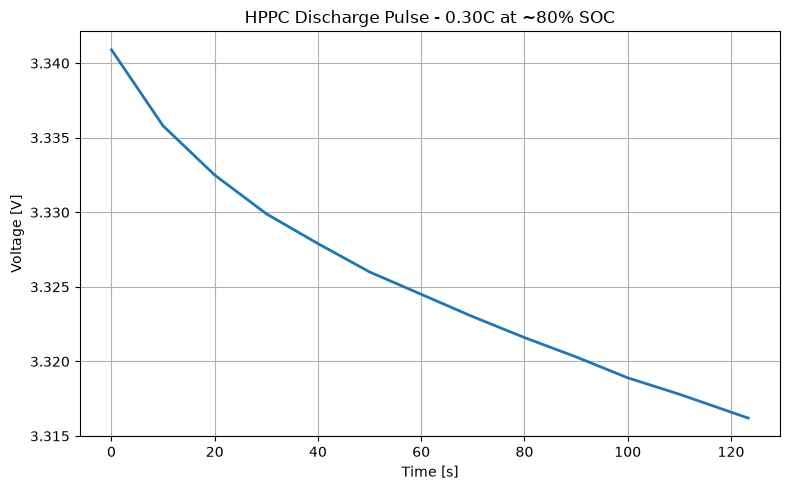

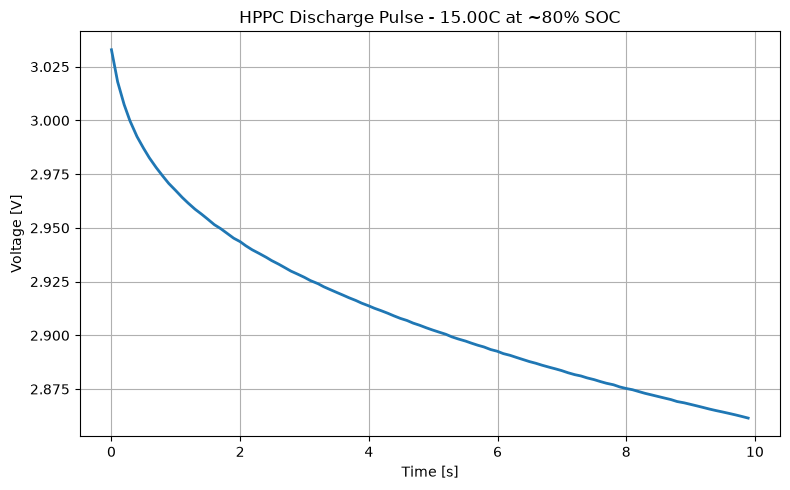

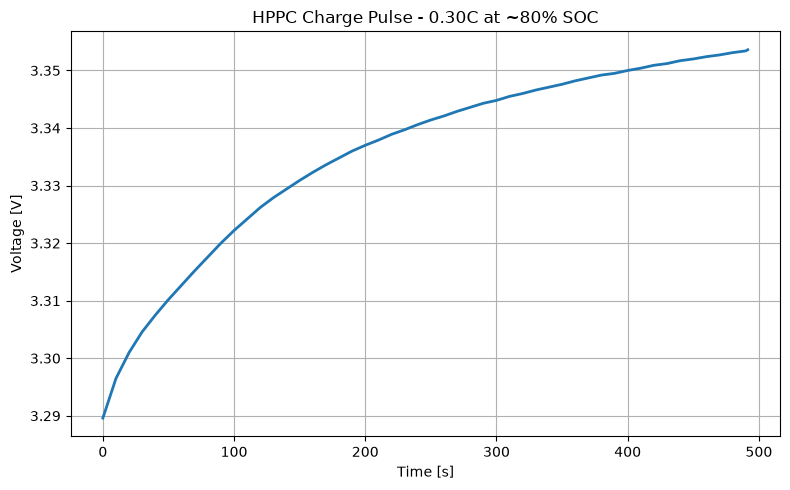

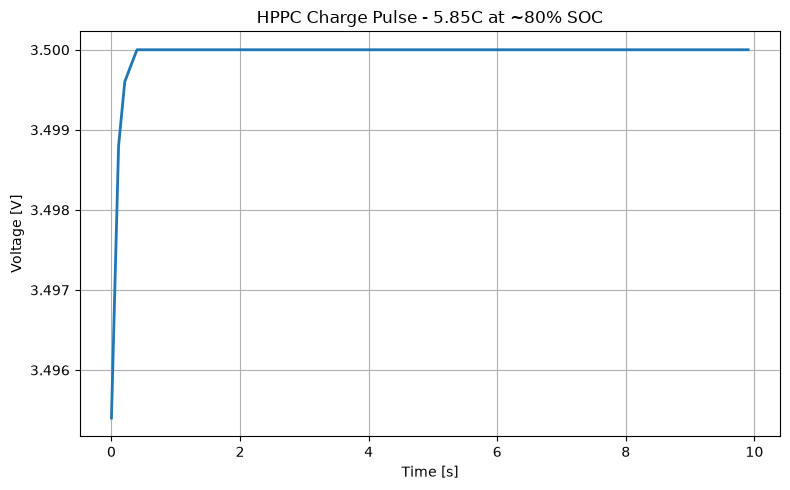

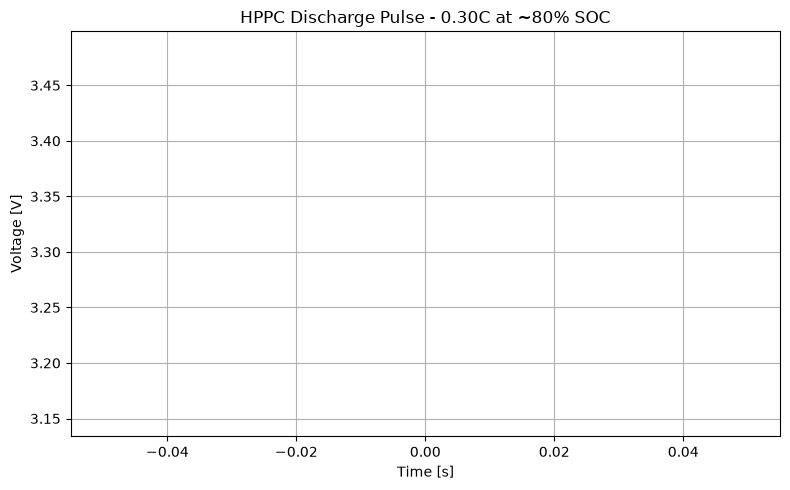

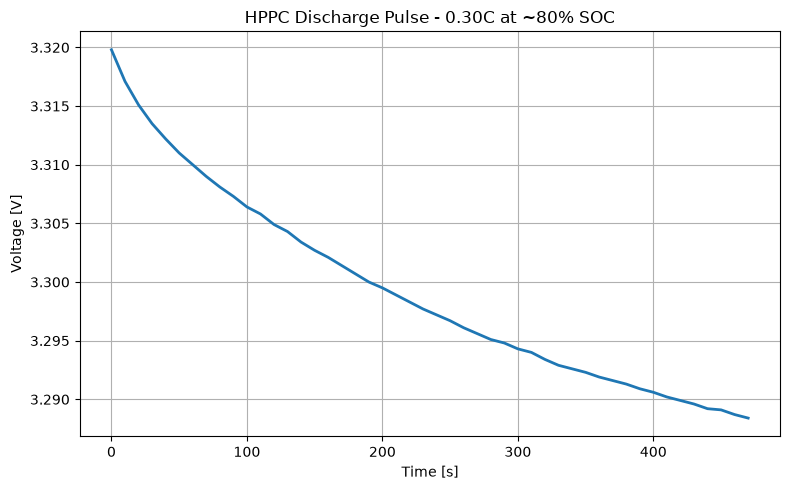

In [18]:
# ============================================================
# INDIVIDUAL HPPC PULSE VOLTAGE RESPONSES
# ============================================================

for pulse in pulse_list:

    s = pulse["start"]
    e = pulse["end"]

    t_pulse = (
        t_region[s:e+1]
        -
        t_region[s]
    )

    V_pulse = V_region[s:e+1]

    C_rate = pulse["C_rate"]
    direction = pulse["direction"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        t_pulse,
        V_pulse,
        linewidth=2
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Voltage [V]")

    plt.title(
        f"HPPC {direction} Pulse - "
        f"{C_rate:.2f}C at ~80% SOC"
    )

    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# IDENTIFY VALID HPPC PULSES AROUND 80% SOC
# ============================================================

current_threshold = 0.5  # A

active = np.abs(I_region) > current_threshold

# Find transitions
transitions = np.diff(active.astype(int))

pulse_starts = np.where(transitions == 1)[0] + 1
pulse_ends = np.where(transitions == -1)[0]

# Handle region starting inside a pulse
if active[0]:
    pulse_starts = np.insert(
        pulse_starts,
        0,
        0
    )

# Handle region ending inside a pulse
if active[-1]:
    pulse_ends = np.append(
        pulse_ends,
        len(active) - 1
    )

# ============================================================
# Keep only physically meaningful pulses
# ============================================================

pulse_list = []

pulse_number = 0

for s, e in zip(pulse_starts, pulse_ends):

    n_points = e - s + 1

    duration = (
        t_region[e] -
        t_region[s]
    )

    mean_current = np.mean(
        I_region[s:e+1]
    )

    # --------------------------------------------------------
    # Reject very short segments
    # --------------------------------------------------------
    
    if n_points < 10:
        continue

    if duration < 1.0:
        continue

    # --------------------------------------------------------
    # Calculate SOC
    # --------------------------------------------------------

    start_ah = ah[i_start + s]

    start_soc = (
        1 +
        start_ah / Q_target
    ) * 100

    # --------------------------------------------------------
    # Calculate C-rate
    # --------------------------------------------------------

    C_rate = (
        abs(mean_current) /
        C_capacity
    )

    if mean_current < 0:
        direction = "Discharge"
    else:
        direction = "Charge"

    pulse_number += 1

    pulse_list.append({

        "number": pulse_number,

        "start": s,

        "end": e,

        "duration": duration,

        "current": mean_current,

        "ah": start_ah,

        "soc": start_soc,

        "C_rate": C_rate,

        "direction": direction
    })


# ============================================================
# PRINT VALID PULSES
# ============================================================

print("\n" + "=" * 85)
print("VALID HPPC PULSES AROUND 80% SOC")
print("=" * 85)

print(
    f"{'Pulse':<8}"
    f"{'Direction':<12}"
    f"{'Current [A]':<15}"
    f"{'C-rate':<10}"
    f"{'SOC [%]':<12}"
    f"{'Duration [s]':<15}"
    f"{'Points':<10}"
)

print("-" * 85)

for pulse in pulse_list:

    n_points = (
        pulse["end"] -
        pulse["start"] +
        1
    )

    print(
        f"{pulse['number']:<8}"
        f"{pulse['direction']:<12}"
        f"{pulse['current']:<15.3f}"
        f"{pulse['C_rate']:<10.2f}"
        f"{pulse['soc']:<12.3f}"
        f"{pulse['duration']:<15.3f}"
        f"{n_points:<10}"
    )


VALID HPPC PULSES AROUND 80% SOC
Pulse   Direction   Current [A]    C-rate    SOC [%]     Duration [s]   Points    
-------------------------------------------------------------------------------------
1       Discharge   -0.749         0.30      83.924      471.414        49        
2       Discharge   -2.498         1.00      79.996      9.915          101       
3       Charge      2.497          1.00      80.004      9.906          101       
4       Discharge   -12.498        5.00      79.988      9.899          101       
5       Charge      0.747          0.30      78.680      158.711        17        
6       Charge      4.999          2.00      80.008      9.891          101       
7       Discharge   -24.999        10.00     79.972      9.897          101       
8       Charge      0.747          0.30      77.276      327.999        34        
9       Charge      9.997          4.00      80.012      9.900          101       
10      Discharge   -0.749         0.30      81.02

In [20]:
# ============================================================
# DFN SIMULATION OF VALID HPPC PULSES
# ============================================================

model = pybamm.lithium_ion.DFN()

simulation_results_hppc = {}

for pulse in pulse_list:

    n = pulse["number"]

    s = pulse["start"]
    e = pulse["end"]

    # --------------------------------------------------------
    # Extract pulse
    # --------------------------------------------------------

    t_exp = (
        t_region[s:e+1]
        -
        t_region[s]
    )

    I_exp = I_region[s:e+1]

    V_exp = V_region[s:e+1]

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if len(t_exp) < 2:
        print(
            f"Skipping pulse {n}: "
            f"only {len(t_exp)} time point(s)."
        )
        continue

    # --------------------------------------------------------
    # Convert current convention
    #
    # Experimental:
    #     discharge = negative
    #
    # PyBaMM:
    #     discharge = positive
    # --------------------------------------------------------

    I_pybamm = -I_exp

    # --------------------------------------------------------
    # Current function
    # --------------------------------------------------------

    current_function = pybamm.Interpolant(
        t_exp,
        I_pybamm,
        pybamm.t,
        name=f"HPPC_pulse_{n}"
    )

    # --------------------------------------------------------
    # Fresh Prada2013 parameter set
    # --------------------------------------------------------

    params = pybamm.ParameterValues(
        "Prada2013"
    )

    params["Current function [A]"] = (
        current_function
    )

    # --------------------------------------------------------
    # Create simulation
    # --------------------------------------------------------

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    # --------------------------------------------------------
    # Solve
    # --------------------------------------------------------

    print(
        f"\nSimulating pulse {n}: "
        f"{pulse['direction']} "
        f"{pulse['C_rate']:.2f}C"
    )

    sol = sim.solve(
        t_eval=t_exp,
        initial_soc=target_SOC
    )

    # --------------------------------------------------------
    # DFN solution
    # --------------------------------------------------------

    t_sim = sol.t

    V_sim_raw = sol[
        "Terminal voltage [V]"
    ].entries

    # --------------------------------------------------------
    # Interpolate DFN voltage onto experimental time
    # --------------------------------------------------------

    V_sim = np.interp(
        t_exp,
        t_sim,
        V_sim_raw
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    simulation_results_hppc[n] = {

        "time": t_exp,

        "current": I_exp,

        "voltage_measured": V_exp,

        "voltage_simulated": V_sim,

        "C_rate": pulse["C_rate"],

        "direction": pulse["direction"],

        "SOC": pulse["soc"],

        "duration": pulse["duration"]
    }

    print(
        f"Completed: "
        f"{len(t_exp)} experimental points"
    )


Simulating pulse 1: Discharge 0.30C
Completed: 49 experimental points

Simulating pulse 2: Discharge 1.00C
Completed: 101 experimental points

Simulating pulse 3: Charge 1.00C
Completed: 101 experimental points

Simulating pulse 4: Discharge 5.00C
Completed: 101 experimental points

Simulating pulse 5: Charge 0.30C
Completed: 17 experimental points

Simulating pulse 6: Charge 2.00C
Completed: 101 experimental points

Simulating pulse 7: Discharge 10.00C
Completed: 101 experimental points

Simulating pulse 8: Charge 0.30C
Completed: 34 experimental points

Simulating pulse 9: Charge 4.00C
Completed: 101 experimental points

Simulating pulse 10: Discharge 0.30C
Completed: 14 experimental points

Simulating pulse 11: Discharge 15.00C
Completed: 101 experimental points

Simulating pulse 12: Charge 0.30C
Completed: 51 experimental points

Simulating pulse 13: Charge 5.85C
Completed: 101 experimental points

Simulating pulse 14: Discharge 0.30C
Completed: 48 experimental points


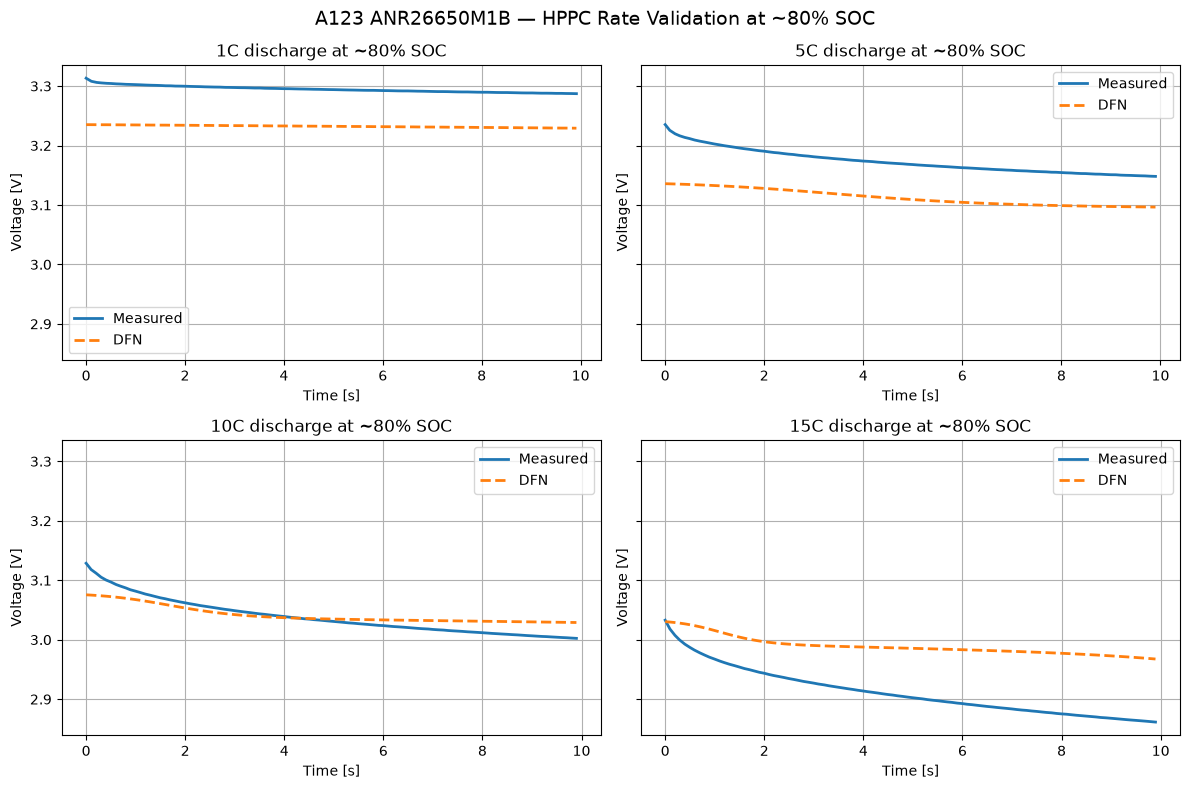

In [21]:
# ============================================================
# CLEAN 1C / 5C / 10C / 15C COMPARISON
# ~80% SOC
# ============================================================

rates_to_plot = ["1C", "5C", "10C", "15C"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=False,
    sharey=True
)

for ax, rate in zip(axes.flat, rates_to_plot):

    result = simulation_results[rate]

    ax.plot(
        result["time"],
        result["voltage_measured"],
        linewidth=2,
        label="Measured"
    )

    ax.plot(
        result["time"],
        result["voltage_simulated"],
        "--",
        linewidth=2,
        label="DFN"
    )

    ax.set_title(f"{rate} discharge at ~80% SOC")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Voltage [V]")
    ax.grid(True)
    ax.legend()

fig.suptitle(
    "A123 ANR26650M1B — HPPC Rate Validation at ~80% SOC",
    fontsize=14
)

plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# COMPLETE HPPC SIMULATION AT ~80% SOC
# CONTINUOUS CURRENT PROFILE
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Experimental HPPC time
# ------------------------------------------------------------

t_hppc = t_region - t_region[0]

I_hppc = I_region

V_hppc = V_region

# ------------------------------------------------------------
# Check data
# ------------------------------------------------------------

print("HPPC points :", len(t_hppc))
print("Time start  :", t_hppc[0], "s")
print("Time end    :", t_hppc[-1], "s")
print("Duration    :", t_hppc[-1] - t_hppc[0], "s")

print(
    "Current range:",
    np.min(I_hppc),
    "to",
    np.max(I_hppc),
    "A"
)

HPPC points : 4058
Time start  : 0.0 s
Time end    : 6903.348997235298 s
Duration    : 6903.348997235298 s
Current range: -37.4989 to 19.9049 A


In [23]:
# ============================================================
# CONTINUOUS DFN HPPC SIMULATION
# ============================================================

model = pybamm.lithium_ion.DFN()

params = pybamm.ParameterValues(
    "Prada2013"
)

# Experimental convention:
# discharge = negative
#
# PyBaMM convention:
# discharge = positive

I_pybamm = -I_hppc

current_function = pybamm.Interpolant(
    t_hppc,
    I_pybamm,
    pybamm.t,
    name="Complete_HPPC_Current"
)

params["Current function [A]"] = current_function

sim = pybamm.Simulation(
    model=model,
    parameter_values=params
)

print("Starting continuous DFN HPPC simulation...")

solution = sim.solve(
    t_eval=t_hppc,
    initial_soc=0.80
)

print("DFN HPPC simulation completed.")

Starting continuous DFN HPPC simulation...
DFN HPPC simulation completed.


In [24]:
# ============================================================
# COMPLETE HPPC CURRENT PROFILE
# SAME CURRENT USED FOR EXPERIMENT AND DFN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pybamm

# ------------------------------------------------------------
# Experimental HPPC profile
# ------------------------------------------------------------

t_hppc = np.asarray(t_region) - t_region[0]
I_exp = np.asarray(I_region)
V_exp = np.asarray(V_region)

# ------------------------------------------------------------
# Check initial SOC
# ------------------------------------------------------------

soc_start = (
    1 + ah[i_start] / Q_target
)

print("=" * 70)
print("HPPC INITIAL CONDITION")
print("=" * 70)

print(f"Experimental starting SOC : {soc_start*100:.3f} %")
print(f"DFN starting SOC          : {soc_start*100:.3f} %")
print(f"Number of points          : {len(t_hppc)}")
print(f"Total duration             : {t_hppc[-1]:.2f} s")
print(f"Current range              : {I_exp.min():.3f} to {I_exp.max():.3f} A")

HPPC INITIAL CONDITION
Experimental starting SOC : 83.924 %
DFN starting SOC          : 83.924 %
Number of points          : 4058
Total duration             : 6903.35 s
Current range              : -37.499 to 19.905 A


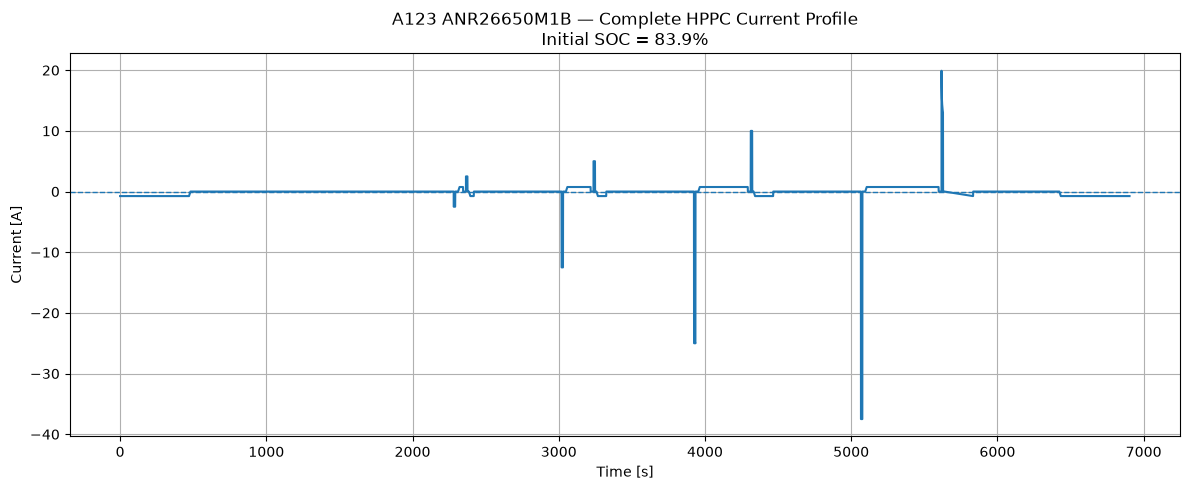

In [25]:
# ============================================================
# HPPC CURRENT PROFILE USED AS DFN INPUT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    I_exp,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Current [A]")

plt.title(
    "A123 ANR26650M1B — Complete HPPC Current Profile\n"
    f"Initial SOC = {soc_start*100:.1f}%"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
I_pybamm = -I_exp

In [27]:
# ============================================================
# CONTINUOUS DFN SIMULATION
# SAME HPPC CURRENT PROFILE
# STARTING FROM SAME SOC
# ============================================================

model = pybamm.lithium_ion.DFN()

params = pybamm.ParameterValues(
    "Prada2013"
)

# ------------------------------------------------------------
# Convert experimental current to PyBaMM convention
# ------------------------------------------------------------

I_pybamm = -I_exp

# ------------------------------------------------------------
# Create continuous current function
# ------------------------------------------------------------

current_function = pybamm.Interpolant(
    t_hppc,
    I_pybamm,
    pybamm.t,
    name="Measured_HPPC_Current"
)

params["Current function [A]"] = current_function

# ------------------------------------------------------------
# Create DFN simulation
# ------------------------------------------------------------

sim = pybamm.Simulation(
    model=model,
    parameter_values=params
)

print("Running continuous DFN HPPC simulation...")
print(
    f"Initial DFN SOC = {soc_start*100:.3f}%"
)

# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------

solution = sim.solve(
    t_eval=t_hppc,
    initial_soc=soc_start
)

print("DFN simulation completed.")

Running continuous DFN HPPC simulation...
Initial DFN SOC = 83.924%
DFN simulation completed.


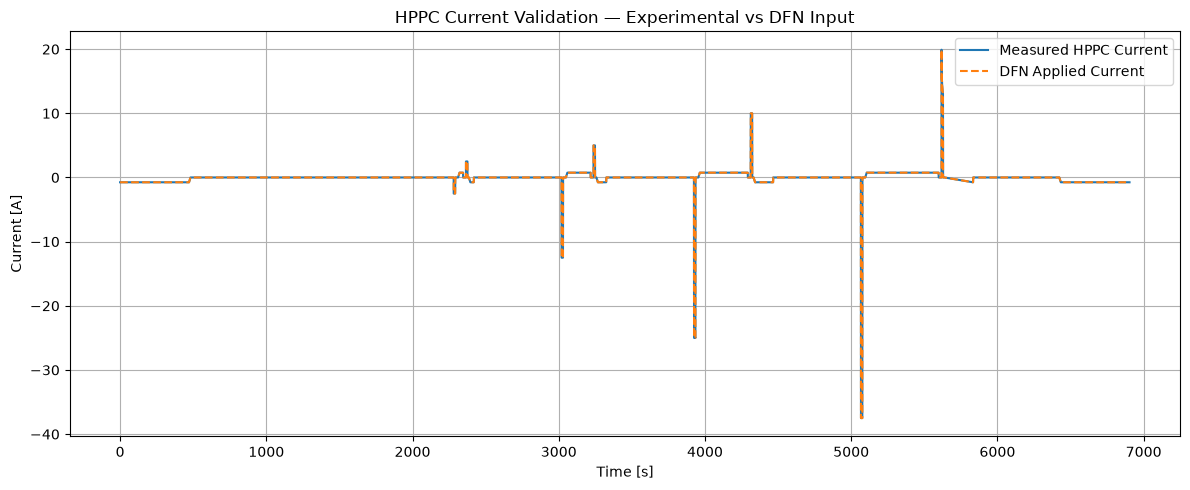

In [28]:
# ============================================================
# VERIFY EXPERIMENTAL CURRENT VS DFN CURRENT
# ============================================================

t_dfn = solution.t

I_dfn = solution[
    "Current [A]"
].entries

# Interpolate DFN current to experimental time
I_dfn_interp = np.interp(
    t_hppc,
    t_dfn,
    I_dfn
)

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    I_exp,
    linewidth=1.5,
    label="Measured HPPC Current"
)

plt.plot(
    t_hppc,
    -I_dfn_interp,
    "--",
    linewidth=1.5,
    label="DFN Applied Current"
)

plt.xlabel("Time [s]")
plt.ylabel("Current [A]")

plt.title(
    "HPPC Current Validation — Experimental vs DFN Input"
)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# EXTRACT DFN VOLTAGE
# ============================================================

V_dfn_raw = solution[
    "Terminal voltage [V]"
].entries

# Interpolate onto experimental time points
V_dfn = np.interp(
    t_hppc,
    t_dfn,
    V_dfn_raw
)

print("Measured voltage points :", len(V_exp))
print("DFN voltage points      :", len(V_dfn))

Measured voltage points : 4058
DFN voltage points      : 4058


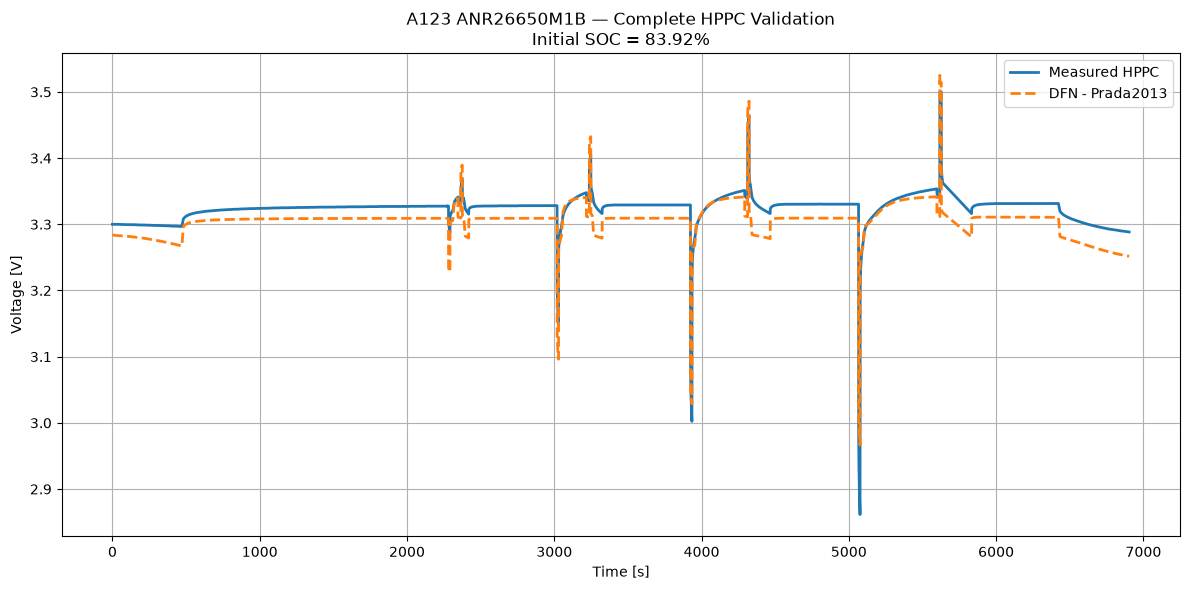

In [30]:
# ============================================================
# PART 2 - MAIN RESULT
# COMPLETE HPPC VOLTAGE VALIDATION AT ~80% SOC
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    t_hppc,
    V_exp,
    linewidth=2,
    label="Measured HPPC"
)

plt.plot(
    t_hppc,
    V_dfn,
    "--",
    linewidth=2,
    label="DFN - Prada2013"
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")

plt.title(
    "A123 ANR26650M1B — Complete HPPC Validation\n"
    f"Initial SOC = {soc_start*100:.2f}%"
)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# MAIN HPPC ERROR METRICS
# ============================================================

hpcc_error = V_exp - V_dfn

hpcc_rmse = np.sqrt(
    np.mean(hpcc_error**2)
)

hpcc_mae = np.mean(
    np.abs(hpcc_error)
)

hpcc_max_error = np.max(
    np.abs(hpcc_error)
)

print("=" * 65)
print("PART 2 - COMPLETE HPPC VALIDATION")
print("=" * 65)

print(f"Initial SOC       : {soc_start*100:.3f} %")
print(f"RMSE              : {hpcc_rmse:.6f} V")
print(f"MAE               : {hpcc_mae:.6f} V")
print(f"Maximum error     : {hpcc_max_error:.6f} V")

PART 2 - COMPLETE HPPC VALIDATION
Initial SOC       : 83.924 %
RMSE              : 0.030515 V
MAE               : 0.025352 V
Maximum error     : 0.105087 V


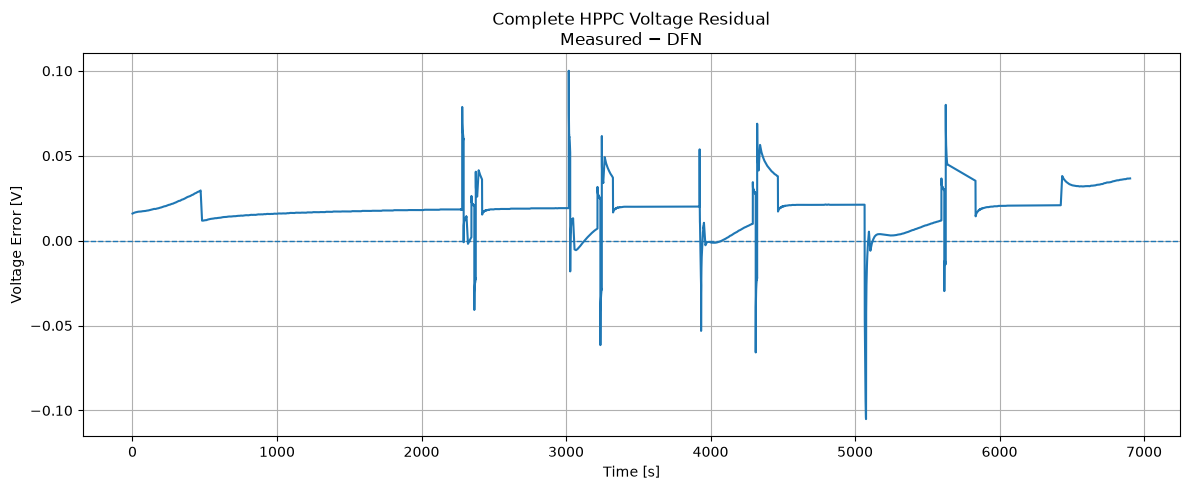

In [32]:
# ============================================================
# HPPC VOLTAGE RESIDUAL
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    hpcc_error,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage Error [V]")

plt.title(
    "Complete HPPC Voltage Residual\n"
    "Measured − DFN"
)

plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# PART 3.1 - RESIDUAL ANALYSIS
# COMPLETE HPPC AT ~80% SOC
# ============================================================

residual = V_exp - V_dfn

print("=" * 75)
print("RESIDUAL ANALYSIS - COMPLETE HPPC")
print("=" * 75)

print(f"Mean residual       : {np.mean(residual):.6f} V")
print(f"Std. residual        : {np.std(residual):.6f} V")
print(f"RMSE                 : {np.sqrt(np.mean(residual**2)):.6f} V")
print(f"MAE                  : {np.mean(np.abs(residual)):.6f} V")
print(f"Maximum abs. error   : {np.max(np.abs(residual)):.6f} V")

RESIDUAL ANALYSIS - COMPLETE HPPC
Mean residual       : 0.014311 V
Std. residual        : 0.026951 V
RMSE                 : 0.030515 V
MAE                  : 0.025352 V
Maximum abs. error   : 0.105087 V


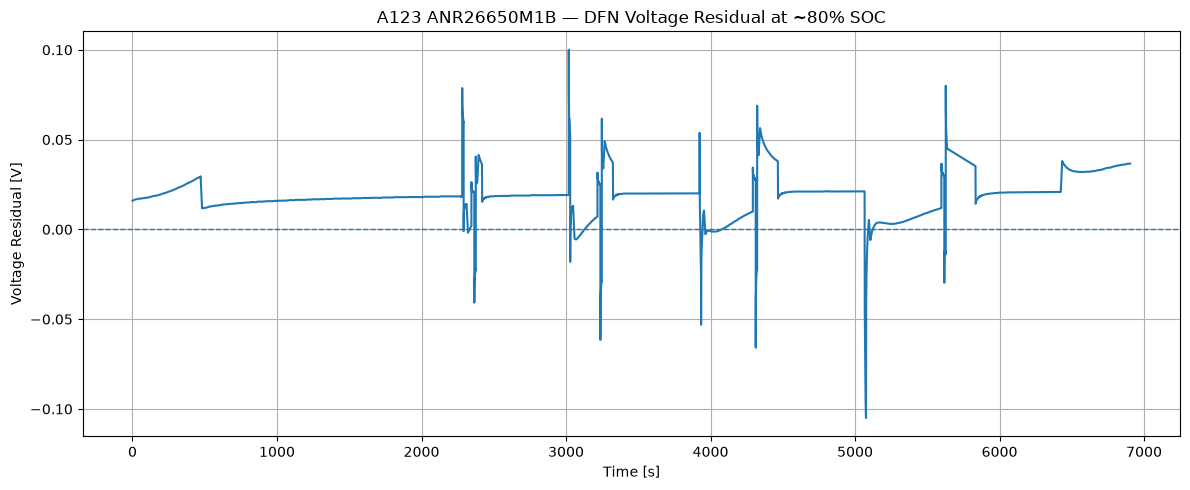

In [34]:
# ============================================================
# RESIDUAL VS TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    residual,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage Residual [V]")

plt.title(
    "A123 ANR26650M1B — DFN Voltage Residual at ~80% SOC"
)

plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# RATE-WISE RESIDUAL ANALYSIS
# ============================================================

rates = ["1C", "5C", "10C", "15C"]

print("=" * 75)
print("RATE-WISE RESIDUAL ANALYSIS")
print("=" * 75)

print(
    f"{'Rate':<10}"
    f"{'Mean Error [V]':<18}"
    f"{'RMSE [V]':<15}"
    f"{'MAE [V]':<15}"
    f"{'Max |Error| [V]':<18}"
)

print("-" * 75)

rate_residual_results = {}

for rate in rates:

    result = simulation_results[rate]

    measured = np.asarray(
        result["voltage_measured"]
    )

    simulated = np.asarray(
        result["voltage_simulated"]
    )

    error = measured - simulated

    mean_error = np.mean(error)

    rmse = np.sqrt(
        np.mean(error**2)
    )

    mae = np.mean(
        np.abs(error)
    )

    max_error = np.max(
        np.abs(error)
    )

    rate_residual_results[rate] = {
        "error": error,
        "mean": mean_error,
        "rmse": rmse,
        "mae": mae,
        "max": max_error
    }

    print(
        f"{rate:<10}"
        f"{mean_error:<18.6f}"
        f"{rmse:<15.6f}"
        f"{mae:<15.6f}"
        f"{max_error:<18.6f}"
    )

RATE-WISE RESIDUAL ANALYSIS
Rate      Mean Error [V]    RMSE [V]       MAE [V]        Max |Error| [V]   
---------------------------------------------------------------------------
1C        0.062583          0.062698       0.062583       0.078142          
5C        0.060452          0.060973       0.060452       0.099409          
10C       -0.003263         0.016706       0.013719       0.053090          
15C       -0.077634         0.081393       0.077684       0.106044          


In [36]:
# ============================================================
# SHOW RELEVANT Prada2013 PARAMETERS
# ============================================================

params = pybamm.ParameterValues("Prada2013")

keywords = [
    "capacity",
    "open circuit",
    "OCP",
    "diffusivity",
    "exchange-current",
    "reaction",
    "electrolyte",
    "porosity",
    "thickness"
]

for name in params.keys():

    name_lower = name.lower()

    if any(
        key.lower() in name_lower
        for key in keywords
    ):
        print(name)

Negative electrode thickness [m]
Separator thickness [m]
Positive electrode thickness [m]
Nominal cell capacity [A.h]
Negative particle diffusivity [m2.s-1]
Negative electrode OCP [V]
Negative electrode porosity
Negative electrode Bruggeman coefficient (electrolyte)
Negative electrode double-layer capacity [F.m-2]
Negative electrode exchange-current density [A.m-2]
Negative electrode OCP entropic change [V.K-1]
Positive particle diffusivity [m2.s-1]
Positive electrode OCP [V]
Positive electrode porosity
Positive electrode Bruggeman coefficient (electrolyte)
Positive electrode double-layer capacity [F.m-2]
Positive electrode exchange-current density [A.m-2]
Positive electrode OCP entropic change [V.K-1]
Separator porosity
Separator Bruggeman coefficient (electrolyte)
Initial concentration in electrolyte [mol.m-3]
Electrolyte diffusivity [m2.s-1]
Electrolyte conductivity [S.m-1]


In [37]:
# Inspect the OCP functions in Prada2013

params = pybamm.ParameterValues("Prada2013")

negative_ocp = params["Negative electrode OCP [V]"]
positive_ocp = params["Positive electrode OCP [V]"]

print("Negative electrode OCP:")
print(negative_ocp)

print("\nPositive electrode OCP:")
print(positive_ocp)

Negative electrode OCP:
<function graphite_LGM50_ocp_Chen2020 at 0x00000239CF86D4E0>

Positive electrode OCP:
<function LFP_ocp_Afshar2017 at 0x00000239CF86D620>


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Residual
# ---------------------------------------------------------
residual = V_exp - V_dfn

# Experimental current
I = I_exp

# Define approximately "rest" points
# Adjust threshold if required based on your HPPC profile
rest_mask = np.abs(I) < 0.05

# Pulse / non-rest points
pulse_mask = ~rest_mask


# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------
rest_residual = residual[rest_mask]
pulse_residual = residual[pulse_mask]

print("================================================")
print("RESIDUAL ANALYSIS")
print("================================================")

print(f"Overall RMSE : {np.sqrt(np.mean(residual**2)):.6f} V")
print(f"Overall MAE  : {np.mean(np.abs(residual)):.6f} V")

print("\nRest regions:")
print(f"Mean residual : {np.mean(rest_residual):.6f} V")
print(f"MAE           : {np.mean(np.abs(rest_residual)):.6f} V")
print(f"Std           : {np.std(rest_residual):.6f} V")

print("\nPulse regions:")
print(f"Mean residual : {np.mean(pulse_residual):.6f} V")
print(f"MAE           : {np.mean(np.abs(pulse_residual)):.6f} V")
print(f"RMSE          : {np.sqrt(np.mean(pulse_residual**2)):.6f} V")
print(f"Max error     : {np.max(np.abs(pulse_residual)):.6f} V")

RESIDUAL ANALYSIS
Overall RMSE : 0.030515 V
Overall MAE  : 0.025352 V

Rest regions:
Mean residual : 0.019668 V
MAE           : 0.022027 V
Std           : 0.015244 V

Pulse regions:
Mean residual : -0.001293 V
MAE           : 0.035037 V
RMSE          : 0.042896 V
Max error     : 0.105087 V


In [39]:
print(params["Negative electrode OCP [V]"])
print(params["Positive electrode OCP [V]"])

<function graphite_LGM50_ocp_Chen2020 at 0x00000239CF86D4E0>
<function LFP_ocp_Afshar2017 at 0x00000239CF86D620>


REST VOLTAGE ANALYSIS
Number of rest points : 3021
Mean residual         : 0.019668 V
MAE                   : 0.022027 V
RMSE                  : 0.024884 V
Maximum error         : 0.079971 V


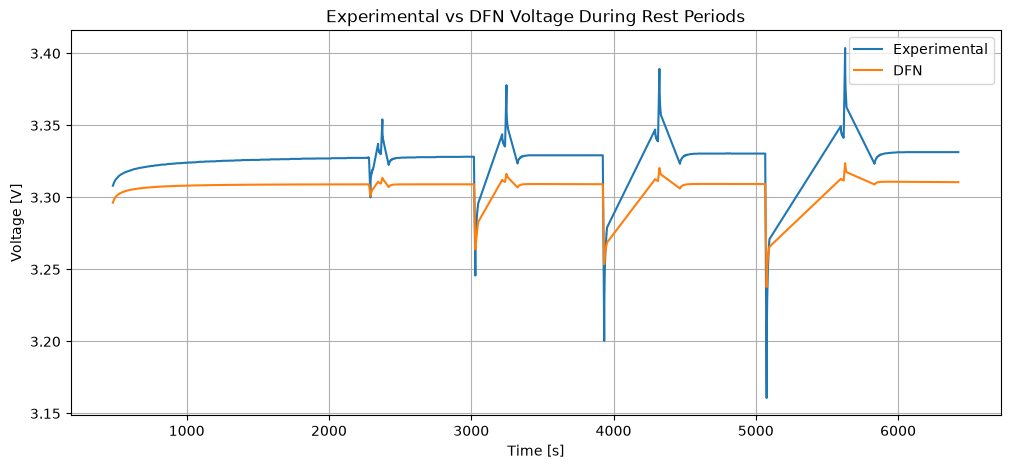

In [40]:
# ============================================================
# REST-VOLTAGE RESIDUAL ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Voltage residual
residual = V_exp - V_dfn

# Rest condition
rest_mask = np.abs(I_exp) < 0.05

# Extract rest points
t_rest = t_hppc[rest_mask]
V_exp_rest = V_exp[rest_mask]
V_dfn_rest = V_dfn[rest_mask]
R_rest = residual[rest_mask]

print("================================================")
print("REST VOLTAGE ANALYSIS")
print("================================================")

print(f"Number of rest points : {len(R_rest)}")
print(f"Mean residual         : {np.mean(R_rest):.6f} V")
print(f"MAE                   : {np.mean(np.abs(R_rest)):.6f} V")
print(f"RMSE                  : {np.sqrt(np.mean(R_rest**2)):.6f} V")
print(f"Maximum error         : {np.max(np.abs(R_rest)):.6f} V")

# Plot experimental vs DFN during rest
plt.figure(figsize=(12, 5))

plt.plot(t_rest, V_exp_rest, label="Experimental")
plt.plot(t_rest, V_dfn_rest, label="DFN")

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Experimental vs DFN Voltage During Rest Periods")
plt.legend()
plt.grid(True)

plt.show()

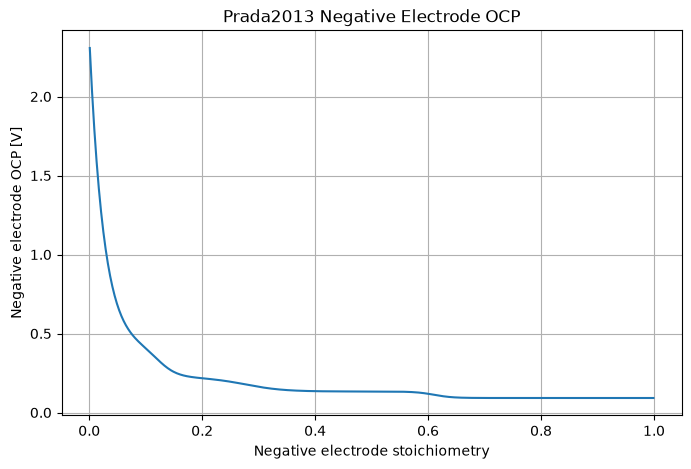

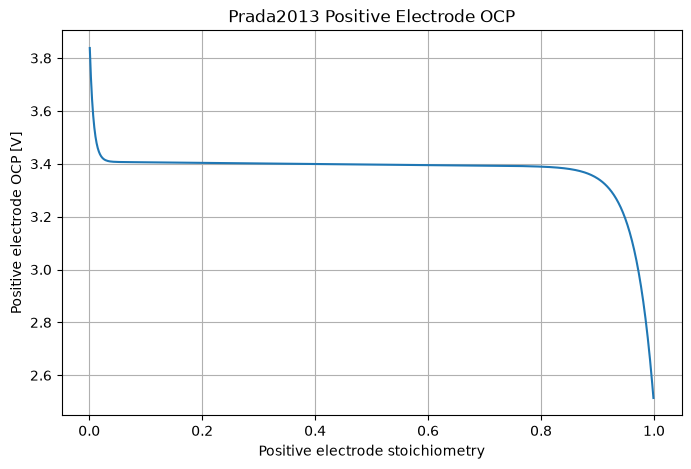

In [41]:
import numpy as np
import matplotlib.pyplot as plt

params = pybamm.ParameterValues("Prada2013")

neg_ocp = params["Negative electrode OCP [V]"]
pos_ocp = params["Positive electrode OCP [V]"]

# Stoichiometry range
x = np.linspace(0.001, 0.999, 500)

# Evaluate OCP functions
U_n = neg_ocp(x)
U_p = pos_ocp(x)

# ---------------------------------------------------------
# Negative electrode OCP
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(x, U_n)

plt.xlabel("Negative electrode stoichiometry")
plt.ylabel("Negative electrode OCP [V]")
plt.title("Prada2013 Negative Electrode OCP")
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# Positive electrode OCP
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(x, U_p)

plt.xlabel("Positive electrode stoichiometry")
plt.ylabel("Positive electrode OCP [V]")
plt.title("Prada2013 Positive Electrode OCP")
plt.grid(True)

plt.show()

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RATE-WISE RESIDUAL ANALYSIS
# ============================================================

residual = V_exp - V_dfn

# Experimental discharge current is negative
target_currents = {
    "1C": -2.5,
    "5C": -12.5,
    "10C": -25.0,
    "15C": -37.5
}

# Allow ±10% around nominal current
tolerance = 0.10

rate_results = {}

for rate, target in target_currents.items():

    # Select points close to target current
    mask = np.abs(I_exp - target) <= abs(target) * tolerance

    indices = np.where(mask)[0]

    # Find continuous segments
    segments = []

    if len(indices) > 0:

        start = indices[0]
        previous = indices[0]

        for idx in indices[1:]:

            if idx != previous + 1:
                segments.append((start, previous))
                start = idx

            previous = idx

        segments.append((start, previous))

    # Keep segments long enough to represent a pulse
    valid_segments = []

    for i1, i2 in segments:

        duration = t_hppc[i2] - t_hppc[i1]

        if duration >= 5:
            valid_segments.append((i1, i2))

    rate_results[rate] = valid_segments


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 70)
print("RATE-WISE HPPC RESIDUAL ANALYSIS")
print("=" * 70)

for rate, segments in rate_results.items():

    print(f"\n{rate}")

    if len(segments) == 0:
        print("  No valid pulse found")
        continue

    for n, (i1, i2) in enumerate(segments):

        r = residual[i1:i2+1]

        rmse = np.sqrt(np.mean(r**2))
        mae = np.mean(np.abs(r))
        max_error = np.max(np.abs(r))

        print(
            f"  Pulse {n+1}: "
            f"{t_hppc[i1]:.2f}–{t_hppc[i2]:.2f} s | "
            f"duration = {t_hppc[i2]-t_hppc[i1]:.2f} s | "
            f"RMSE = {rmse:.5f} V | "
            f"MAE = {mae:.5f} V | "
            f"Max = {max_error:.5f} V"
        )

RATE-WISE HPPC RESIDUAL ANALYSIS

1C
  Pulse 1: 2281.56–2291.48 s | duration = 9.92 s | RMSE = 0.06367 V | MAE = 0.06357 V | Max = 0.07873 V

5C
  Pulse 1: 3018.92–3028.82 s | duration = 9.90 s | RMSE = 0.06225 V | MAE = 0.06173 V | Max = 0.10005 V

10C
  Pulse 1: 3924.58–3934.47 s | duration = 9.90 s | RMSE = 0.01713 V | MAE = 0.01428 V | Max = 0.05376 V

15C
  Pulse 1: 5066.07–5075.97 s | duration = 9.89 s | RMSE = 0.08085 V | MAE = 0.07700 V | Max = 0.10509 V


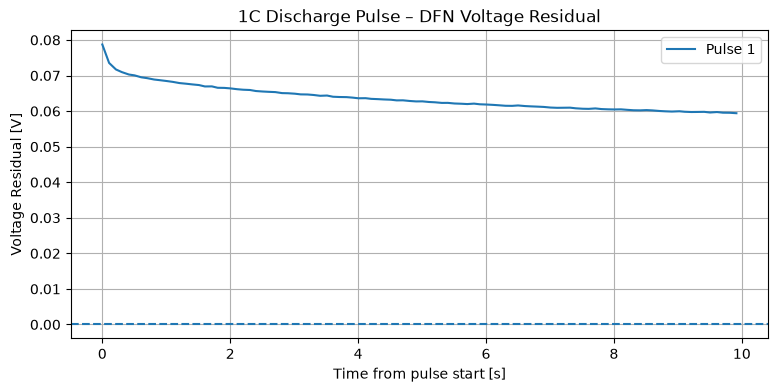

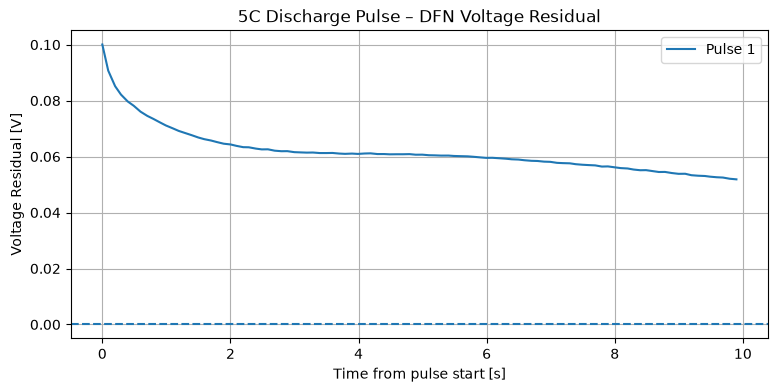

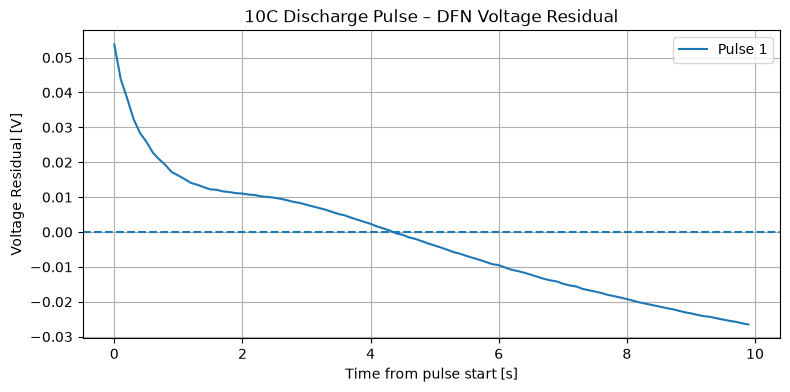

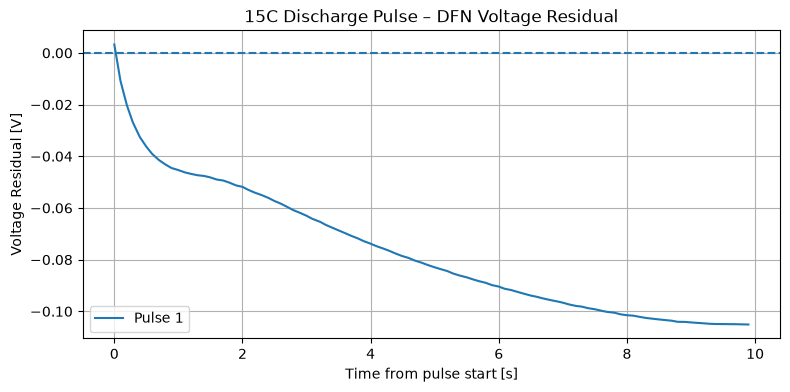

In [43]:
# ============================================================
# PLOT RATE-WISE RESIDUALS
# ============================================================

for rate, segments in rate_results.items():

    if len(segments) == 0:
        continue

    plt.figure(figsize=(9, 4))

    for n, (i1, i2) in enumerate(segments):

        plt.plot(
            t_hppc[i1:i2+1] - t_hppc[i1],
            residual[i1:i2+1],
            label=f"Pulse {n+1}"
        )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Time from pulse start [s]")
    plt.ylabel("Voltage Residual [V]")
    plt.title(f"{rate} Discharge Pulse – DFN Voltage Residual")
    plt.grid(True)
    plt.legend()

    plt.show()

In [44]:
base_params = pybamm.ParameterValues("Prada2013")

print(base_params["Negative electrode exchange-current density [A.m-2]"])
print(base_params["Positive electrode exchange-current density [A.m-2]"])

<function graphite_LGM50_electrolyte_exchange_current_density_Chen2020 at 0x00000239CF86D580>
<function LFP_electrolyte_exchange_current_density_kashkooli2017 at 0x00000239CF86D6C0>


In [45]:
# ============================================================
# FINE SENSITIVITY: NEGATIVE ELECTRODE EXCHANGE CURRENT
# ============================================================

scales_fine = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.8, 2.0]

results_i0_n_fine = []

base_params = pybamm.ParameterValues("Prada2013")

original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

for scale in scales_fine:

    params_test = pybamm.ParameterValues("Prada2013")

    params_test.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_i0_n, s=scale: s * f(*args)
    })

    params_test["Current function [A]"] = current_function

    model_test = pybamm.lithium_ion.DFN()

    sim_test = pybamm.Simulation(
        model=model_test,
        parameter_values=params_test
    )

    sol_test = sim_test.solve(
        t_eval=t_hppc,
        initial_soc=soc_start
    )

    V_test = np.interp(
        t_hppc,
        sol_test.t,
        sol_test["Terminal voltage [V]"].entries
    )

    residual_test = V_exp - V_test

    rmse = np.sqrt(np.mean(residual_test**2))
    mae = np.mean(np.abs(residual_test))
    max_error = np.max(np.abs(residual_test))

    results_i0_n_fine.append([
        scale,
        rmse,
        mae,
        max_error
    ])

    print(
        f"{scale:.2f}x | "
        f"RMSE = {rmse:.6f} V | "
        f"MAE = {mae:.6f} V | "
        f"Max = {max_error:.6f} V"
    )

1.00x | RMSE = 0.030515 V | MAE = 0.025352 V | Max = 0.105087 V
1.10x | RMSE = 0.029999 V | MAE = 0.024780 V | Max = 0.109979 V
1.20x | RMSE = 0.029670 V | MAE = 0.024297 V | Max = 0.114436 V
1.30x | RMSE = 0.029484 V | MAE = 0.023922 V | Max = 0.118541 V
1.40x | RMSE = 0.029415 V | MAE = 0.023731 V | Max = 0.122337 V
1.50x | RMSE = 0.029435 V | MAE = 0.023574 V | Max = 0.125875 V
1.60x | RMSE = 0.029529 V | MAE = 0.023457 V | Max = 0.129182 V
1.80x | RMSE = 0.029875 V | MAE = 0.023433 V | Max = 0.135213 V
2.00x | RMSE = 0.030366 V | MAE = 0.023668 V | Max = 0.140603 V


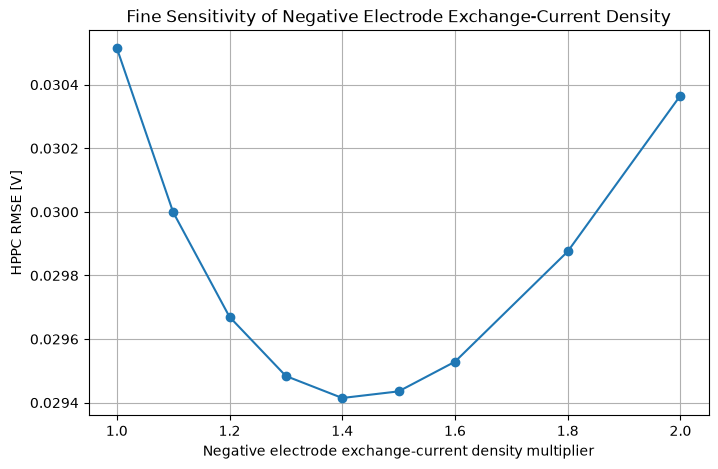

In [46]:
results_i0_n_fine = np.array(results_i0_n_fine)

plt.figure(figsize=(8, 5))

plt.plot(
    results_i0_n_fine[:, 0],
    results_i0_n_fine[:, 1],
    marker="o"
)

plt.xlabel(
    "Negative electrode exchange-current density multiplier"
)
plt.ylabel("HPPC RMSE [V]")
plt.title(
    "Fine Sensitivity of Negative Electrode Exchange-Current Density"
)
plt.grid(True)

plt.show()

In [47]:
# ============================================================
# NEGATIVE PARTICLE DIFFUSIVITY SENSITIVITY
# NEGATIVE j0 FIXED AT 1.4x
# ============================================================

scales_Dn = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

results_Dn = []

base_params = pybamm.ParameterValues("Prada2013")

# Original negative exchange-current-density function
original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

# Original negative particle diffusivity
original_Dn = base_params[
    "Negative particle diffusivity [m2.s-1]"
]

print("Original negative particle diffusivity:")
print(original_Dn)

for scale in scales_Dn:

    params_test = pybamm.ParameterValues("Prada2013")

    # --------------------------------------------------------
    # Negative j0 fixed at the provisional optimum = 1.4x
    # --------------------------------------------------------
    params_test.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_i0_n:
            1.4 * f(*args)
    })

    # --------------------------------------------------------
    # Scale negative particle diffusivity
    # --------------------------------------------------------
    params_test.update({
        "Negative particle diffusivity [m2.s-1]":
            scale * original_Dn
    })

    # Same HPPC current profile
    params_test["Current function [A]"] = current_function

    # DFN model
    model_test = pybamm.lithium_ion.DFN()

    sim_test = pybamm.Simulation(
        model=model_test,
        parameter_values=params_test
    )

    # Same initial SOC
    sol_test = sim_test.solve(
        t_eval=t_hppc,
        initial_soc=soc_start
    )

    # Interpolate DFN voltage onto experimental time
    V_test = np.interp(
        t_hppc,
        sol_test.t,
        sol_test["Terminal voltage [V]"].entries
    )

    # Residual
    residual_test = V_exp - V_test

    # Metrics
    rmse = np.sqrt(np.mean(residual_test**2))
    mae = np.mean(np.abs(residual_test))
    max_error = np.max(np.abs(residual_test))

    results_Dn.append([
        scale,
        rmse,
        mae,
        max_error
    ])

    print(
        f"D_n = {scale:.2f}x | "
        f"RMSE = {rmse:.6f} V | "
        f"MAE = {mae:.6f} V | "
        f"Max = {max_error:.6f} V"
    )

Original negative particle diffusivity:
3e-15
D_n = 0.50x | RMSE = 0.029485 V | MAE = 0.024137 V | Max = 0.116035 V
D_n = 0.75x | RMSE = 0.029422 V | MAE = 0.023901 V | Max = 0.119126 V
D_n = 1.00x | RMSE = 0.029415 V | MAE = 0.023731 V | Max = 0.122337 V
D_n = 1.25x | RMSE = 0.029415 V | MAE = 0.023587 V | Max = 0.125294 V
D_n = 1.50x | RMSE = 0.029418 V | MAE = 0.023461 V | Max = 0.127235 V
D_n = 2.00x | RMSE = 0.029430 V | MAE = 0.023263 V | Max = 0.129464 V


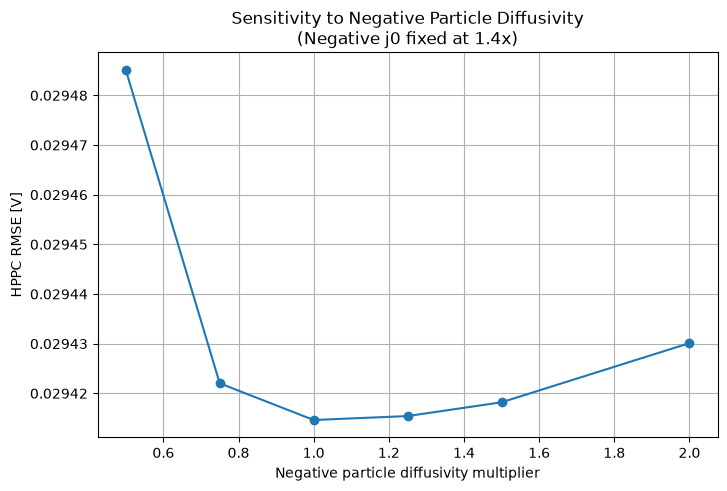

In [48]:
results_Dn = np.array(results_Dn)

plt.figure(figsize=(8, 5))

plt.plot(
    results_Dn[:, 0],
    results_Dn[:, 1],
    marker="o"
)

plt.xlabel("Negative particle diffusivity multiplier")
plt.ylabel("HPPC RMSE [V]")
plt.title(
    "Sensitivity to Negative Particle Diffusivity\n"
    "(Negative j0 fixed at 1.4x)"
)

plt.grid(True)
plt.show()

In [49]:
# ============================================================
# POSITIVE PARTICLE DIFFUSIVITY SENSITIVITY
# Negative j0 = 1.4x
# Negative particle diffusivity = 1.0x
# ============================================================

scales_Dp = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

results_Dp = []

base_params = pybamm.ParameterValues("Prada2013")

# Original negative exchange-current-density function
original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

# Original positive particle diffusivity
original_Dp = base_params[
    "Positive particle diffusivity [m2.s-1]"
]

print("Original positive particle diffusivity:")
print(original_Dp)

for scale in scales_Dp:

    params_test = pybamm.ParameterValues("Prada2013")

    # --------------------------------------------------------
    # Negative j0 fixed at 1.4x
    # --------------------------------------------------------
    params_test.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_i0_n:
            1.4 * f(*args)
    })

    # --------------------------------------------------------
    # Negative particle diffusivity fixed at 1.0x
    # --------------------------------------------------------
    params_test.update({
        "Negative particle diffusivity [m2.s-1]":
            base_params["Negative particle diffusivity [m2.s-1]"]
    })

    # --------------------------------------------------------
    # Scale positive particle diffusivity
    # --------------------------------------------------------
    params_test.update({
        "Positive particle diffusivity [m2.s-1]":
            scale * original_Dp
    })

    # Same HPPC current profile
    params_test["Current function [A]"] = current_function

    model_test = pybamm.lithium_ion.DFN()

    sim_test = pybamm.Simulation(
        model=model_test,
        parameter_values=params_test
    )

    sol_test = sim_test.solve(
        t_eval=t_hppc,
        initial_soc=soc_start
    )

    # Interpolate DFN voltage to experimental time
    V_test = np.interp(
        t_hppc,
        sol_test.t,
        sol_test["Terminal voltage [V]"].entries
    )

    residual_test = V_exp - V_test

    # Metrics
    rmse = np.sqrt(np.mean(residual_test**2))
    mae = np.mean(np.abs(residual_test))
    max_error = np.max(np.abs(residual_test))

    results_Dp.append([
        scale,
        rmse,
        mae,
        max_error
    ])

    print(
        f"D_p = {scale:.2f}x | "
        f"RMSE = {rmse:.6f} V | "
        f"MAE = {mae:.6f} V | "
        f"Max = {max_error:.6f} V"
    )

Original positive particle diffusivity:
5.9e-18
D_p = 0.50x | RMSE = 0.029399 V | MAE = 0.023713 V | Max = 0.122310 V
D_p = 0.75x | RMSE = 0.029411 V | MAE = 0.023725 V | Max = 0.122353 V
D_p = 1.00x | RMSE = 0.029415 V | MAE = 0.023731 V | Max = 0.122337 V
D_p = 1.25x | RMSE = 0.029414 V | MAE = 0.023733 V | Max = 0.122310 V
D_p = 1.50x | RMSE = 0.029414 V | MAE = 0.023734 V | Max = 0.122276 V
D_p = 2.00x | RMSE = 0.029413 V | MAE = 0.023738 V | Max = 0.122206 V


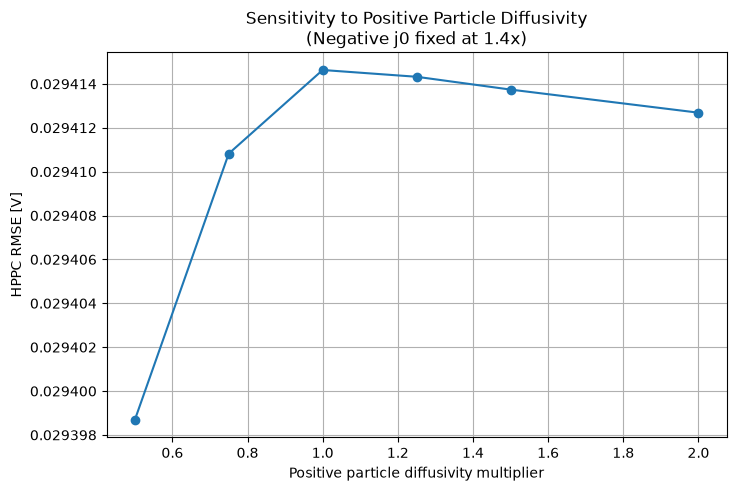

In [50]:
results_Dp = np.array(results_Dp)

plt.figure(figsize=(8, 5))

plt.plot(
    results_Dp[:, 0],
    results_Dp[:, 1],
    marker="o"
)

plt.xlabel("Positive particle diffusivity multiplier")
plt.ylabel("HPPC RMSE [V]")

plt.title(
    "Sensitivity to Positive Particle Diffusivity\n"
    "(Negative j0 fixed at 1.4x)"
)

plt.grid(True)
plt.show()

In [51]:
# ============================================================
# DIAGNOSTIC OCP SHIFT TEST
# Positive electrode OCP shifted by +19.11 mV
# Negative j0 fixed at 1.4x
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt

base_params = pybamm.ParameterValues("Prada2013")

original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_ocp_p = base_params[
    "Positive electrode OCP [V]"
]

# OCP correction obtained from long-rest analysis
ocp_shift = 0.01911

params_ocp_test = pybamm.ParameterValues("Prada2013")

# ------------------------------------------------------------
# Negative exchange-current density = 1.4x
# ------------------------------------------------------------
params_ocp_test.update({
    "Negative electrode exchange-current density [A.m-2]":
        lambda *args, f=original_i0_n:
        1.4 * f(*args)
})

# ------------------------------------------------------------
# Positive OCP shifted by +19.11 mV
# ------------------------------------------------------------
params_ocp_test.update({
    "Positive electrode OCP [V]":
        lambda *args, f=original_ocp_p, s=ocp_shift:
        f(*args) + s
})

# Same HPPC current
params_ocp_test["Current function [A]"] = current_function

# DFN
model_ocp_test = pybamm.lithium_ion.DFN()

sim_ocp_test = pybamm.Simulation(
    model=model_ocp_test,
    parameter_values=params_ocp_test
)

solution_ocp_test = sim_ocp_test.solve(
    t_eval=t_hppc,
    initial_soc=soc_start
)

# Interpolate voltage
V_ocp_test = np.interp(
    t_hppc,
    solution_ocp_test.t,
    solution_ocp_test["Terminal voltage [V]"].entries
)

# Residual
residual_ocp_test = V_exp - V_ocp_test

# Metrics
rmse_ocp = np.sqrt(np.mean(residual_ocp_test**2))
mae_ocp = np.mean(np.abs(residual_ocp_test))
max_ocp = np.max(np.abs(residual_ocp_test))

print("=" * 70)
print("OCP SHIFT DIAGNOSTIC TEST")
print("=" * 70)

print(f"OCP shift             : {ocp_shift*1000:.2f} mV")
print(f"HPPC RMSE             : {rmse_ocp:.6f} V")
print(f"HPPC MAE              : {mae_ocp:.6f} V")
print(f"Maximum absolute error: {max_ocp:.6f} V")

OCP SHIFT DIAGNOSTIC TEST
OCP shift             : 19.11 mV
HPPC RMSE             : 0.026162 V
HPPC MAE              : 0.015945 V
Maximum absolute error: 0.141325 V


In [52]:
# ============================================================
# FINE ELECTROLYTE CONDUCTIVITY SENSITIVITY
# ============================================================

scales_kappa_fine = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

results_kappa_fine = []

base_params = pybamm.ParameterValues("Prada2013")

original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_ocp_p = base_params[
    "Positive electrode OCP [V]"
]

original_kappa = base_params[
    "Electrolyte conductivity [S.m-1]"
]

for scale in scales_kappa_fine:

    params_test = pybamm.ParameterValues("Prada2013")

    # Negative j0 = 1.4x
    params_test.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_i0_n:
            1.4 * f(*args)
    })

    # Positive OCP = original + 19.11 mV
    params_test.update({
        "Positive electrode OCP [V]":
            lambda *args, f=original_ocp_p:
            f(*args) + 0.01911
    })

    # Electrolyte conductivity
    params_test.update({
        "Electrolyte conductivity [S.m-1]":
            lambda *args, f=original_kappa, s=scale:
            s * f(*args)
    })

    params_test["Current function [A]"] = current_function

    model_test = pybamm.lithium_ion.DFN()

    sim_test = pybamm.Simulation(
        model=model_test,
        parameter_values=params_test
    )

    sol_test = sim_test.solve(
        t_eval=t_hppc,
        initial_soc=soc_start
    )

    V_test = np.interp(
        t_hppc,
        sol_test.t,
        sol_test["Terminal voltage [V]"].entries
    )

    residual_test = V_exp - V_test

    rmse = np.sqrt(np.mean(residual_test**2))
    mae = np.mean(np.abs(residual_test))
    max_error = np.max(np.abs(residual_test))

    results_kappa_fine.append([
        scale,
        rmse,
        mae,
        max_error
    ])

    print(
        f"kappa = {scale:.2f}x | "
        f"RMSE = {rmse:.6f} V | "
        f"MAE = {mae:.6f} V | "
        f"Max = {max_error:.6f} V"
    )

kappa = 0.20x | RMSE = 0.024558 V | MAE = 0.016812 V | Max = 0.097417 V
kappa = 0.30x | RMSE = 0.022986 V | MAE = 0.015913 V | Max = 0.095823 V
kappa = 0.40x | RMSE = 0.023332 V | MAE = 0.015782 V | Max = 0.097620 V
kappa = 0.50x | RMSE = 0.023956 V | MAE = 0.015807 V | Max = 0.111871 V
kappa = 0.60x | RMSE = 0.024550 V | MAE = 0.015847 V | Max = 0.121531 V
kappa = 0.70x | RMSE = 0.025061 V | MAE = 0.015879 V | Max = 0.128506 V


In [53]:
# ============================================================
# FINE ELECTROLYTE DIFFUSIVITY SENSITIVITY
# ============================================================

scales_De_fine = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results_De_fine = []

base_params = pybamm.ParameterValues("Prada2013")

# Original parameters
original_i0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_ocp_p = base_params[
    "Positive electrode OCP [V]"
]

original_kappa = base_params[
    "Electrolyte conductivity [S.m-1]"
]

original_De = base_params[
    "Electrolyte diffusivity [m2.s-1]"
]

print("=" * 70)
print("FINE ELECTROLYTE DIFFUSIVITY SENSITIVITY")
print("=" * 70)

print("Original electrolyte diffusivity:")
print(original_De)

print("Type:", type(original_De))
print()


for scale in scales_De_fine:

    params_test = pybamm.ParameterValues("Prada2013")

    # --------------------------------------------------------
    # 1. Negative electrode exchange-current density = 1.4x
    # --------------------------------------------------------
    params_test.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_i0_n:
            1.4 * f(*args)
    })

    # --------------------------------------------------------
    # 2. Positive electrode OCP = original + 19.11 mV
    # --------------------------------------------------------
    params_test.update({
        "Positive electrode OCP [V]":
            lambda *args, f=original_ocp_p:
            f(*args) + 0.01911
    })

    # --------------------------------------------------------
    # 3. Electrolyte conductivity = 0.30x
    # --------------------------------------------------------
    params_test.update({
        "Electrolyte conductivity [S.m-1]":
            lambda *args, f=original_kappa:
            0.30 * f(*args)
    })

    # --------------------------------------------------------
    # 4. Electrolyte diffusivity = selected multiplier
    # --------------------------------------------------------
    if callable(original_De):

        params_test.update({
            "Electrolyte diffusivity [m2.s-1]":
                lambda *args, f=original_De, s=scale:
                s * f(*args)
        })

    else:

        params_test.update({
            "Electrolyte diffusivity [m2.s-1]":
                scale * original_De
        })

    # --------------------------------------------------------
    # 5. Same HPPC current profile
    # --------------------------------------------------------
    params_test["Current function [A]"] = current_function

    # --------------------------------------------------------
    # 6. DFN model
    # --------------------------------------------------------
    model_test = pybamm.lithium_ion.DFN()

    sim_test = pybamm.Simulation(
        model=model_test,
        parameter_values=params_test
    )

    # --------------------------------------------------------
    # 7. Solve from SAME experimental starting SOC
    # --------------------------------------------------------
    sol_test = sim_test.solve(
        t_eval=t_hppc,
        initial_soc=soc_start
    )

    # --------------------------------------------------------
    # 8. DFN voltage
    # --------------------------------------------------------
    V_test = np.interp(
        t_hppc,
        sol_test.t,
        sol_test["Terminal voltage [V]"].entries
    )

    # --------------------------------------------------------
    # 9. Residual
    # --------------------------------------------------------
    residual_test = V_exp - V_test

    # --------------------------------------------------------
    # 10. Error metrics
    # --------------------------------------------------------
    rmse = np.sqrt(np.mean(residual_test**2))
    mae = np.mean(np.abs(residual_test))
    max_error = np.max(np.abs(residual_test))

    results_De_fine.append([
        scale,
        rmse,
        mae,
        max_error
    ])

    print(
        f"D_e = {scale:.2f}x | "
        f"RMSE = {rmse:.6f} V | "
        f"MAE = {mae:.6f} V | "
        f"Max = {max_error:.6f} V"
    )

FINE ELECTROLYTE DIFFUSIVITY SENSITIVITY
Original electrolyte diffusivity:
2e-10
Type: <class 'float'>

D_e = 0.20x | RMSE = 0.021723 V | MAE = 0.013916 V | Max = 0.087535 V
D_e = 0.25x | RMSE = 0.021780 V | MAE = 0.014169 V | Max = 0.086981 V
D_e = 0.30x | RMSE = 0.021857 V | MAE = 0.014389 V | Max = 0.087863 V
D_e = 0.35x | RMSE = 0.021944 V | MAE = 0.014579 V | Max = 0.088668 V
D_e = 0.40x | RMSE = 0.022035 V | MAE = 0.014747 V | Max = 0.089413 V
D_e = 0.45x | RMSE = 0.022126 V | MAE = 0.014897 V | Max = 0.090108 V
D_e = 0.50x | RMSE = 0.022217 V | MAE = 0.015032 V | Max = 0.090761 V


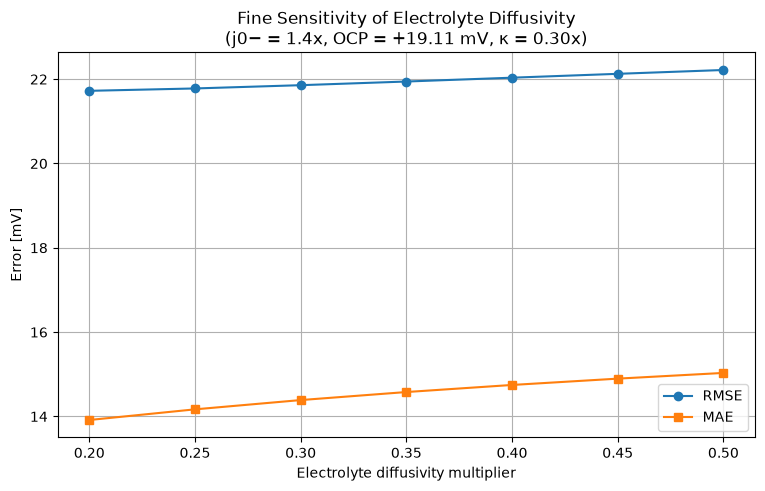

In [54]:
results_De_fine = np.array(results_De_fine)

plt.figure(figsize=(9, 5))

plt.plot(
    results_De_fine[:, 0],
    results_De_fine[:, 1] * 1000,
    marker="o",
    label="RMSE"
)

plt.plot(
    results_De_fine[:, 0],
    results_De_fine[:, 2] * 1000,
    marker="s",
    label="MAE"
)

plt.xlabel("Electrolyte diffusivity multiplier")
plt.ylabel("Error [mV]")

plt.title(
    "Fine Sensitivity of Electrolyte Diffusivity\n"
    "(j0− = 1.4x, OCP = +19.11 mV, κ = 0.30x)"
)

plt.grid(True)
plt.legend()

plt.show()

In [55]:
# ============================================================
# PART 3 — FINAL CALIBRATED DFN VALIDATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pybamm

print("=" * 75)
print("PART 3 — FINAL CALIBRATED DFN VALIDATION")
print("=" * 75)

# ------------------------------------------------------------
# FINAL SELECTED PARAMETERS
# ------------------------------------------------------------
NEG_J0_SCALE = 1.40
OCP_SHIFT = 0.01911       # V = 19.11 mV
KAPPA_SCALE = 0.30
DE_SCALE = 0.20

print("\nFinal calibration:")
print(f"Negative j0       = {NEG_J0_SCALE:.2f}x")
print(f"Positive OCP shift = +{OCP_SHIFT*1000:.2f} mV")
print(f"Electrolyte kappa = {KAPPA_SCALE:.2f}x")
print(f"Electrolyte De    = {DE_SCALE:.2f}x")


# ============================================================
# 1. ORIGINAL PRADA2013 MODEL
# ============================================================

print("\nRunning ORIGINAL Prada2013 DFN...")

params_original = pybamm.ParameterValues("Prada2013")

params_original["Current function [A]"] = current_function

model_original = pybamm.lithium_ion.DFN()

sim_original = pybamm.Simulation(
    model=model_original,
    parameter_values=params_original
)

sol_original = sim_original.solve(
    t_eval=t_hppc,
    initial_soc=soc_start
)

V_original = np.interp(
    t_hppc,
    sol_original.t,
    sol_original["Terminal voltage [V]"].entries
)


# ============================================================
# 2. CALIBRATED MODEL
# ============================================================

print("Running CALIBRATED DFN...")

params_cal = pybamm.ParameterValues("Prada2013")

# Original functions
original_i0_n = params_cal[
    "Negative electrode exchange-current density [A.m-2]"
]

original_ocp_p = params_cal[
    "Positive electrode OCP [V]"
]

original_kappa = params_cal[
    "Electrolyte conductivity [S.m-1]"
]

original_De = params_cal[
    "Electrolyte diffusivity [m2.s-1]"
]


# ------------------------------------------------------------
# Negative exchange-current density = 1.4x
# ------------------------------------------------------------
params_cal.update({
    "Negative electrode exchange-current density [A.m-2]":
        lambda *args, f=original_i0_n:
        NEG_J0_SCALE * f(*args)
})


# ------------------------------------------------------------
# Positive OCP = original + 19.11 mV
# ------------------------------------------------------------
params_cal.update({
    "Positive electrode OCP [V]":
        lambda *args, f=original_ocp_p:
        f(*args) + OCP_SHIFT
})


# ------------------------------------------------------------
# Electrolyte conductivity = 0.30x
# ------------------------------------------------------------
params_cal.update({
    "Electrolyte conductivity [S.m-1]":
        lambda *args, f=original_kappa:
        KAPPA_SCALE * f(*args)
})


# ------------------------------------------------------------
# Electrolyte diffusivity = 0.20x
# ------------------------------------------------------------
if callable(original_De):

    params_cal.update({
        "Electrolyte diffusivity [m2.s-1]":
            lambda *args, f=original_De:
            DE_SCALE * f(*args)
    })

else:

    params_cal.update({
        "Electrolyte diffusivity [m2.s-1]":
            DE_SCALE * original_De
    })


# Same current profile
params_cal["Current function [A]"] = current_function


model_cal = pybamm.lithium_ion.DFN()

sim_cal = pybamm.Simulation(
    model=model_cal,
    parameter_values=params_cal
)

sol_cal = sim_cal.solve(
    t_eval=t_hppc,
    initial_soc=soc_start
)

V_cal = np.interp(
    t_hppc,
    sol_cal.t,
    sol_cal["Terminal voltage [V]"].entries
)


# ============================================================
# 3. RESIDUALS
# ============================================================

res_original = V_exp - V_original
res_cal = V_exp - V_cal


# ============================================================
# 4. METRICS FUNCTION
# ============================================================

def calculate_metrics(exp, model):

    residual = exp - model

    rmse = np.sqrt(np.mean(residual**2))
    mae = np.mean(np.abs(residual))
    max_error = np.max(np.abs(residual))
    mean_error = np.mean(residual)
    std_error = np.std(residual)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Max": max_error,
        "Mean": mean_error,
        "Std": std_error
    }


metrics_original = calculate_metrics(V_exp, V_original)
metrics_cal = calculate_metrics(V_exp, V_cal)


# ============================================================
# 5. PRINT FINAL COMPARISON
# ============================================================

print("\n")
print("=" * 75)
print("FINAL HPPC MODEL COMPARISON")
print("=" * 75)

print("\nORIGINAL Prada2013")
print("-" * 40)
print(f"RMSE             : {metrics_original['RMSE']:.6f} V")
print(f"MAE              : {metrics_original['MAE']:.6f} V")
print(f"Maximum error    : {metrics_original['Max']:.6f} V")
print(f"Mean residual    : {metrics_original['Mean']:.6f} V")
print(f"Residual std.    : {metrics_original['Std']:.6f} V")

print("\nCALIBRATED DFN")
print("-" * 40)
print(f"RMSE             : {metrics_cal['RMSE']:.6f} V")
print(f"MAE              : {metrics_cal['MAE']:.6f} V")
print(f"Maximum error    : {metrics_cal['Max']:.6f} V")
print(f"Mean residual    : {metrics_cal['Mean']:.6f} V")
print(f"Residual std.    : {metrics_cal['Std']:.6f} V")


# ============================================================
# 6. IMPROVEMENT
# ============================================================

rmse_improvement = (
    (metrics_original["RMSE"] - metrics_cal["RMSE"])
    / metrics_original["RMSE"]
) * 100

mae_improvement = (
    (metrics_original["MAE"] - metrics_cal["MAE"])
    / metrics_original["MAE"]
) * 100

max_improvement = (
    (metrics_original["Max"] - metrics_cal["Max"])
    / metrics_original["Max"]
) * 100


print("\n")
print("=" * 75)
print("MODEL IMPROVEMENT")
print("=" * 75)

print(f"RMSE improvement : {rmse_improvement:.2f} %")
print(f"MAE improvement  : {mae_improvement:.2f} %")
print(f"Max error change : {max_improvement:.2f} %")

PART 3 — FINAL CALIBRATED DFN VALIDATION

Final calibration:
Negative j0       = 1.40x
Positive OCP shift = +19.11 mV
Electrolyte kappa = 0.30x
Electrolyte De    = 0.20x

Running ORIGINAL Prada2013 DFN...
Running CALIBRATED DFN...


FINAL HPPC MODEL COMPARISON

ORIGINAL Prada2013
----------------------------------------
RMSE             : 0.030515 V
MAE              : 0.025352 V
Maximum error    : 0.105087 V
Mean residual    : 0.014311 V
Residual std.    : 0.026951 V

CALIBRATED DFN
----------------------------------------
RMSE             : 0.021723 V
MAE              : 0.013916 V
Maximum error    : 0.087535 V
Mean residual    : -0.002569 V
Residual std.    : 0.021571 V


MODEL IMPROVEMENT
RMSE improvement : 28.81 %
MAE improvement  : 45.11 %
Max error change : 16.70 %


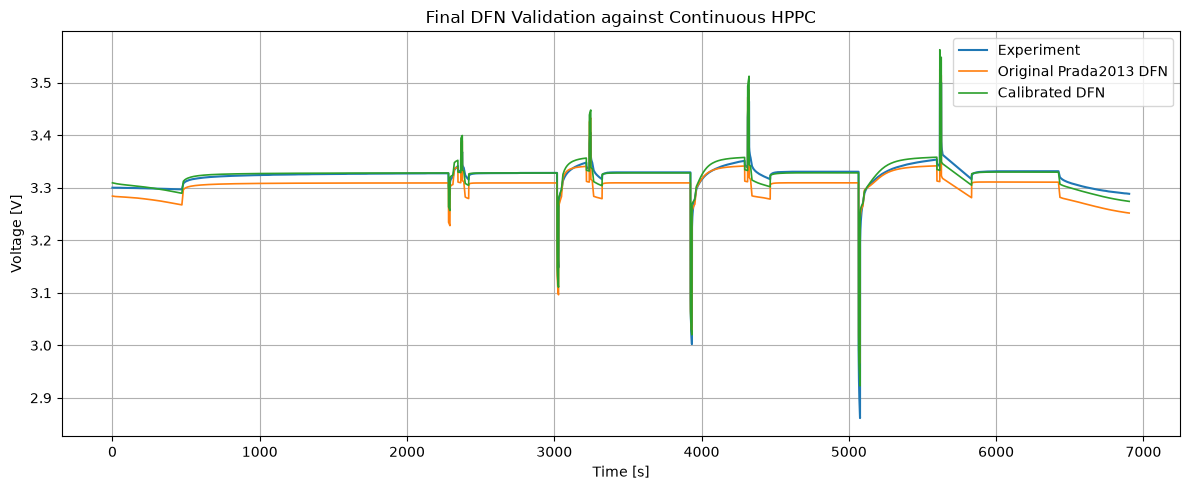

In [56]:
# ============================================================
# FINAL HPPC VOLTAGE COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    V_exp,
    label="Experiment",
    linewidth=1.5
)

plt.plot(
    t_hppc,
    V_original,
    label="Original Prada2013 DFN",
    linewidth=1.2
)

plt.plot(
    t_hppc,
    V_cal,
    label="Calibrated DFN",
    linewidth=1.2
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")

plt.title("Final DFN Validation against Continuous HPPC")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

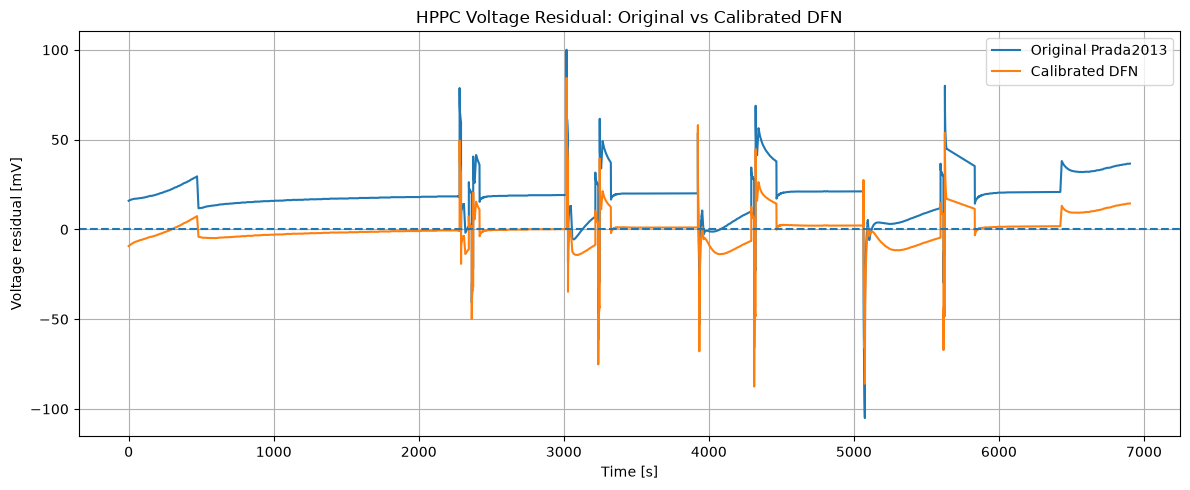

In [57]:
# ============================================================
# RESIDUAL COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_hppc,
    res_original * 1000,
    label="Original Prada2013"
)

plt.plot(
    t_hppc,
    res_cal * 1000,
    label="Calibrated DFN"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage residual [mV]")

plt.title("HPPC Voltage Residual: Original vs Calibrated DFN")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# CORRECTED RELATIVE PULSE WINDOWS
# ============================================================

pulse_info_relative = {
    "1C":  (2281.56, 2291.48),
    "5C":  (3018.92, 3028.82),
    "10C": (3924.58, 3934.48),
    "15C": (5066.08, 5075.97)
}

print("t_hppc range:")
print(f"{t_hppc[0]:.3f} to {t_hppc[-1]:.3f} s")

t_hppc range:
0.000 to 6903.349 s


In [59]:
# ============================================================
# HIGH-RATE PULSE VALIDATION — CORRECTED
# ============================================================

print("\n")
print("=" * 75)
print("HIGH-RATE PULSE VALIDATION")
print("=" * 75)

pulse_results = []

for rate, (t_start, t_end) in pulse_info_relative.items():

    mask = (
        (t_hppc >= t_start) &
        (t_hppc <= t_end)
    )

    # Safety check
    n_points = np.sum(mask)

    if n_points < 2:
        print(f"\nWARNING: {rate} has only {n_points} points.")
        continue

    exp_pulse = V_exp[mask]
    orig_pulse = V_original[mask]
    cal_pulse = V_cal[mask]

    time_relative = t_hppc[mask] - t_start

    # --------------------------------------------------------
    # Original model errors
    # --------------------------------------------------------

    orig_error = exp_pulse - orig_pulse

    orig_rmse = np.sqrt(
        np.mean(orig_error**2)
    )

    orig_mae = np.mean(
        np.abs(orig_error)
    )

    orig_max = np.max(
        np.abs(orig_error)
    )

    # --------------------------------------------------------
    # Calibrated model errors
    # --------------------------------------------------------

    cal_error = exp_pulse - cal_pulse

    cal_rmse = np.sqrt(
        np.mean(cal_error**2)
    )

    cal_mae = np.mean(
        np.abs(cal_error)
    )

    cal_max = np.max(
        np.abs(cal_error)
    )

    # --------------------------------------------------------
    # Improvement
    # --------------------------------------------------------

    improvement = (
        (orig_rmse - cal_rmse)
        / orig_rmse
    ) * 100

    pulse_results.append([
        rate,
        orig_rmse,
        cal_rmse,
        orig_mae,
        cal_mae,
        orig_max,
        cal_max,
        improvement
    ])

    print(f"\n{rate}")
    print("-" * 50)
    print(f"Points           : {n_points}")

    print(
        f"Original RMSE    : "
        f"{orig_rmse*1000:.3f} mV"
    )

    print(
        f"Calibrated RMSE  : "
        f"{cal_rmse*1000:.3f} mV"
    )

    print(
        f"Original MAE     : "
        f"{orig_mae*1000:.3f} mV"
    )

    print(
        f"Calibrated MAE   : "
        f"{cal_mae*1000:.3f} mV"
    )

    print(
        f"Original Max     : "
        f"{orig_max*1000:.3f} mV"
    )

    print(
        f"Calibrated Max   : "
        f"{cal_max*1000:.3f} mV"
    )

    print(
        f"RMSE improvement : "
        f"{improvement:.2f} %"
    )



HIGH-RATE PULSE VALIDATION

1C
--------------------------------------------------
Points           : 101
Original RMSE    : 63.675 mV
Calibrated RMSE  : 34.692 mV
Original MAE     : 63.575 mV
Calibrated MAE   : 34.522 mV
Original Max     : 78.725 mV
Calibrated Max   : 49.433 mV
RMSE improvement : 45.52 %

5C
--------------------------------------------------
Points           : 99
Original RMSE    : 62.441 mV
Calibrated RMSE  : 47.484 mV
Original MAE     : 61.928 mV
Calibrated MAE   : 46.853 mV
Original Max     : 100.051 mV
Calibrated Max   : 84.374 mV
RMSE improvement : 23.95 %

10C
--------------------------------------------------
Points           : 100
Original RMSE    : 16.352 mV
Calibrated RMSE  : 15.217 mV
Original MAE     : 13.884 mV
Calibrated MAE   : 12.628 mV
Original Max     : 43.739 mV
Calibrated Max   : 48.127 mV
RMSE improvement : 6.94 %

15C
--------------------------------------------------
Points           : 100
Original RMSE    : 81.253 mV
Calibrated RMSE  : 51.489 

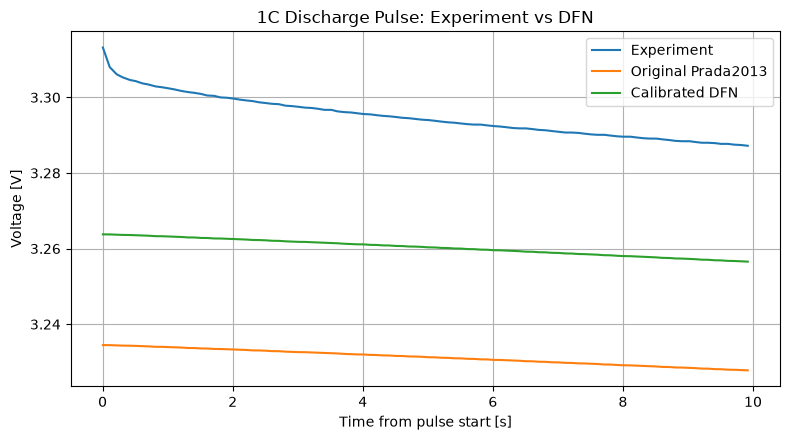

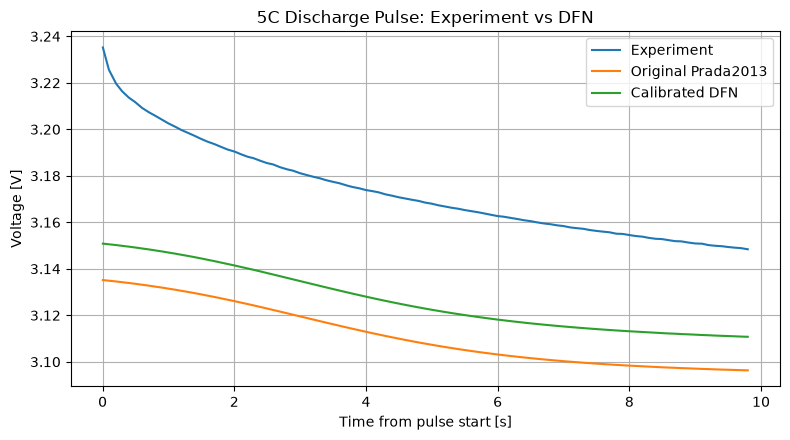

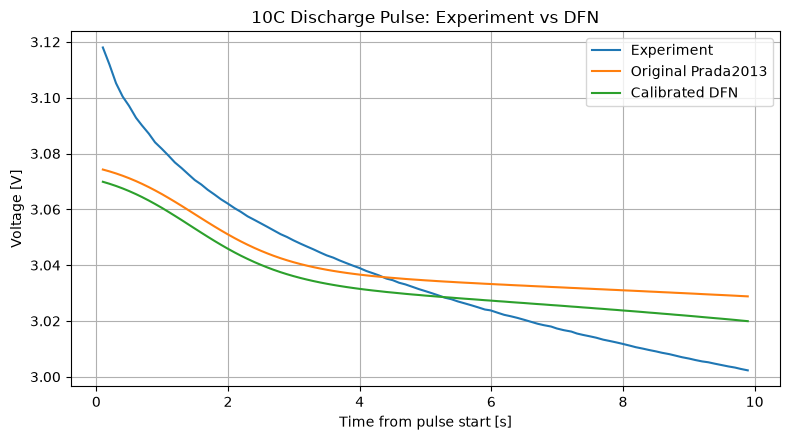

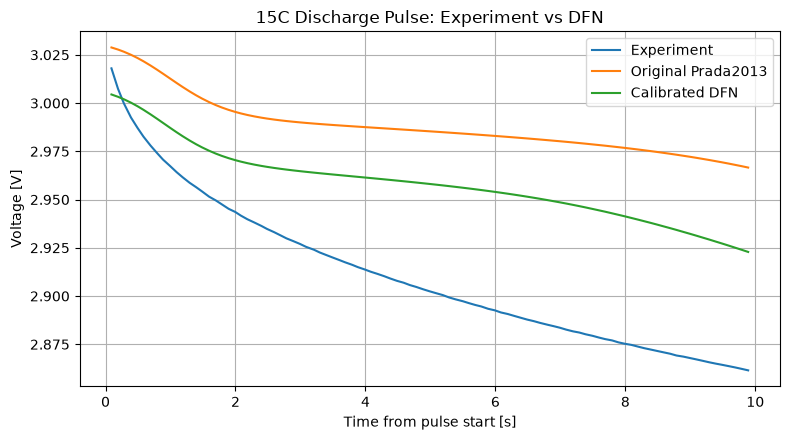

In [60]:
# ============================================================
# PLOT 1C / 5C / 10C / 15C
# ============================================================

for rate, (t_start, t_end) in pulse_info_relative.items():

    mask = (
        (t_hppc >= t_start) &
        (t_hppc <= t_end)
    )

    if np.sum(mask) < 2:
        continue

    time_relative = t_hppc[mask] - t_start

    plt.figure(figsize=(8, 4.5))

    plt.plot(
        time_relative,
        V_exp[mask],
        label="Experiment"
    )

    plt.plot(
        time_relative,
        V_original[mask],
        label="Original Prada2013"
    )

    plt.plot(
        time_relative,
        V_cal[mask],
        label="Calibrated DFN"
    )

    plt.xlabel("Time from pulse start [s]")
    plt.ylabel("Voltage [V]")

    plt.title(
        f"{rate} Discharge Pulse: "
        "Experiment vs DFN"
    )

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


In [61]:
# ============================================================
# FINAL SELECTED PARAMETER SET
# ============================================================

print("=" * 75)
print("FINAL CALIBRATED PARAMETER SET")
print("=" * 75)

print("""
Parameter                                      Selected value
----------------------------------------------------------------
Positive electrode OCP                         +19.11 mV shift
Negative electrode exchange-current density    1.40 x original
Electrolyte conductivity                       0.30 x original
Electrolyte diffusivity                        0.20 x original

Negative particle diffusivity                   Original
Positive particle diffusivity                   Original
Positive exchange-current density              Original
Negative double-layer capacity                 Original
Positive double-layer capacity                 Original
Contact resistance                              0 Ohm
Nominal cell capacity                           Original
""")

print("=" * 75)
print("FINAL HPPC PERFORMANCE")
print("=" * 75)

print(
    f"Original Prada2013 RMSE : "
    f"{metrics_original['RMSE']*1000:.3f} mV"
)

print(
    f"Calibrated DFN RMSE     : "
    f"{metrics_cal['RMSE']*1000:.3f} mV"
)

print(
    f"Original Prada2013 MAE  : "
    f"{metrics_original['MAE']*1000:.3f} mV"
)

print(
    f"Calibrated DFN MAE      : "
    f"{metrics_cal['MAE']*1000:.3f} mV"
)

print(
    f"RMSE improvement        : "
    f"{rmse_improvement:.2f} %"
)

print(
    f"MAE improvement         : "
    f"{mae_improvement:.2f} %"
)

FINAL CALIBRATED PARAMETER SET

Parameter                                      Selected value
----------------------------------------------------------------
Positive electrode OCP                         +19.11 mV shift
Negative electrode exchange-current density    1.40 x original
Electrolyte conductivity                       0.30 x original
Electrolyte diffusivity                        0.20 x original

Negative particle diffusivity                   Original
Positive particle diffusivity                   Original
Positive exchange-current density              Original
Negative double-layer capacity                 Original
Positive double-layer capacity                 Original
Contact resistance                              0 Ohm
Nominal cell capacity                           Original

FINAL HPPC PERFORMANCE
Original Prada2013 RMSE : 30.515 mV
Calibrated DFN RMSE     : 21.723 mV
Original Prada2013 MAE  : 25.352 mV
Calibrated DFN MAE      : 13.916 mV
RMSE improvement        : 2

In [62]:
from scipy.io import loadmat
import numpy as np
import os

# ================================================================
# PART 4 — LOAD THE FIVE OPTIMIZATION DATASETS
# ================================================================

file_paths = {
    "Charge_1C": r"C:\Users\hp\Desktop\MEAtec\Charge_1C.mat",
    "Charge_2C": r"C:\Users\hp\Desktop\MEAtec\Charge_2C.mat",
    "Charge_3C": r"C:\Users\hp\Desktop\MEAtec\Charge_3C.mat",
    "Charge_4C": r"C:\Users\hp\Desktop\MEAtec\Charge_4C.mat",
    "Discharge_1C": r"C:\Users\hp\Desktop\MEAtec\Discharge_1C.mat",
}

print("=" * 80)
print("PART 4 — CHECKING FIVE OPTIMIZATION DATASETS")
print("=" * 80)

mat_files = {}

for name, path in file_paths.items():

    print(f"\n{name}")
    print("-" * 80)
    print("Path   :", path)
    print("Exists :", os.path.exists(path))

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Please check the path on your computer."
        )

    mat = loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False
    )

    mat_files[name] = mat

    print("\nMATLAB variables:")

    for key, value in mat.items():

        if key.startswith("__"):
            continue

        print(
            f"  {key:30s} | "
            f"type = {type(value).__name__:15s} | "
            f"shape = {np.shape(value)}"
        )

        # Inspect MATLAB structures
        if hasattr(value, "_fieldnames"):

            print("      Structure fields:")

            for field in value._fieldnames:

                field_value = getattr(value, field)

                print(
                    f"        {field:25s} | "
                    f"type = {type(field_value).__name__:12s} | "
                    f"shape = {np.shape(field_value)}"
                )

print("\n" + "=" * 80)
print("INSPECTION COMPLETE")
print("=" * 80)

PART 4 — CHECKING FIVE OPTIMIZATION DATASETS

Charge_1C
--------------------------------------------------------------------------------
Path   : C:\Users\hp\Desktop\MEAtec\Charge_1C.mat
Exists : True

MATLAB variables:
  Time                           | type = ndarray         | shape = (6062,)
  Current                        | type = ndarray         | shape = (6062,)
  Voltage                        | type = ndarray         | shape = (6062,)

Charge_2C
--------------------------------------------------------------------------------
Path   : C:\Users\hp\Desktop\MEAtec\Charge_2C.mat
Exists : True

MATLAB variables:
  Time                           | type = ndarray         | shape = (4423,)
  Current                        | type = ndarray         | shape = (4423,)
  Voltage                        | type = ndarray         | shape = (4423,)

Charge_3C
--------------------------------------------------------------------------------
Path   : C:\Users\hp\Desktop\MEAtec\Charge_3C.mat
Exists 

STANDARDIZED OPTIMIZATION DATASETS

Charge_1C
-------------------------------------------------------------------------------------
Number of points       : 6062
Time                  : 0.000000 → 6140.995747 s
Duration              : 1.7058 h
Current minimum       : 0.000000 A
Current maximum       : 2.500600 A
Current mean          : 1.419712 A
Voltage minimum       : 2.941512 V
Voltage maximum       : 3.600947 V
Voltage mean          : 3.462401 V
Minimum Δt            : 0.000468887 s
Maximum Δt            : 1.046787233 s

Approximate current levels:
  |I| ≈  2.5 A : I =    2.4999 A, t =     62.07 s
  |I| ≈  5.0 A : I =    2.5006 A, t =     64.08 s
  |I| ≈  7.5 A : I =    2.5006 A, t =     64.08 s
  |I| ≈ 10.0 A : I =    2.5006 A, t =     64.08 s

Charge_2C
-------------------------------------------------------------------------------------
Number of points       : 4423
Time                  : 0.000000 → 4442.160451 s
Duration              : 1.2339 h
Current minimum       : -0.00044

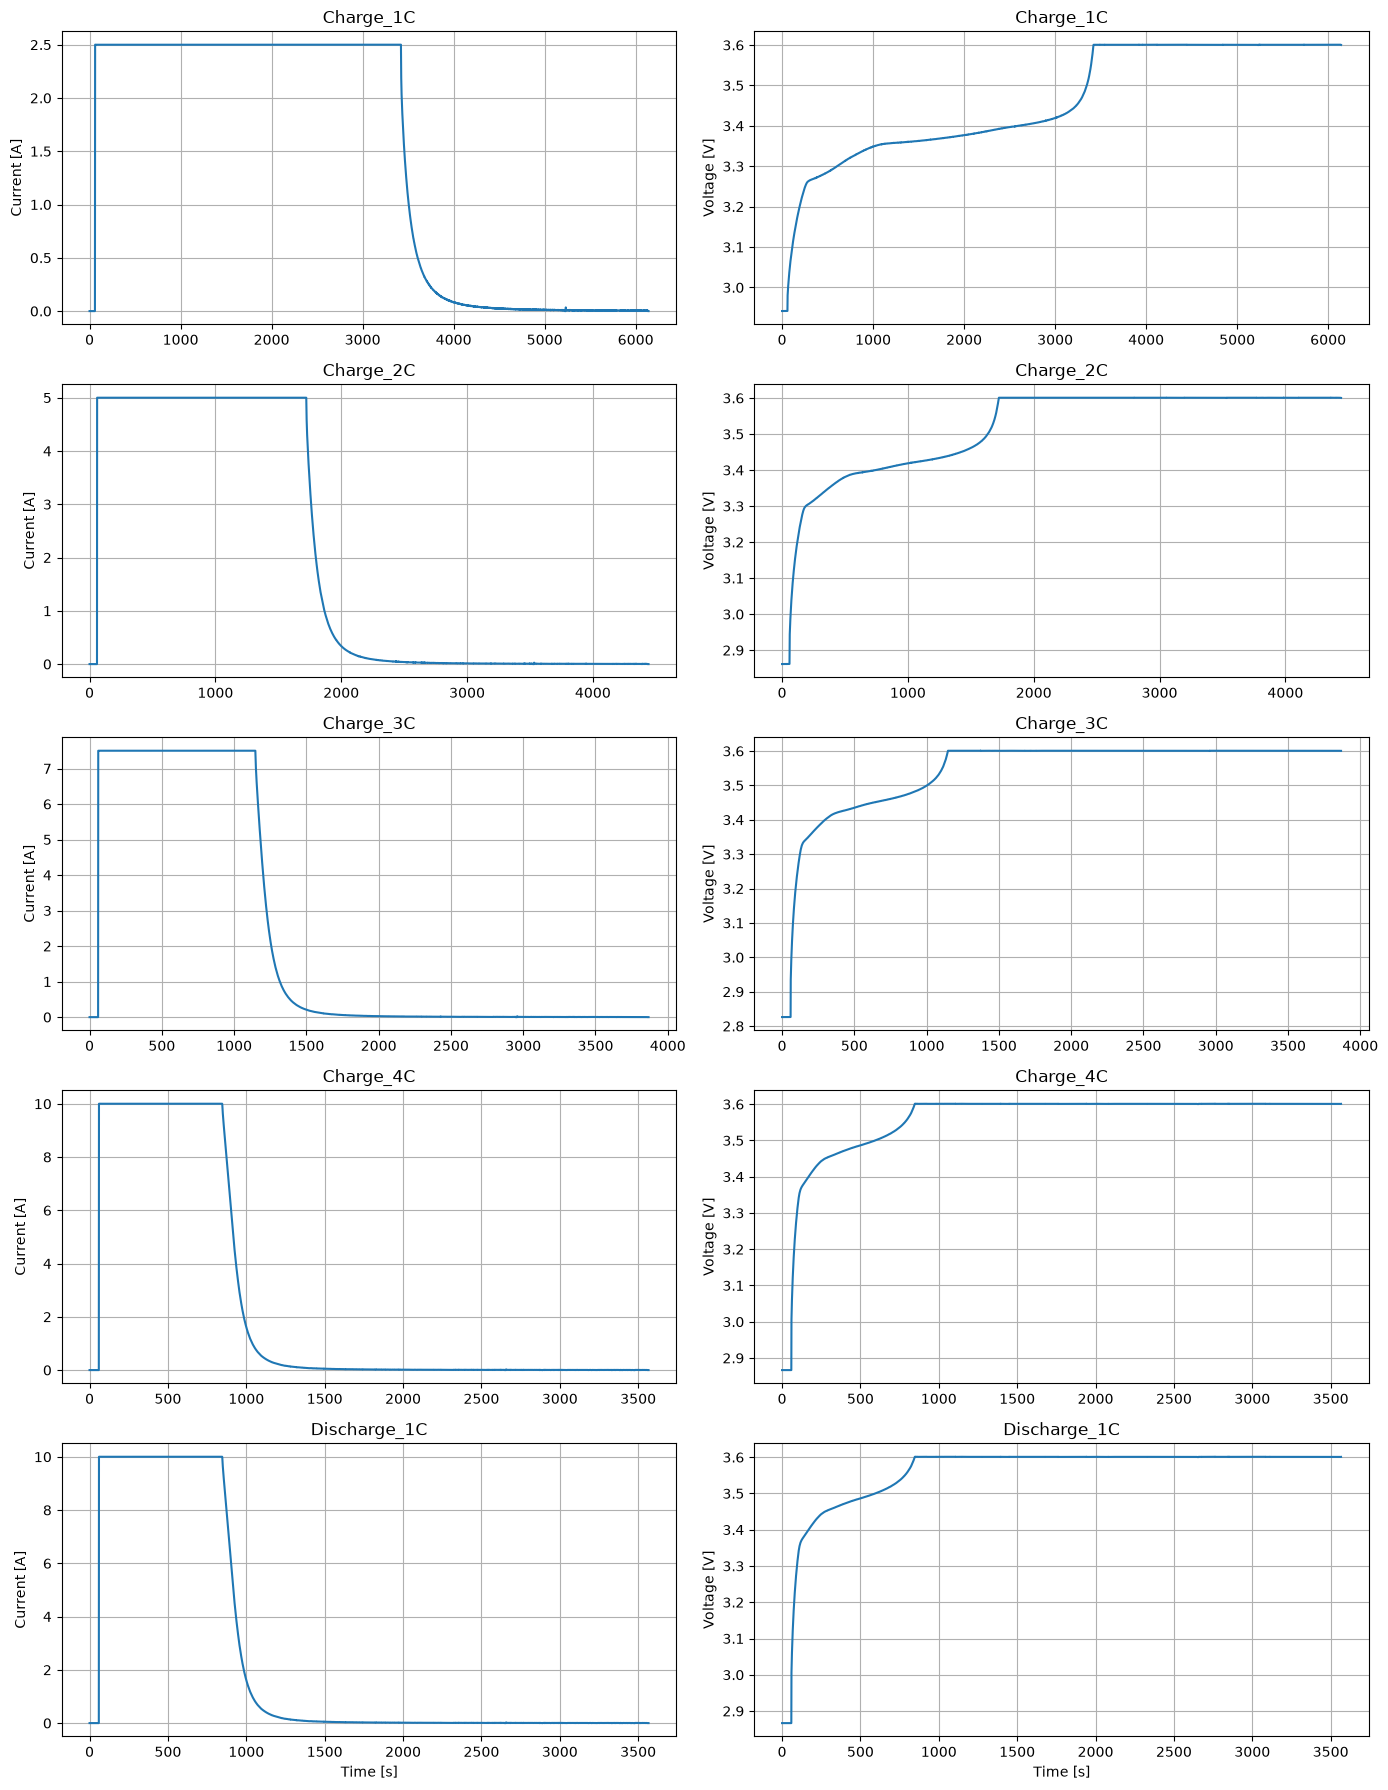

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# PART 4 — STANDARDIZE FIVE OPTIMIZATION DATASETS
# ================================================================

optimization_data = {}

for name, mat in mat_files.items():

    # ------------------------------------------------------------
    # Extract data
    # ------------------------------------------------------------
    t = np.asarray(mat["Time"], dtype=float).flatten()
    I_exp = np.asarray(mat["Current"], dtype=float).flatten()
    V_exp = np.asarray(mat["Voltage"], dtype=float).flatten()

    # ------------------------------------------------------------
    # Basic length check
    # ------------------------------------------------------------
    if not (len(t) == len(I_exp) == len(V_exp)):
        raise ValueError(
            f"{name}: Time, Current and Voltage lengths do not match."
        )

    # ------------------------------------------------------------
    # Remove NaN / Inf
    # ------------------------------------------------------------
    valid = (
        np.isfinite(t)
        & np.isfinite(I_exp)
        & np.isfinite(V_exp)
    )

    t = t[valid]
    I_exp = I_exp[valid]
    V_exp = V_exp[valid]

    # ------------------------------------------------------------
    # Sort by time
    # ------------------------------------------------------------
    order = np.argsort(t)

    t = t[order]
    I_exp = I_exp[order]
    V_exp = V_exp[order]

    # ------------------------------------------------------------
    # Remove duplicate timestamps
    # ------------------------------------------------------------
    unique_t, inverse, counts = np.unique(
        t,
        return_inverse=True,
        return_counts=True
    )

    I_unique = (
        np.bincount(inverse, weights=I_exp)
        / counts
    )

    V_unique = (
        np.bincount(inverse, weights=V_exp)
        / counts
    )

    # ------------------------------------------------------------
    # Shift time to start from zero
    # ------------------------------------------------------------
    unique_t = unique_t - unique_t[0]

    # ------------------------------------------------------------
    # Store standardized dataset
    # ------------------------------------------------------------
    optimization_data[name] = {
        "time": unique_t,
        "current_exp": I_unique,
        "voltage_exp": V_unique,
    }


# ================================================================
# PRINT DATASET INFORMATION
# ================================================================

print("=" * 85)
print("STANDARDIZED OPTIMIZATION DATASETS")
print("=" * 85)

for name, d in optimization_data.items():

    t = d["time"]
    I = d["current_exp"]
    V = d["voltage_exp"]

    dt = np.diff(t)

    print(f"\n{name}")
    print("-" * 85)

    print(f"Number of points       : {len(t)}")
    print(f"Time                  : {t[0]:.6f} → {t[-1]:.6f} s")
    print(f"Duration              : {t[-1] / 3600:.4f} h")
    print(f"Current minimum       : {np.min(I):.6f} A")
    print(f"Current maximum       : {np.max(I):.6f} A")
    print(f"Current mean          : {np.mean(I):.6f} A")
    print(f"Voltage minimum       : {np.min(V):.6f} V")
    print(f"Voltage maximum       : {np.max(V):.6f} V")
    print(f"Voltage mean          : {np.mean(V):.6f} V")

    print(f"Minimum Δt            : {np.min(dt):.9f} s")
    print(f"Maximum Δt            : {np.max(dt):.9f} s")

    # Current values near expected nominal C-rates
    print("\nApproximate current levels:")

    for level in [2.5, 5.0, 7.5, 10.0]:
        idx = np.argmin(np.abs(np.abs(I) - level))

        print(
            f"  |I| ≈ {level:4.1f} A : "
            f"I = {I[idx]:9.4f} A, "
            f"t = {t[idx]:9.2f} s"
        )


# ================================================================
# PLOT CURRENT AND VOLTAGE FOR EACH DATASET
# ================================================================

fig, axes = plt.subplots(
    5, 2,
    figsize=(14, 18),
    sharex=False
)

for row, (name, d) in enumerate(optimization_data.items()):

    t = d["time"]
    I = d["current_exp"]
    V = d["voltage_exp"]

    axes[row, 0].plot(t, I)
    axes[row, 0].set_ylabel("Current [A]")
    axes[row, 0].set_title(name)
    axes[row, 0].grid(True)

    axes[row, 1].plot(t, V)
    axes[row, 1].set_ylabel("Voltage [V]")
    axes[row, 1].set_title(name)
    axes[row, 1].grid(True)

axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [64]:
from scipy.io import loadmat
import numpy as np

# ================================================================
# FINAL PHYSICAL DIRECTION CHECK
# ================================================================

files = {
    "Charge_1C": r"C:\Users\hp\Desktop\MEAtec\Charge_1C.mat",
    "Charge_2C": r"C:\Users\hp\Desktop\MEAtec\Charge_2C.mat",
    "Charge_3C": r"C:\Users\hp\Desktop\MEAtec\Charge_3C.mat",
    "Charge_4C": r"C:\Users\hp\Desktop\MEAtec\Charge_4C.mat",
    "Discharge_1C": r"C:\Users\hp\Desktop\MEAtec\Discharge_1C.mat",
}

print("=" * 85)
print("FINAL PHYSICAL DIRECTION CHECK")
print("=" * 85)

for name, path in files.items():

    mat = loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False
    )

    t = np.asarray(mat["Time"], dtype=float).flatten()
    I = np.asarray(mat["Current"], dtype=float).flatten()
    V = np.asarray(mat["Voltage"], dtype=float).flatten()

    # Significant current thresholds
    positive = I > 0.1
    negative = I < -0.1
    rest = np.abs(I) <= 0.1

    print(f"\n{name}")
    print("-" * 85)

    print(f"Positive-current points : {np.sum(positive)}")
    print(f"Negative-current points : {np.sum(negative)}")
    print(f"Rest points             : {np.sum(rest)}")

    if np.any(positive):
        print(
            f"Positive current range  : "
            f"{np.min(I[positive]):.4f} → "
            f"{np.max(I[positive]):.4f} A"
        )

    if np.any(negative):
        print(
            f"Negative current range  : "
            f"{np.min(I[negative]):.4f} → "
            f"{np.max(I[negative]):.4f} A"
        )

    # Voltage change during significant current
    if np.any(positive):
        idx = np.where(positive)[0]
        print(
            f"Voltage during +I       : "
            f"{V[idx[0]]:.4f} → {V[idx[-1]]:.4f} V"
        )

    if np.any(negative):
        idx = np.where(negative)[0]
        print(
            f"Voltage during -I       : "
            f"{V[idx[0]]:.4f} → {V[idx[-1]]:.4f} V"
        )

FINAL PHYSICAL DIRECTION CHECK

Charge_1C
-------------------------------------------------------------------------------------
Positive-current points : 3835
Negative-current points : 0
Rest points             : 2227
Positive current range  : 0.1007 → 2.5006 A
Voltage during +I       : 2.9753 → 3.6005 V

Charge_2C
-------------------------------------------------------------------------------------
Positive-current points : 2150
Negative-current points : 0
Rest points             : 2273
Positive current range  : 0.1007 → 5.0009 A
Voltage during +I       : 2.9323 → 3.6008 V

Charge_3C
-------------------------------------------------------------------------------------
Positive-current points : 1562
Negative-current points : 0
Rest points             : 2282
Positive current range  : 0.1003 → 7.5013 A
Voltage during +I       : 2.9347 → 3.6006 V

Charge_4C
-------------------------------------------------------------------------------------
Positive-current points : 1261
Negative-current

In [65]:
from scipy.io import loadmat
import numpy as np
import os

folder = r"C:\Users\hp\Desktop\MEAtec"

print("=" * 100)
print(f"{'FILE':30s} {'N':>8s} {'I min':>12s} {'I max':>12s} {'V min':>12s} {'V max':>12s}")
print("=" * 100)

for fname in sorted(os.listdir(folder)):
    if not fname.lower().endswith(".mat"):
        continue

    path = os.path.join(folder, fname)

    try:
        d = loadmat(path, squeeze_me=True, struct_as_record=False)

        if all(k in d for k in ["Time", "Current", "Voltage"]):
            t = np.asarray(d["Time"]).squeeze()
            I = np.asarray(d["Current"]).squeeze()
            V = np.asarray(d["Voltage"]).squeeze()

            print(
                f"{fname:30s} "
                f"{len(t):8d} "
                f"{I.min():12.4f} "
                f"{I.max():12.4f} "
                f"{V.min():12.4f} "
                f"{V.max():12.4f}"
            )
        else:
            variables = [k for k in d.keys() if not k.startswith("__")]
            print(f"{fname:30s}  variables: {variables}")

    except Exception as e:
        print(f"{fname:30s}  ERROR: {e}")

FILE                                  N        I min        I max        V min        V max
Charge_1C.mat                      6062       0.0000       2.5006       2.9415       3.6009
Charge_2C.mat                      4423      -0.0004       5.0009       2.8614       3.6009
Charge_3C.mat                      3844       0.0000       7.5013       2.8261       3.6009
Charge_4C.mat                      3523      -0.0033      10.0023       2.8666       3.6013
Discharge_1C.mat                   3523      -0.0033      10.0023       2.8666       3.6013
HPPC.mat                        variables: ['meas']


In [66]:
# ============================================================
# PART 4 — PREPARE THE FIVE OPTIMIZATION DATASETS
# ============================================================

from scipy.io import loadmat
import numpy as np
import os

base_path = r"C:\Users\hp\Desktop\MEAtec"

# ------------------------------------------------------------
# 1. Load charge datasets
# ------------------------------------------------------------

def load_experiment_mat(filename):
    path = os.path.join(base_path, filename)

    d = loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False
    )

    t = np.asarray(d["Time"], dtype=float).squeeze()
    I = np.asarray(d["Current"], dtype=float).squeeze()
    V = np.asarray(d["Voltage"], dtype=float).squeeze()

    # Sort by time
    order = np.argsort(t)

    t = t[order]
    I = I[order]
    V = V[order]

    # Remove duplicate timestamps
    t_unique, unique_idx = np.unique(t, return_index=True)

    I_unique = I[unique_idx]
    V_unique = V[unique_idx]

    return {
        "time": t_unique,
        "current": I_unique,
        "voltage": V_unique
    }


charge_1C = load_experiment_mat("Charge_1C.mat")
charge_2C = load_experiment_mat("Charge_2C.mat")
charge_3C = load_experiment_mat("Charge_3C.mat")
charge_4C = load_experiment_mat("Charge_4C.mat")


# ------------------------------------------------------------
# 2. Load HPPC and extract the 14 × 1C discharge pulses
# ------------------------------------------------------------

hppc_path = os.path.join(base_path, "HPPC.mat")

hppc_mat = loadmat(
    hppc_path,
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_mat["meas"]

t_h = np.asarray(meas.Time, dtype=float).squeeze()
I_h = np.asarray(meas.Current, dtype=float).squeeze()
V_h = np.asarray(meas.Voltage, dtype=float).squeeze()

# Find approximately -2.5 A discharge
mask_1C = (I_h < -2.0) & (I_h > -3.0)

idx = np.where(mask_1C)[0]

# Split into continuous segments
segments = []

if len(idx) > 0:
    start = idx[0]
    previous = idx[0]

    for i in idx[1:]:
        if i != previous + 1:
            segments.append((start, previous))
            start = i
        previous = i

    segments.append((start, previous))


# Extract each pulse
discharge_1C_pulses = []

for pulse_number, (s, e) in enumerate(segments, start=1):

    t = t_h[s:e+1]
    I = I_h[s:e+1]
    V = V_h[s:e+1]

    # Make time relative to beginning of pulse
    t = t - t[0]

    discharge_1C_pulses.append({
        "pulse": pulse_number,
        "time": t,
        "current": I,
        "voltage": V
    })


# ------------------------------------------------------------
# 3. Print summary
# ------------------------------------------------------------

print("=" * 90)
print("OPTIMIZATION DATASETS")
print("=" * 90)

for name, d in [
    ("Charge 1C", charge_1C),
    ("Charge 2C", charge_2C),
    ("Charge 3C", charge_3C),
    ("Charge 4C", charge_4C),
]:
    print(
        f"{name:12s}: "
        f"{len(d['time']):5d} points | "
        f"I = {d['current'].min():7.3f} to {d['current'].max():7.3f} A | "
        f"V = {d['voltage'].min():.4f} to {d['voltage'].max():.4f} V"
    )

print("\nDischarge 1C from HPPC:")
print(f"Number of pulses: {len(discharge_1C_pulses)}")

for d in discharge_1C_pulses:
    print(
        f"Pulse {d['pulse']:2d}: "
        f"{len(d['time']):3d} points | "
        f"I = {d['current'].mean():.4f} A | "
        f"V = {d['voltage'][0]:.4f} → {d['voltage'][-1]:.4f} V"
    )

OPTIMIZATION DATASETS
Charge 1C   :  6062 points | I =   0.000 to   2.501 A | V = 2.9415 to 3.6009 V
Charge 2C   :  4423 points | I =  -0.000 to   5.001 A | V = 2.8614 to 3.6009 V
Charge 3C   :  3844 points | I =   0.000 to   7.501 A | V = 2.8261 to 3.6009 V
Charge 4C   :  3523 points | I =  -0.003 to  10.002 A | V = 2.8666 to 3.6013 V

Discharge 1C from HPPC:
Number of pulses: 14
Pulse  1: 101 points | I = -2.4992 A | V = 3.4312 → 3.3652 V
Pulse  2: 101 points | I = -2.4989 A | V = 3.3176 → 3.2945 V
Pulse  3: 101 points | I = -2.4981 A | V = 3.3139 → 3.2913 V
Pulse  4: 101 points | I = -2.4977 A | V = 3.3132 → 3.2872 V
Pulse  5: 101 points | I = -2.4983 A | V = 3.2891 → 3.2632 V
Pulse  6: 101 points | I = -2.4986 A | V = 3.2749 → 3.2502 V
Pulse  7: 101 points | I = -2.4987 A | V = 3.2703 → 3.2458 V
Pulse  8: 101 points | I = -2.4977 A | V = 3.2669 → 3.2418 V
Pulse  9: 101 points | I = -2.4985 A | V = 3.2490 → 3.2195 V
Pulse 10: 101 points | I = -2.4984 A | V = 3.2168 → 3.1867 V
Pulse 

In [67]:
# ============================================================
# PART 4 — GRADIENT-BASED OPTIMIZATION
# STEP 1: DEFINE PARAMETER SET AND MODEL FACTORY
# ============================================================

import pybamm
import numpy as np

# ------------------------------------------------------------
# Optimization variables
#
# x[0] = Positive electrode OCP shift [V]
# x[1] = Negative electrode exchange-current multiplier
# x[2] = Electrolyte conductivity multiplier
# x[3] = Electrolyte diffusivity multiplier
# ------------------------------------------------------------

x0 = np.array([
    0.01911,   # Positive OCP shift [V]
    1.40,      # Negative j0 multiplier
    0.30,      # Electrolyte conductivity multiplier
    0.20       # Electrolyte diffusivity multiplier
], dtype=float)


# ------------------------------------------------------------
# Bounds
# ------------------------------------------------------------

bounds = [
    (0.000, 0.040),   # Positive OCP shift [V]
    (0.50,  2.00),    # Negative j0 multiplier
    (0.20,  1.50),    # Electrolyte conductivity multiplier
    (0.20,  1.50)     # Electrolyte diffusivity multiplier
]


print("Initial optimization vector:")
print(x0)

print("\nBounds:")
for name, b in zip(
    [
        "Positive OCP shift [V]",
        "Negative j0 multiplier",
        "Electrolyte conductivity multiplier",
        "Electrolyte diffusivity multiplier"
    ],
    bounds
):
    print(f"{name:45s}: {b}")


# ------------------------------------------------------------
# Get original Prada2013 parameter values
# ------------------------------------------------------------

base_params = pybamm.ParameterValues("Prada2013")

original_ocp_p = base_params["Positive electrode OCP [V]"]

original_j0_n = base_params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_kappa = base_params[
    "Electrolyte conductivity [S.m-1]"
]

original_De = base_params[
    "Electrolyte diffusivity [m2.s-1]"
]


print("\nOriginal parameters successfully loaded.")
print("Parameter set: Prada2013")

Initial optimization vector:
[0.01911 1.4     0.3     0.2    ]

Bounds:
Positive OCP shift [V]                       : (0.0, 0.04)
Negative j0 multiplier                       : (0.5, 2.0)
Electrolyte conductivity multiplier          : (0.2, 1.5)
Electrolyte diffusivity multiplier           : (0.2, 1.5)

Original parameters successfully loaded.
Parameter set: Prada2013


In [68]:
# ============================================================
# STEP 2: PARAMETER UPDATE FUNCTION
# ============================================================

def make_parameter_values(x):
    """
    Create a fresh PyBaMM ParameterValues object
    for a given optimization vector x.
    """

    delta_ocp_p = x[0]
    scale_j0_n = x[1]
    scale_kappa = x[2]
    scale_De = x[3]

    params = pybamm.ParameterValues("Prada2013")

    # Positive electrode OCP shift
    params.update({
        "Positive electrode OCP [V]":
            lambda *args, f=original_ocp_p, shift=delta_ocp_p:
            f(*args) + shift
    })

    # Negative exchange-current density
    params.update({
        "Negative electrode exchange-current density [A.m-2]":
            lambda *args, f=original_j0_n, scale=scale_j0_n:
            f(*args) * scale
    })

    # Electrolyte conductivity
    params.update({
        "Electrolyte conductivity [S.m-1]":
            lambda *args, f=original_kappa, scale=scale_kappa:
            f(*args) * scale
    })

    # Electrolyte diffusivity
    params.update({
        "Electrolyte diffusivity [m2.s-1]":
            lambda *args, f=original_De, scale=scale_De:
            f(*args) * scale
    })

    return params


# Test parameter creation
test_params = make_parameter_values(x0)

print("Parameter set generated successfully.")

Parameter set generated successfully.


In [69]:
# ============================================================
# ESTIMATE INITIAL SOC FROM CHARGE THROUGHPUT
# ============================================================

CAPACITY_AH = 2.5

def estimate_charge_initial_soc(dataset):
    t = np.asarray(dataset["time"], dtype=float)
    I = np.asarray(dataset["current"], dtype=float)

    # Remove duplicate/non-increasing time points
    order = np.argsort(t)
    t = t[order]
    I = I[order]

    t_unique, idx = np.unique(t, return_index=True)
    I_unique = I[idx]

    # Experimental convention:
    # positive current = charging
    Q_Ah = np.trapezoid(I_unique, t_unique) / 3600.0

    # If the experiment finishes at ~100% SOC:
    soc_start = 1.0 - Q_Ah / CAPACITY_AH

    return Q_Ah, soc_start


for name, dataset in [
    ("Charge 1C", charge_1C),
    ("Charge 2C", charge_2C),
    ("Charge 3C", charge_3C),
    ("Charge 4C", charge_4C),
]:

    Q_Ah, soc_start = estimate_charge_initial_soc(dataset)

    print(
        f"{name:12s} | "
        f"Charge = {Q_Ah:.4f} Ah | "
        f"Initial SOC = {soc_start*100:.2f}%"
    )

Charge 1C    | Charge = 2.4230 Ah | Initial SOC = 3.08%
Charge 2C    | Charge = 2.4465 Ah | Initial SOC = 2.14%
Charge 3C    | Charge = 2.4563 Ah | Initial SOC = 1.75%
Charge 4C    | Charge = 2.4522 Ah | Initial SOC = 1.91%


In [70]:
# ============================================================
# FIXED PARAMETER UPDATE FUNCTION
# Works with both scalar and function-valued PyBaMM parameters
# ============================================================

def scale_parameter(original, scale):
    """
    Scale a PyBaMM parameter.

    If the parameter is a function, return a function.
    If it is a scalar, return the scaled scalar.
    """
    if callable(original):
        return lambda *args, f=original, s=scale: f(*args) * s
    else:
        return original * scale


def shifted_function(original, shift):
    """
    Add a constant shift to a PyBaMM function-valued parameter.
    """
    if callable(original):
        return lambda *args, f=original, sh=shift: f(*args) + sh
    else:
        return original + shift


def make_parameter_values(x):

    delta_ocp_p = float(x[0])
    scale_j0_n = float(x[1])
    scale_kappa = float(x[2])
    scale_De = float(x[3])

    params = pybamm.ParameterValues("Prada2013")

    # --------------------------------------------------------
    # Positive electrode OCP
    # --------------------------------------------------------
    params.update({
        "Positive electrode OCP [V]":
            shifted_function(original_ocp_p, delta_ocp_p)
    })

    # --------------------------------------------------------
    # Negative electrode exchange-current density
    # --------------------------------------------------------
    params.update({
        "Negative electrode exchange-current density [A.m-2]":
            scale_parameter(original_j0_n, scale_j0_n)
    })

    # --------------------------------------------------------
    # Electrolyte conductivity
    # --------------------------------------------------------
    params.update({
        "Electrolyte conductivity [S.m-1]":
            scale_parameter(original_kappa, scale_kappa)
    })

    # --------------------------------------------------------
    # Electrolyte diffusivity
    # --------------------------------------------------------
    params.update({
        "Electrolyte diffusivity [m2.s-1]":
            scale_parameter(original_De, scale_De)
    })

    return params


# Test
test_params = make_parameter_values(x0)

print("Parameter update function created successfully.")
print()
print("Original electrolyte diffusivity:")
print(original_De)

print()
print("Original electrolyte conductivity:")
print(original_kappa)

print()
print("Original negative exchange-current density:")
print(original_j0_n)

Parameter update function created successfully.

Original electrolyte diffusivity:
2e-10

Original electrolyte conductivity:
<function electrolyte_conductivity_Prada2013 at 0x00000239CF86D760>

Original negative exchange-current density:
<function graphite_LGM50_electrolyte_exchange_current_density_Chen2020 at 0x00000239CF86D580>


In [71]:
# ============================================================
# DIAGNOSTIC: FIND A SAFE INITIAL SOC FOR CHARGE 1C
# ============================================================

params_base = pybamm.ParameterValues("Prada2013")

model_test = pybamm.lithium_ion.DFN()

# Try several initial SOC values
soc_candidates = np.linspace(0.05, 0.95, 19)

print("=" * 75)
print(f"{'Initial SOC':>15s} {'Initial voltage':>20s} {'Status':>30s}")
print("=" * 75)

for soc in soc_candidates:

    try:
        params = make_parameter_values(x0)

        # Use zero current just for the initial-voltage diagnostic
        params["Current function [A]"] = 0.0

        sim = pybamm.Simulation(
            model=model_test,
            parameter_values=params
        )

        # Only solve for a very short time
        sol = sim.solve(
            t_eval=np.array([0.0, 1.0]),
            initial_soc=float(soc)
        )

        V0 = sol["Terminal voltage [V]"].entries[0]

        print(
            f"{soc:15.3f} "
            f"{V0:20.5f} "
            f"{'OK':>30s}"
        )

    except Exception as e:
        print(
            f"{soc:15.3f} "
            f"{'---':>20s} "
            f"{type(e).__name__}: {str(e)[:60]}"
        )

    Initial SOC      Initial voltage                         Status
          0.050              2.80029                             OK
          0.100              2.99559                             OK
          0.150              3.12578                             OK
          0.200              3.18728                             OK
          0.250              3.20462                             OK
          0.300              3.22462                             OK
          0.350              3.25115                             OK
          0.400              3.27143                             OK
          0.450              3.28118                             OK
          0.500              3.28511                             OK
          0.550              3.28686                             OK
          0.600              3.28792                             OK
          0.650              3.28905                             OK
          0.700              3.29303            

In [72]:
# ============================================================
# CALCULATE INITIAL SOC FOR ALL CHARGE DATASETS
# ============================================================

charge_datasets = {
    "Charge 1C": charge_1C,
    "Charge 2C": charge_2C,
    "Charge 3C": charge_3C,
    "Charge 4C": charge_4C,
}

charge_initial_soc = {}

print("=" * 75)
print(f"{'Dataset':<15} {'Charge (Ah)':>15} {'Initial SOC':>15}")
print("=" * 75)

for name, dataset in charge_datasets.items():

    Q_Ah, soc_start = estimate_charge_initial_soc(dataset)

    charge_initial_soc[name] = soc_start

    print(
        f"{name:<15} "
        f"{Q_Ah:>15.4f} "
        f"{soc_start*100:>14.2f}%"
    )

print("=" * 75)

Dataset             Charge (Ah)     Initial SOC
Charge 1C                2.4230           3.08%
Charge 2C                2.4465           2.14%
Charge 3C                2.4563           1.75%
Charge 4C                2.4522           1.91%


In [73]:
def simulate_dataset(dataset, x, initial_soc):
    
    model = pybamm.lithium_ion.DFN()

    params = make_parameter_values(x)

    t_exp = np.asarray(dataset["time"], dtype=float)
    I_exp = np.asarray(dataset["current"], dtype=float)

    # Sort time
    order = np.argsort(t_exp)

    t_exp = t_exp[order]
    I_exp = I_exp[order]

    # Remove duplicate timestamps
    t_unique, idx = np.unique(t_exp, return_index=True)
    I_unique = I_exp[idx]

    # Experimental convention:
    # discharge = negative
    # charge    = positive
    #
    # PyBaMM convention:
    # discharge current = positive
    # charge current    = negative
    I_pybamm = -I_unique

    current_function = pybamm.Interpolant(
        t_unique,
        I_pybamm,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_unique,
        initial_soc=float(initial_soc)
    )

    V_model = np.interp(
        t_unique,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_unique, V_model

In [74]:
Q_1C, soc_1C = estimate_charge_initial_soc(charge_1C)

print(f"Charge 1C transferred = {Q_1C:.4f} Ah")
print(f"Initial SOC = {soc_1C*100:.2f}%")

Charge 1C transferred = 2.4230 Ah
Initial SOC = 3.08%


In [75]:
t_test, V_test = simulate_dataset(
    charge_1C,
    x0,
    initial_soc=soc_1C
)

print("=" * 70)
print("Charge 1C simulation completed successfully")
print(f"Initial SOC used: {soc_1C*100:.2f}%")
print(f"Model voltage range: {V_test.min():.4f} - {V_test.max():.4f} V")
print("=" * 70)

Charge 1C simulation completed successfully
Initial SOC used: 3.08%
Model voltage range: 2.6240 - 3.6000 V


In [76]:
# ============================================================
# CALCULATE INITIAL SOC FOR ALL CHARGE DATASETS
# ============================================================

charge_datasets = {
    "Charge 1C": charge_1C,
    "Charge 2C": charge_2C,
    "Charge 3C": charge_3C,
    "Charge 4C": charge_4C,
}

charge_initial_soc = {}

print("=" * 75)
print(f"{'Dataset':<15} {'Charge (Ah)':>15} {'Initial SOC':>15}")
print("=" * 75)

for name, dataset in charge_datasets.items():

    Q_Ah, soc_start = estimate_charge_initial_soc(dataset)

    charge_initial_soc[name] = soc_start

    print(
        f"{name:<15} "
        f"{Q_Ah:>15.4f} "
        f"{soc_start*100:>14.2f}%"
    )

print("=" * 75)

Dataset             Charge (Ah)     Initial SOC
Charge 1C                2.4230           3.08%
Charge 2C                2.4465           2.14%
Charge 3C                2.4563           1.75%
Charge 4C                2.4522           1.91%


In [77]:
# ============================================================
# TEST ALL FOUR CHARGE DATASETS
# ============================================================

charge_results = {}

for name, dataset in charge_datasets.items():

    print(f"\nRunning {name} ...")

    soc_start = charge_initial_soc[name]

    try:
        t_model, V_model = simulate_dataset(
            dataset,
            x0,
            initial_soc=soc_start
        )

        charge_results[name] = {
            "time": t_model,
            "voltage": V_model,
            "soc_start": soc_start
        }

        print(f"  SUCCESS")
        print(f"  Initial SOC : {soc_start*100:.2f}%")
        print(f"  Model V     : {V_model.min():.4f} → {V_model.max():.4f} V")

    except Exception as e:

        print(f"  FAILED")
        print(f"  {type(e).__name__}: {e}")


Running Charge 1C ...
  SUCCESS
  Initial SOC : 3.08%
  Model V     : 2.6240 → 3.6000 V

Running Charge 2C ...
  SUCCESS
  Initial SOC : 2.14%
  Model V     : 2.4920 → 3.6000 V

Running Charge 3C ...
  SUCCESS
  Initial SOC : 1.75%
  Model V     : 2.4243 → 3.6000 V

Running Charge 4C ...
  SUCCESS
  Initial SOC : 1.91%
  Model V     : 2.4535 → 3.6000 V


In [78]:
# ============================================================
# FIND SOC CORRESPONDING TO EXPERIMENTAL STARTING VOLTAGE
# ============================================================

def get_experimental_start_voltage(dataset):
    return float(dataset["voltage"][0])


for name, dataset in charge_datasets.items():

    V_exp_start = get_experimental_start_voltage(dataset)

    print(
        f"{name:<15} "
        f"Experimental start V = {V_exp_start:.5f} V"
    )

Charge 1C       Experimental start V = 2.94167 V
Charge 2C       Experimental start V = 2.86153 V
Charge 3C       Experimental start V = 2.82624 V
Charge 4C       Experimental start V = 2.86671 V


In [79]:
# ============================================================
# SOC-VOLTAGE CURVE FROM DFN
# ============================================================

params = make_parameter_values(x0)

model = pybamm.lithium_ion.DFN()

# Zero-current diagnostic
params["Current function [A]"] = 0.0

sim = pybamm.Simulation(
    model=model,
    parameter_values=params
)

soc_grid = np.linspace(0.001, 0.999, 200)

V_ocv = []

for soc in soc_grid:

    try:
        sol = sim.solve(
            t_eval=np.array([0.0, 1.0]),
            initial_soc=float(soc)
        )

        V_ocv.append(
            sol["Terminal voltage [V]"].entries[0]
        )

    except Exception:
        V_ocv.append(np.nan)

V_ocv = np.asarray(V_ocv)

print("OCV curve generated successfully.")
print(f"Voltage range: {np.nanmin(V_ocv):.4f} → {np.nanmax(V_ocv):.4f} V")

OCV curve generated successfully.
Voltage range: 2.0310 → 3.5736 V


In [80]:
# ============================================================
# MATCH EXPERIMENTAL START VOLTAGE TO DFN OCV
# ============================================================

for name, dataset in charge_datasets.items():

    V_start = float(dataset["voltage"][0])

    valid = np.isfinite(V_ocv)

    idx = np.argmin(
        np.abs(V_ocv[valid] - V_start)
    )

    soc_match = soc_grid[valid][idx]
    V_match = V_ocv[valid][idx]

    print(
        f"{name:<15} "
        f"V_exp = {V_start:.5f} V | "
        f"SOC = {soc_match*100:.2f}% | "
        f"V_DFN = {V_match:.5f} V"
    )

Charge 1C       V_exp = 2.94167 V | SOC = 8.12% | V_DFN = 2.94332 V
Charge 2C       V_exp = 2.86153 V | SOC = 6.12% | V_DFN = 2.86517 V
Charge 3C       V_exp = 2.82624 V | SOC = 5.62% | V_DFN = 2.83860 V
Charge 4C       V_exp = 2.86671 V | SOC = 6.12% | V_DFN = 2.86517 V


In [81]:
charge_initial_soc = {
    "Charge 1C": 0.0812,
    "Charge 2C": 0.0612,
    "Charge 3C": 0.0562,
    "Charge 4C": 0.0612,
}

In [82]:
def simulate_dataset(dataset, x, initial_soc):

    model = pybamm.lithium_ion.DFN()
    params = make_parameter_values(x)

    t_exp = np.asarray(dataset["time"], dtype=float)
    I_exp = np.asarray(dataset["current"], dtype=float)

    # Sort
    order = np.argsort(t_exp)
    t_exp = t_exp[order]
    I_exp = I_exp[order]

    # Remove duplicate timestamps
    t_unique, idx = np.unique(t_exp, return_index=True)
    I_unique = I_exp[idx]

    # Experimental convention:
    # Charge    = positive current
    # Discharge = negative current
    #
    # PyBaMM convention:
    # Charge    = negative current
    # Discharge = positive current

    I_pybamm = -I_unique

    current_function = pybamm.Interpolant(
        t_unique,
        I_pybamm,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_unique,
        initial_soc=float(initial_soc)
    )

    V_model = np.interp(
        t_unique,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_unique, V_model

In [83]:
# ============================================================
# TEST CHARGE DATA USING OCV-MATCHED INITIAL SOC
# ============================================================

charge_results = {}

for name, dataset in charge_datasets.items():

    soc_start = charge_initial_soc[name]

    print(f"\nRunning {name} ...")

    try:

        t_model, V_model = simulate_dataset(
            dataset,
            x0,
            initial_soc=soc_start
        )

        V_exp = np.asarray(dataset["voltage"], dtype=float)

        # Make sure dimensions match
        n = min(len(V_exp), len(V_model))

        rmse = np.sqrt(
            np.mean(
                (V_exp[:n] - V_model[:n])**2
            )
        )

        mae = np.mean(
            np.abs(
                V_exp[:n] - V_model[:n]
            )
        )

        charge_results[name] = {
            "time": t_model,
            "voltage": V_model,
            "soc_start": soc_start,
            "rmse": rmse,
            "mae": mae
        }

        print(f"  SUCCESS")
        print(f"  Initial SOC : {soc_start*100:.2f}%")
        print(f"  RMSE        : {rmse*1000:.3f} mV")
        print(f"  MAE         : {mae*1000:.3f} mV")
        print(f"  Model V     : {V_model.min():.4f} → {V_model.max():.4f} V")

    except Exception as e:

        print(f"  FAILED")
        print(f"  {type(e).__name__}: {e}")


Running Charge 1C ...
  SUCCESS
  Initial SOC : 8.12%
  RMSE        : 45.502 mV
  MAE         : 26.346 mV
  Model V     : 2.9432 → 3.6000 V

Running Charge 2C ...
  SUCCESS
  Initial SOC : 6.12%
  RMSE        : 59.374 mV
  MAE         : 35.266 mV
  Model V     : 2.8653 → 3.6000 V

Running Charge 3C ...
  SUCCESS
  Initial SOC : 5.62%
  RMSE        : 67.804 mV
  MAE         : 35.746 mV
  Model V     : 2.8388 → 3.6000 V

Running Charge 4C ...
  SUCCESS
  Initial SOC : 6.12%
  RMSE        : 57.329 mV
  MAE         : 26.069 mV
  Model V     : 2.8653 → 3.6000 V


In [84]:
# ============================================================
# ADD EXPERIMENTAL SOC TO EACH 1C DISCHARGE PULSE
# ============================================================

# SOC values obtained from the HPPC Ah data
discharge_soc_values = np.array([
    1.0000,   # 100%
    0.9500,   # 95%
    0.9000,   # 90%
    0.8000,   # 80%
    0.7000,   # 70%
    0.6000,   # 60%
    0.5000,   # 50%
    0.4000,   # 40%
    0.3000,   # 30%
    0.2000,   # 20%
    0.1500,   # 15%
    0.1000,   # 10%
    0.0500,   # 5%
    0.0250    # 2.5%
])

for pulse, soc in zip(discharge_1C_pulses, discharge_soc_values):

    pulse["initial_soc"] = soc

print("SOC assigned to all discharge pulses.")

for pulse in discharge_1C_pulses:
    print(
        f"Pulse {pulse['pulse']:2d}: "
        f"SOC = {pulse['initial_soc']*100:6.2f}%"
    )

SOC assigned to all discharge pulses.
Pulse  1: SOC = 100.00%
Pulse  2: SOC =  95.00%
Pulse  3: SOC =  90.00%
Pulse  4: SOC =  80.00%
Pulse  5: SOC =  70.00%
Pulse  6: SOC =  60.00%
Pulse  7: SOC =  50.00%
Pulse  8: SOC =  40.00%
Pulse  9: SOC =  30.00%
Pulse 10: SOC =  20.00%
Pulse 11: SOC =  15.00%
Pulse 12: SOC =  10.00%
Pulse 13: SOC =   5.00%
Pulse 14: SOC =   2.50%


In [85]:
# ============================================================
# SIMULATE ONE DISCHARGE PULSE
# ============================================================

def simulate_discharge_pulse(pulse, x):

    model = pybamm.lithium_ion.DFN()

    params = make_parameter_values(x)

    t_exp = np.asarray(pulse["time"], dtype=float)
    I_exp = np.asarray(pulse["current"], dtype=float)

    # Sort time
    order = np.argsort(t_exp)

    t_exp = t_exp[order]
    I_exp = I_exp[order]

    # Remove duplicate timestamps
    t_unique, idx = np.unique(t_exp, return_index=True)
    I_unique = I_exp[idx]

    # Experimental discharge current is negative.
    # PyBaMM discharge current is positive.
    I_pybamm = -I_unique

    current_function = pybamm.Interpolant(
        t_unique,
        I_pybamm,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_unique,
        initial_soc=float(pulse["initial_soc"])
    )

    V_model = np.interp(
        t_unique,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_unique, V_model

In [86]:
# ============================================================
# TEST ALL 14 DISCHARGE PULSES
# ============================================================

discharge_results = []

for pulse in discharge_1C_pulses:

    print(f"Running discharge pulse {pulse['pulse']} ...")

    try:

        t_model, V_model = simulate_discharge_pulse(
            pulse,
            x0
        )

        V_exp = np.asarray(
            pulse["voltage"],
            dtype=float
        )

        n = min(
            len(V_exp),
            len(V_model)
        )

        rmse = np.sqrt(
            np.mean(
                (V_exp[:n] - V_model[:n])**2
            )
        )

        mae = np.mean(
            np.abs(
                V_exp[:n] - V_model[:n]
            )
        )

        discharge_results.append({
            "pulse": pulse["pulse"],
            "soc": pulse["initial_soc"],
            "time": t_model,
            "voltage": V_model,
            "rmse": rmse,
            "mae": mae
        })

        print(
            f"  SOC  = {pulse['initial_soc']*100:.2f}% | "
            f"RMSE = {rmse*1000:.3f} mV | "
            f"MAE = {mae*1000:.3f} mV"
        )

    except Exception as e:

        print(
            f"  FAILED: {type(e).__name__}: {e}"
        )

Running discharge pulse 1 ...
  SOC  = 100.00% | RMSE = 33.887 mV | MAE = 26.580 mV
Running discharge pulse 2 ...
  SOC  = 95.00% | RMSE = 36.818 mV | MAE = 36.544 mV
Running discharge pulse 3 ...
  SOC  = 90.00% | RMSE = 32.824 mV | MAE = 32.483 mV
Running discharge pulse 4 ...
  SOC  = 80.00% | RMSE = 33.710 mV | MAE = 33.513 mV
Running discharge pulse 5 ...
  SOC  = 70.00% | RMSE = 42.806 mV | MAE = 42.571 mV
Running discharge pulse 6 ...
  SOC  = 60.00% | RMSE = 32.423 mV | MAE = 32.096 mV
Running discharge pulse 7 ...
  SOC  = 50.00% | RMSE = 32.470 mV | MAE = 32.157 mV
Running discharge pulse 8 ...
  SOC  = 40.00% | RMSE = 48.069 mV | MAE = 47.986 mV
Running discharge pulse 9 ...
  SOC  = 30.00% | RMSE = 78.621 mV | MAE = 78.576 mV
Running discharge pulse 10 ...
  SOC  = 20.00% | RMSE = 93.630 mV | MAE = 93.617 mV
Running discharge pulse 11 ...
  SOC  = 15.00% | RMSE = 162.436 mV | MAE = 162.003 mV
Running discharge pulse 12 ...
  SOC  = 10.00% | RMSE = 286.523 mV | MAE = 286.178

In [87]:
def simulate_discharge_pulse(pulse, x):

    model = pybamm.lithium_ion.DFN()
    params = make_parameter_values(x)

    t_exp = np.asarray(pulse["time"], dtype=float)
    I_exp = np.asarray(pulse["current"], dtype=float)

    order = np.argsort(t_exp)

    t_exp = t_exp[order]
    I_exp = I_exp[order]

    t_unique, idx = np.unique(t_exp, return_index=True)
    I_unique = I_exp[idx]

    I_pybamm = -I_unique

    current_function = pybamm.Interpolant(
        t_unique,
        I_pybamm,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_unique,
        initial_soc=float(pulse["initial_soc"])
    )

    V_model = np.interp(
        t_unique,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_unique, V_model

In [88]:
t_test, V_test = simulate_discharge_pulse(
    discharge_1C_pulses[3],   # 80% SOC pulse
    x0
)

print("Simulation successful")
print(f"Number of points: {len(t_test)}")
print(f"Voltage range: {V_test.min():.4f} - {V_test.max():.4f} V")

Simulation successful
Number of points: 100
Voltage range: 3.2579 - 3.2644 V


In [89]:
# ============================================================
# CONTINUOUS HPPC SIMULATION FOR OPTIMIZATION
# ============================================================

def simulate_hppc(x):

    model = pybamm.lithium_ion.DFN()
    params = make_parameter_values(x)

    current_function = pybamm.Interpolant(
        t_hppc,
        I_hppc,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_hppc,
        initial_soc=float(soc_start)
    )

    V_model = np.interp(
        t_hppc,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_hppc, V_model

In [90]:
t_hp_test, V_hp_test = simulate_hppc(x0)

rmse_hp = np.sqrt(
    np.mean((V_hppc - V_hp_test)**2)
)

mae_hp = np.mean(
    np.abs(V_hppc - V_hp_test)
)

print("=" * 70)
print("Continuous HPPC test")
print("=" * 70)
print(f"RMSE : {rmse_hp*1000:.3f} mV")
print(f"MAE  : {mae_hp*1000:.3f} mV")

Continuous HPPC test
RMSE : 793.670 mV
MAE  : 629.691 mV


In [91]:
I_pybamm = -I_exp

In [92]:
# ============================================================
# PREPARE CONTINUOUS HPPC DATA
# ============================================================

# Experimental HPPC data
t_hppc = np.asarray(t_exp, dtype=float)
V_hppc = np.asarray(V_exp, dtype=float)

# Experimental convention:
# discharge current = negative
# charge current    = positive
I_hppc_exp = np.asarray(I_exp, dtype=float)

# Convert to PyBaMM convention:
# discharge current = positive
# charge current    = negative
I_hppc = -I_hppc_exp

# Sort by time
order = np.argsort(t_hppc)

t_hppc = t_hppc[order]
V_hppc = V_hppc[order]
I_hppc = I_hppc[order]

# Remove duplicate timestamps
t_hppc, idx = np.unique(t_hppc, return_index=True)

V_hppc = V_hppc[idx]
I_hppc = I_hppc[idx]

print("=" * 70)
print("HPPC data prepared")
print("=" * 70)
print(f"Number of points : {len(t_hppc)}")
print(f"Time range       : {t_hppc[0]:.3f} → {t_hppc[-1]:.3f} s")
print(f"Current range    : {I_hppc.min():.3f} → {I_hppc.max():.3f} A")
print(f"Voltage range    : {V_hppc.min():.4f} → {V_hppc.max():.4f} V")

HPPC data prepared
Number of points : 48
Time range       : 0.000 → 470.001 s
Current range    : -0.000 → -0.000 A
Voltage range    : 3.0261 → 3.0611 V


In [93]:
def simulate_hppc(x):

    model = pybamm.lithium_ion.DFN()

    params = make_parameter_values(x)

    current_function = pybamm.Interpolant(
        t_hppc,
        I_hppc,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_hppc,
        initial_soc=float(soc_start)
    )

    V_model = np.interp(
        t_hppc,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_hppc, V_model

In [94]:
t_hp_test, V_hp_test = simulate_hppc(x0)

rmse_hp = np.sqrt(
    np.mean((V_hppc - V_hp_test)**2)
)

mae_hp = np.mean(
    np.abs(V_hppc - V_hp_test)
)

print("=" * 70)
print("Continuous HPPC test")
print("=" * 70)
print(f"RMSE : {rmse_hp*1000:.3f} mV")
print(f"MAE  : {mae_hp*1000:.3f} mV")
print("=" * 70)

Continuous HPPC test
RMSE : 172.895 mV
MAE  : 172.688 mV


In [95]:
# ============================================================
# REBUILD CONTINUOUS HPPC DATA - 80% SOC REGION
# ============================================================

from scipy.io import loadmat
import numpy as np

# Load HPPC directly
hppc_path = r"C:\Users\hp\Desktop\MEAtec\HPPC.mat"

data_hppc = loadmat(
    hppc_path,
    squeeze_me=True,
    struct_as_record=False
)

meas = data_hppc["meas"]

# Original experimental arrays
hppc_time_exp = np.asarray(meas.Time, dtype=float).squeeze()
hppc_current_exp = np.asarray(meas.Current, dtype=float).squeeze()
hppc_voltage_exp = np.asarray(meas.Voltage, dtype=float).squeeze()
hppc_ah = np.asarray(meas.Ah, dtype=float).squeeze()

# ------------------------------------------------------------
# Sort by time
# ------------------------------------------------------------

order = np.argsort(hppc_time_exp)

hppc_time_exp = hppc_time_exp[order]
hppc_current_exp = hppc_current_exp[order]
hppc_voltage_exp = hppc_voltage_exp[order]
hppc_ah = hppc_ah[order]

# ------------------------------------------------------------
# Select complete region around 80% SOC
#
# SOC = 1 + Ah / 2.5
#
# 80% SOC corresponds to Ah = -0.5 Ah
# Use ±0.10 Ah:
#        -0.60 Ah <= Ah <= -0.40 Ah
# ------------------------------------------------------------

mask_80 = (
    (hppc_ah >= -0.60) &
    (hppc_ah <= -0.40)
)

indices = np.where(mask_80)[0]

if len(indices) == 0:
    raise ValueError("No HPPC data found in the 80% SOC region.")

i_start = indices[0]
i_end = indices[-1]

# IMPORTANT:
# Take the COMPLETE continuous time region between the
# first and last points, including rest periods and pulses.

t_region = hppc_time_exp[i_start:i_end + 1]
I_region = hppc_current_exp[i_start:i_end + 1]
V_region = hppc_voltage_exp[i_start:i_end + 1]
Ah_region = hppc_ah[i_start:i_end + 1]

# ------------------------------------------------------------
# Remove duplicate timestamps
# ------------------------------------------------------------

t_region_unique, unique_idx = np.unique(
    t_region,
    return_index=True
)

I_region = I_region[unique_idx]
V_region = V_region[unique_idx]
Ah_region = Ah_region[unique_idx]

# ------------------------------------------------------------
# Shift time to zero
# ------------------------------------------------------------

t_hppc = t_region_unique - t_region_unique[0]

# Experimental current remains in experimental convention here
I_hppc_exp = I_region.copy()

# Voltage
V_hppc = V_region.copy()

# Convert current to PyBaMM convention
# Experimental:
#   discharge = negative
#   charge    = positive
#
# PyBaMM:
#   discharge = positive
#   charge    = negative

I_hppc = -I_hppc_exp

# Initial SOC for this region
soc_hppc = 0.80

print("=" * 75)
print("CONTINUOUS HPPC DATA REBUILT")
print("=" * 75)

print(f"Original HPPC points       : {len(hppc_time_exp)}")
print(f"Selected HPPC points       : {len(t_hppc)}")
print(f"Original time range        : "
      f"{t_region_unique[0]:.3f} → {t_region_unique[-1]:.3f} s")
print(f"Relative time range        : "
      f"{t_hppc[0]:.3f} → {t_hppc[-1]:.3f} s")

print(f"Ah range                   : "
      f"{Ah_region.min():.4f} → {Ah_region.max():.4f} Ah")

print(f"Approx. SOC range          : "
      f"{(1 + Ah_region.max()/2.5)*100:.2f}% → "
      f"{(1 + Ah_region.min()/2.5)*100:.2f}%")

print(f"Experimental current range : "
      f"{I_hppc_exp.min():.3f} → {I_hppc_exp.max():.3f} A")

print(f"PyBaMM current range       : "
      f"{I_hppc.min():.3f} → {I_hppc.max():.3f} A")

print(f"Voltage range               : "
      f"{V_hppc.min():.4f} → {V_hppc.max():.4f} V")

print(f"Initial SOC used            : {soc_hppc*100:.1f}%")

print("=" * 75)

CONTINUOUS HPPC DATA REBUILT
Original HPPC points       : 55793
Selected HPPC points       : 4030
Original time range        : 17566.053 → 24469.402 s
Relative time range        : 0.000 → 6903.349 s
Ah range                   : -0.6041 → -0.4019 Ah
Approx. SOC range          : 83.92% → 75.84%
Experimental current range : -37.499 → 19.905 A
PyBaMM current range       : -19.905 → 37.499 A
Voltage range               : 2.8615 → 3.5000 V
Initial SOC used            : 80.0%


In [96]:
# ============================================================
# CONTINUOUS HPPC SIMULATOR
# ============================================================

def simulate_hppc(x):

    model = pybamm.lithium_ion.DFN()

    params = make_parameter_values(x)

    current_function = pybamm.Interpolant(
        t_hppc,
        I_hppc,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_hppc,
        initial_soc=soc_hppc
    )

    V_model = np.interp(
        t_hppc,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_hppc, V_model

In [97]:
# ============================================================
# TEST CONTINUOUS HPPC
# ============================================================

t_hp_test, V_hp_test = simulate_hppc(x0)

rmse_hp = np.sqrt(
    np.mean(
        (V_hppc - V_hp_test)**2
    )
)

mae_hp = np.mean(
    np.abs(
        V_hppc - V_hp_test
    )
)

print("=" * 70)
print("Continuous HPPC test")
print("=" * 70)
print(f"RMSE : {rmse_hp*1000:.3f} mV")
print(f"MAE  : {mae_hp*1000:.3f} mV")
print("=" * 70)

Continuous HPPC test
RMSE : 23.935 mV
MAE  : 19.333 mV


In [98]:
# ============================================================
# PART 4 - OPTIMIZATION DATA
# ============================================================

optimization_datasets = {
    "Charge 1C": charge_1C,
    "Charge 2C": charge_2C,
    "Charge 3C": charge_3C,
    "Charge 4C": charge_4C,
}

optimization_soc = {
    "Charge 1C": 0.0812,
    "Charge 2C": 0.0612,
    "Charge 3C": 0.0562,
    "Charge 4C": 0.0612,
}

print("Optimization datasets:")
for name in optimization_datasets:
    print(f"  {name}: SOC = {optimization_soc[name]*100:.2f}%")

print("  Continuous HPPC: SOC = 80.00%")

Optimization datasets:
  Charge 1C: SOC = 8.12%
  Charge 2C: SOC = 6.12%
  Charge 3C: SOC = 5.62%
  Charge 4C: SOC = 6.12%
  Continuous HPPC: SOC = 80.00%


In [99]:
# ============================================================
# CHARGE SIMULATION FOR OPTIMIZATION
# ============================================================

def simulate_charge_for_optimization(dataset, initial_soc, x):

    model = pybamm.lithium_ion.DFN()

    params = make_parameter_values(x)

    t_exp = np.asarray(dataset["time"], dtype=float)
    I_exp = np.asarray(dataset["current"], dtype=float)

    order = np.argsort(t_exp)

    t_exp = t_exp[order]
    I_exp = I_exp[order]

    t_unique, idx = np.unique(
        t_exp,
        return_index=True
    )

    I_unique = I_exp[idx]

    # Experimental charge current is positive.
    # PyBaMM charge current is negative.
    I_pybamm = -I_unique

    current_function = pybamm.Interpolant(
        t_unique,
        I_pybamm,
        pybamm.t
    )

    params["Current function [A]"] = current_function

    sim = pybamm.Simulation(
        model=model,
        parameter_values=params
    )

    solution = sim.solve(
        t_eval=t_unique,
        initial_soc=float(initial_soc)
    )

    V_model = np.interp(
        t_unique,
        solution.t,
        solution["Terminal voltage [V]"].entries
    )

    return t_unique, V_model

In [100]:
# ============================================================
# EVALUATE COMPLETE PARAMETER SET
# ============================================================

def evaluate_parameter_set(x, verbose=True):

    rmse_values = {}

    # --------------------------------------------------------
    # Charge datasets
    # --------------------------------------------------------

    for name, dataset in optimization_datasets.items():

        t_sim, V_model = simulate_charge_for_optimization(
            dataset,
            optimization_soc[name],
            x
        )

        V_exp = np.asarray(
            dataset["voltage"],
            dtype=float
        )

        rmse = calculate_rmse(
            V_exp,
            V_model
        )

        rmse_values[name] = rmse

    # --------------------------------------------------------
    # Continuous HPPC
    # --------------------------------------------------------

    _, V_hp_model = simulate_hppc(x)

    rmse_hp = calculate_rmse(
        V_hppc,
        V_hp_model
    )

    rmse_values["HPPC"] = rmse_hp

    # --------------------------------------------------------
    # Equal-weight objective
    # --------------------------------------------------------

    objective = np.mean(
        list(rmse_values.values())
    )

    if verbose:

        print("\n" + "=" * 70)
        print("PARAMETER SET EVALUATION")
        print("=" * 70)

        for name, value in rmse_values.items():
            print(
                f"{name:<15}: "
                f"{value*1000:.3f} mV"
            )

        print("-" * 70)
        print(
            f"Mean RMSE      : "
            f"{objective*1000:.3f} mV"
        )
        print("=" * 70)

    return objective, rmse_values

In [101]:
x0 = np.array([
    0.01911,
    1.40,
    0.30,
    0.20
])

In [102]:
# ============================================================
# RMSE
# ============================================================

def calculate_rmse(V_exp, V_model):

    n = min(len(V_exp), len(V_model))

    return np.sqrt(
        np.mean(
            (V_exp[:n] - V_model[:n])**2
        )
    )

In [103]:
# ============================================================
# BASELINE FOR PART 4
# ============================================================

J0, rmse0 = evaluate_parameter_set(
    x0,
    verbose=True
)

print(f"\nBaseline objective = {J0*1000:.3f} mV")


PARAMETER SET EVALUATION
Charge 1C      : 45.502 mV
Charge 2C      : 59.374 mV
Charge 3C      : 67.804 mV
Charge 4C      : 57.329 mV
HPPC           : 23.935 mV
----------------------------------------------------------------------
Mean RMSE      : 50.789 mV

Baseline objective = 50.789 mV


In [104]:
# ============================================================
# GRADIENT-BASED OBJECTIVE
# ============================================================

evaluation_counter = 0

def optimization_objective(z):

    global evaluation_counter

    evaluation_counter += 1

    x = z_to_x(z)

    print(
        f"\nEvaluation {evaluation_counter}"
    )

    print(
        f"  OCP shift = {x[0]:.6f} V"
    )
    print(
        f"  j0_n      = {x[1]:.4f} x"
    )
    print(
        f"  kappa     = {x[2]:.4f} x"
    )
    print(
        f"  D_e       = {x[3]:.4f} x"
    )

    try:

        J, rmse_values = evaluate_parameter_set(
            x,
            verbose=True
        )

        print(
            f"  Objective  = {J*1000:.3f} mV"
        )

        return J

    except Exception as e:

        print(
            f"  Solver failed: {type(e).__name__}"
        )

        print(
            f"  Returning penalty."
        )

        return 1.0

In [105]:
# ============================================================
# PHYSICAL PARAMETER BOUNDS
# ============================================================

physical_bounds = np.array([
    [0.000, 0.040],   # Positive OCP shift [V]
    [0.50,  2.00],     # Negative j0 multiplier
    [0.20,  1.50],     # Electrolyte conductivity multiplier
    [0.20,  1.50],     # Electrolyte diffusivity multiplier
])

def z_to_x(z):

    z = np.asarray(z, dtype=float)

    return (
        physical_bounds[:, 0]
        + z * (
            physical_bounds[:, 1]
            - physical_bounds[:, 0]
        )
    )


def x_to_z(x):

    x = np.asarray(x, dtype=float)

    return (
        x - physical_bounds[:, 0]
    ) / (
        physical_bounds[:, 1]
        - physical_bounds[:, 0]
    )


z0 = x_to_z(x0)

print("Initial physical parameters:")
print(x0)

print("\nInitial normalized parameters:")
print(z0)

Initial physical parameters:
[0.01911 1.4     0.3     0.2    ]

Initial normalized parameters:
[0.47775    0.6        0.07692308 0.        ]


In [106]:
# ============================================================
# L-BFGS-B OPTIMIZATION
# ============================================================

from scipy.optimize import minimize

evaluation_counter = 0

result = minimize(
    optimization_objective,
    z0,
    method="L-BFGS-B",
    bounds=[
        (0.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0),
    ],
    options={
        "maxiter": 20,
        "ftol": 1e-6,
        "gtol": 1e-4,
        "maxls": 10,
        "disp": True,
    }
)

print("\n" + "=" * 75)
print("L-BFGS-B OPTIMIZATION FINISHED")
print("=" * 75)

print("Success :", result.success)
print("Message :", result.message)
print("Iterations :", result.nit)
print("Function evaluations :", result.nfev)
print("Final normalized parameters:")
print(result.x)


Evaluation 1
  OCP shift = 0.019110 V
  j0_n      = 1.4000 x
  kappa     = 0.3000 x
  D_e       = 0.2000 x

PARAMETER SET EVALUATION
Charge 1C      : 45.502 mV
Charge 2C      : 59.374 mV
Charge 3C      : 67.804 mV
Charge 4C      : 57.329 mV
HPPC           : 23.935 mV
----------------------------------------------------------------------
Mean RMSE      : 50.789 mV
  Objective  = 50.789 mV

Evaluation 2
  OCP shift = 0.019110 V
  j0_n      = 1.4000 x
  kappa     = 0.3000 x
  D_e       = 0.2000 x

PARAMETER SET EVALUATION
Charge 1C      : 45.502 mV
Charge 2C      : 59.374 mV
Charge 3C      : 67.804 mV
Charge 4C      : 57.329 mV
HPPC           : 23.935 mV
----------------------------------------------------------------------
Mean RMSE      : 50.789 mV
  Objective  = 50.789 mV

Evaluation 3
  OCP shift = 0.019110 V
  j0_n      = 1.4000 x
  kappa     = 0.3000 x
  D_e       = 0.2000 x

PARAMETER SET EVALUATION
Charge 1C      : 45.502 mV
Charge 2C      : 59.374 mV
Charge 3C      : 67.804 mV
C

In [107]:
# ============================================================
# OPTIMIZED PARAMETERS
# ============================================================

x_opt = z_to_x(result.x)

print("\n" + "=" * 75)
print("OPTIMIZED PARAMETERS")
print("=" * 75)

print(
    f"Positive OCP shift                 : "
    f"{x_opt[0]:.8f} V"
)

print(
    f"Negative exchange-current multiplier : "
    f"{x_opt[1]:.6f} x"
)

print(
    f"Electrolyte conductivity multiplier  : "
    f"{x_opt[2]:.6f} x"
)

print(
    f"Electrolyte diffusivity multiplier   : "
    f"{x_opt[3]:.6f} x"
)

print("=" * 75)


OPTIMIZED PARAMETERS
Positive OCP shift                 : 0.01652810 V
Negative exchange-current multiplier : 2.000000 x
Electrolyte conductivity multiplier  : 0.896707 x
Electrolyte diffusivity multiplier   : 1.500000 x


In [108]:
# ============================================================
# VALIDATE OPTIMIZED PARAMETER SET
# ============================================================

J_opt, rmse_opt = evaluate_parameter_set(
    x_opt,
    verbose=True
)

print("\n" + "=" * 75)
print("OPTIMIZED SET VALIDATION")
print("=" * 75)

print(f"Optimized mean RMSE : {J_opt*1000:.3f} mV")
print("=" * 75)


PARAMETER SET EVALUATION
Charge 1C      : 37.565 mV
Charge 2C      : 31.908 mV
Charge 3C      : 31.607 mV
Charge 4C      : 24.751 mV
HPPC           : 29.128 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV

OPTIMIZED SET VALIDATION
Optimized mean RMSE : 30.992 mV


In [109]:
print("\n" + "=" * 75)
print("BEFORE vs OPTIMIZED")
print("=" * 75)

print(f"Baseline mean RMSE  : {J0*1000:.3f} mV")
print(f"Optimized mean RMSE  : {J_opt*1000:.3f} mV")

improvement = (J0 - J_opt) / J0 * 100

print(f"RMSE improvement     : {improvement:.2f}%")
print("=" * 75)


BEFORE vs OPTIMIZED
Baseline mean RMSE  : 50.789 mV
Optimized mean RMSE  : 30.992 mV
RMSE improvement     : 38.98%


In [110]:
print("\n" + "=" * 75)
print("DATASET-WISE IMPROVEMENT")
print("=" * 75)

for name in rmse0:

    before = rmse0[name]
    after = rmse_opt[name]

    improvement = (before - after) / before * 100

    print(
        f"{name:<15} "
        f"{before*1000:>10.3f} mV → "
        f"{after*1000:>10.3f} mV "
        f"({improvement:>7.2f}%)"
    )

print("=" * 75)


DATASET-WISE IMPROVEMENT
Charge 1C           45.502 mV →     37.565 mV (  17.44%)
Charge 2C           59.374 mV →     31.908 mV (  46.26%)
Charge 3C           67.804 mV →     31.607 mV (  53.39%)
Charge 4C           57.329 mV →     24.751 mV (  56.83%)
HPPC                23.935 mV →     29.128 mV ( -21.70%)


In [111]:
x_opt_raw = x_opt.copy()

print("Current optimized parameters:")
print(x_opt_raw)

Current optimized parameters:
[0.0165281  1.99999996 0.89670736 1.49999996]


In [112]:
# ============================================================
# BALANCED / NORMALIZED OBJECTIVE
# ============================================================

baseline_rmse = {
    "Charge 1C": rmse0["Charge 1C"],
    "Charge 2C": rmse0["Charge 2C"],
    "Charge 3C": rmse0["Charge 3C"],
    "Charge 4C": rmse0["Charge 4C"],
    "HPPC": rmse0["HPPC"],
}

evaluation_counter_balanced = 0


def balanced_objective(z):

    global evaluation_counter_balanced

    evaluation_counter_balanced += 1

    x = z_to_x(z)

    print(
        f"\nBalanced evaluation "
        f"{evaluation_counter_balanced}"
    )

    print(
        f"  OCP shift = {x[0]:.6f} V"
    )
    print(
        f"  j0_n      = {x[1]:.4f} x"
    )
    print(
        f"  kappa     = {x[2]:.4f} x"
    )
    print(
        f"  D_e       = {x[3]:.4f} x"
    )

    try:

        _, rmse_values = evaluate_parameter_set(
            x,
            verbose=True
        )

        normalized_errors = []

        for name in baseline_rmse:

            normalized_errors.append(
                rmse_values[name] /
                baseline_rmse[name]
            )

        J = np.mean(normalized_errors)

        print(
            f"  Normalized objective = {J:.6f}"
        )

        return J

    except Exception as e:

        print(
            f"  Solver failed: "
            f"{type(e).__name__}: {e}"
        )

        return 100.0

In [113]:
z_start_balanced = x_to_z(x_opt_raw)

print("Starting parameters for balanced optimization:")
print(x_opt_raw)

print("\nNormalized:")
print(z_start_balanced)

Starting parameters for balanced optimization:
[0.0165281  1.99999996 0.89670736 1.49999996]

Normalized:
[0.41320253 0.99999997 0.53592874 0.99999997]


In [114]:
# ============================================================
# BALANCED L-BFGS-B OPTIMIZATION
# ============================================================

evaluation_counter_balanced = 0

result_balanced = minimize(
    balanced_objective,
    z_start_balanced,
    method="L-BFGS-B",
    bounds=[
        (0.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0),
    ],
    options={
        "maxiter": 20,
        "ftol": 1e-6,
        "gtol": 1e-4,
        "maxls": 10,
    }
)

x_opt_balanced = z_to_x(
    result_balanced.x
)

print("\n" + "=" * 75)
print("BALANCED OPTIMIZATION FINISHED")
print("=" * 75)

print("Success:", result_balanced.success)
print("Message:", result_balanced.message)
print("Iterations:", result_balanced.nit)
print("Function evaluations:", result_balanced.nfev)

print("\nOptimized physical parameters:")
print(
    f"OCP shift = {x_opt_balanced[0]:.8f} V"
)
print(
    f"j0_n      = {x_opt_balanced[1]:.6f} x"
)
print(
    f"kappa     = {x_opt_balanced[2]:.6f} x"
)
print(
    f"D_e       = {x_opt_balanced[3]:.6f} x"
)

print("=" * 75)


Balanced evaluation 1
  OCP shift = 0.016528 V
  j0_n      = 2.0000 x
  kappa     = 0.8967 x
  D_e       = 1.5000 x

PARAMETER SET EVALUATION
Charge 1C      : 37.565 mV
Charge 2C      : 31.908 mV
Charge 3C      : 31.607 mV
Charge 4C      : 24.751 mV
HPPC           : 29.128 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV
  Normalized objective = 0.695575

Balanced evaluation 2
  OCP shift = 0.016528 V
  j0_n      = 2.0000 x
  kappa     = 0.8967 x
  D_e       = 1.5000 x

PARAMETER SET EVALUATION
Charge 1C      : 37.565 mV
Charge 2C      : 31.908 mV
Charge 3C      : 31.607 mV
Charge 4C      : 24.751 mV
HPPC           : 29.128 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV
  Normalized objective = 0.695575

Balanced evaluation 3
  OCP shift = 0.016528 V
  j0_n      = 2.0000 x
  kappa     = 0.8967 x
  D_e       = 1.5000 x

PARAMETER SET EVALUATION
Charge 1C      : 37.565 mV
Charge 2C 

In [115]:
J_balanced_raw, rmse_balanced = evaluate_parameter_set(
    x_opt_balanced,
    verbose=True
)

print("\n" + "=" * 75)
print("BALANCED OPTIMIZATION - RAW RMSE VALIDATION")
print("=" * 75)

print(
    f"Mean RMSE = "
    f"{J_balanced_raw*1000:.3f} mV"
)

print("\nDataset-wise:")

for name in rmse_balanced:

    print(
        f"{name:<15}: "
        f"{rmse_balanced[name]*1000:.3f} mV"
    )

print("=" * 75)


PARAMETER SET EVALUATION
Charge 1C      : 37.490 mV
Charge 2C      : 32.144 mV
Charge 3C      : 31.853 mV
Charge 4C      : 24.928 mV
HPPC           : 28.547 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV

BALANCED OPTIMIZATION - RAW RMSE VALIDATION
Mean RMSE = 30.992 mV

Dataset-wise:
Charge 1C      : 37.490 mV
Charge 2C      : 32.144 mV
Charge 3C      : 31.853 mV
Charge 4C      : 24.928 mV
HPPC           : 28.547 mV


In [116]:
# ============================================================
# EXPANDED-BOUND OPTIMIZATION
# ============================================================

physical_bounds_expanded = np.array([
    [0.000, 0.040],   # Positive OCP shift [V]
    [0.50,  4.00],    # Negative j0 multiplier
    [0.20,  1.50],    # Electrolyte conductivity multiplier
    [0.20,  3.00],    # Electrolyte diffusivity multiplier
])

def z_to_x_expanded(z):
    return physical_bounds_expanded[:, 0] + z * (
        physical_bounds_expanded[:, 1] - physical_bounds_expanded[:, 0]
    )

def x_to_z_expanded(x):
    return (x - physical_bounds_expanded[:, 0]) / (
        physical_bounds_expanded[:, 1] - physical_bounds_expanded[:, 0]
    )

evaluation_counter_expanded = 0

def expanded_objective(z):
    global evaluation_counter_expanded
    evaluation_counter_expanded += 1

    x = z_to_x_expanded(z)

    print(f"\nExpanded evaluation {evaluation_counter_expanded}")
    print(f"  OCP shift = {x[0]:.6f} V")
    print(f"  j0_n      = {x[1]:.4f} x")
    print(f"  kappa     = {x[2]:.4f} x")
    print(f"  D_e       = {x[3]:.4f} x")

    try:
        _, rmse_values = evaluate_parameter_set(x, verbose=True)

        # Same balanced normalized objective
        normalized_errors = []

        for name in baseline_rmse:
            normalized_errors.append(
                rmse_values[name] / baseline_rmse[name]
            )

        J = np.mean(normalized_errors)

        print(f"  Normalized objective = {J:.6f}")

        return J

    except Exception as e:
        print(f"  Solver failed: {type(e).__name__}: {e}")
        return 100.0


# Start from the previous optimized solution
z_start_expanded = x_to_z_expanded(x_opt_balanced)

print("\nStarting point for expanded optimization:")
print("OCP shift =", z_to_x_expanded(z_start_expanded)[0])
print("j0_n      =", z_to_x_expanded(z_start_expanded)[1])
print("kappa     =", z_to_x_expanded(z_start_expanded)[2])
print("D_e       =", z_to_x_expanded(z_start_expanded)[3])


# ------------------------------------------------------------
# L-BFGS-B optimization
# ------------------------------------------------------------

result_expanded = minimize(
    expanded_objective,
    z_start_expanded,
    method="L-BFGS-B",
    bounds=[(0, 1)] * 4,
    options={
        "maxiter": 20,
        "ftol": 1e-6,
        "gtol": 1e-4,
        "maxls": 10,
    },
)

x_opt_expanded = z_to_x_expanded(result_expanded.x)

print("\n" + "=" * 75)
print("EXPANDED-BOUND OPTIMIZATION RESULT")
print("=" * 75)

print("Success:", result_expanded.success)
print("Message:", result_expanded.message)
print("Function value:", result_expanded.fun)

print("\nOptimized parameters:")
print(f"Positive OCP shift       = {x_opt_expanded[0]:.8f} V")
print(f"Negative j0 multiplier    = {x_opt_expanded[1]:.8f} x")
print(f"Electrolyte conductivity = {x_opt_expanded[2]:.8f} x")
print(f"Electrolyte diffusivity  = {x_opt_expanded[3]:.8f} x")


Starting point for expanded optimization:
OCP shift = 0.018319553798989953
j0_n      = 1.997059646492941
kappa     = 0.8447754775177441
D_e       = 1.4925036982342657

Expanded evaluation 1
  OCP shift = 0.018320 V
  j0_n      = 1.9971 x
  kappa     = 0.8448 x
  D_e       = 1.4925 x

PARAMETER SET EVALUATION
Charge 1C      : 37.490 mV
Charge 2C      : 32.144 mV
Charge 3C      : 31.853 mV
Charge 4C      : 24.928 mV
HPPC           : 28.547 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV
  Normalized objective = 0.692527

Expanded evaluation 2
  OCP shift = 0.018320 V
  j0_n      = 1.9971 x
  kappa     = 0.8448 x
  D_e       = 1.4925 x

PARAMETER SET EVALUATION
Charge 1C      : 37.490 mV
Charge 2C      : 32.144 mV
Charge 3C      : 31.853 mV
Charge 4C      : 24.928 mV
HPPC           : 28.547 mV
----------------------------------------------------------------------
Mean RMSE      : 30.992 mV
  Normalized objective = 0.692527

Expanded ev

In [117]:
# ============================================================
# VALIDATE EXPANDED-BOUND OPTIMUM USING RAW RMSE
# ============================================================

J_expanded_raw, rmse_expanded = evaluate_parameter_set(
    x_opt_expanded,
    verbose=True
)

print("\n" + "=" * 75)
print("EXPANDED OPTIMUM - RAW RMSE VALIDATION")
print("=" * 75)

print(f"Mean RMSE = {J_expanded_raw * 1000:.3f} mV")

print("\nDataset-wise:")
for name, value in rmse_expanded.items():
    print(f"{name:15s}: {value * 1000:.3f} mV")


PARAMETER SET EVALUATION
Charge 1C      : 37.252 mV
Charge 2C      : 31.581 mV
Charge 3C      : 31.999 mV
Charge 4C      : 25.690 mV
HPPC           : 19.313 mV
----------------------------------------------------------------------
Mean RMSE      : 29.167 mV

EXPANDED OPTIMUM - RAW RMSE VALIDATION
Mean RMSE = 29.167 mV

Dataset-wise:
Charge 1C      : 37.252 mV
Charge 2C      : 31.581 mV
Charge 3C      : 31.999 mV
Charge 4C      : 25.690 mV
HPPC           : 19.313 mV


In [118]:
print("\n" + "="*75)
print("EXPANDED-BOUND OPTIMIZATION RESULT")
print("="*75)

print(f"Positive OCP shift              = {x_opt_expanded[0]:.8f} V")
print(f"Negative j0 multiplier          = {x_opt_expanded[1]:.8f} x")
print(f"Electrolyte conductivity        = {x_opt_expanded[2]:.8f} x")
print(f"Electrolyte diffusivity         = {x_opt_expanded[3]:.8f} x")

print("\nBounds:")
for i, (name, bound) in enumerate(zip(
    ["OCP shift", "j0_n", "kappa", "D_e"],
    physical_bounds_expanded
)):
    print(f"{name:30s}: {bound[0]:.4f} to {bound[1]:.4f}")

print("\nDistance from bounds:")
for i, (name, bound) in enumerate(zip(
    ["OCP shift", "j0_n", "kappa", "D_e"],
    physical_bounds_expanded
)):
    print(
        f"{name:30s}: "
        f"{x_opt_expanded[i] - bound[0]:.6f} above lower, "
        f"{bound[1] - x_opt_expanded[i]:.6f} below upper"
    )


EXPANDED-BOUND OPTIMIZATION RESULT
Positive OCP shift              = 0.02515325 V
Negative j0 multiplier          = 3.53854046 x
Electrolyte conductivity        = 0.20000000 x
Electrolyte diffusivity         = 1.06383556 x

Bounds:
OCP shift                     : 0.0000 to 0.0400
j0_n                          : 0.5000 to 4.0000
kappa                         : 0.2000 to 1.5000
D_e                           : 0.2000 to 3.0000

Distance from bounds:
OCP shift                     : 0.025153 above lower, 0.014847 below upper
j0_n                          : 3.038540 above lower, 0.461460 below upper
kappa                         : 0.000000 above lower, 1.300000 below upper
D_e                           : 0.863836 above lower, 1.936164 below upper


In [119]:
print("\n" + "="*75)
print("TARGETED ELECTROLYTE CONDUCTIVITY SENSITIVITY")
print("="*75)

kappa_test_values = [0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.40]

kappa_results = []

for kappa_value in kappa_test_values:

    x_test = x_opt_expanded.copy()
    x_test[2] = kappa_value

    print(f"\nTesting kappa = {kappa_value:.3f} x")

    J_test, rmse_test = evaluate_parameter_set(
        x_test,
        verbose=False
    )

    kappa_results.append({
        "kappa": kappa_value,
        "mean_RMSE": J_test,
        "Charge_1C": rmse_test["Charge 1C"],
        "Charge_2C": rmse_test["Charge 2C"],
        "Charge_3C": rmse_test["Charge 3C"],
        "Charge_4C": rmse_test["Charge 4C"],
        "HPPC": rmse_test["HPPC"]
    })

print("\n" + "="*75)
print("KAPPA SENSITIVITY RESULTS")
print("="*75)

for r in kappa_results:
    print(
        f"kappa = {r['kappa']:.3f} x | "
        f"Mean = {r['mean_RMSE']*1000:.3f} mV | "
        f"HPPC = {r['HPPC']*1000:.3f} mV"
    )


TARGETED ELECTROLYTE CONDUCTIVITY SENSITIVITY

Testing kappa = 0.100 x

Testing kappa = 0.120 x

Testing kappa = 0.150 x

Testing kappa = 0.180 x

Testing kappa = 0.200 x

Testing kappa = 0.250 x

Testing kappa = 0.300 x

Testing kappa = 0.400 x

KAPPA SENSITIVITY RESULTS
kappa = 0.100 x | Mean = 32.821 mV | HPPC = 23.368 mV
kappa = 0.120 x | Mean = 30.886 mV | HPPC = 19.631 mV
kappa = 0.150 x | Mean = 29.592 mV | HPPC = 17.957 mV
kappa = 0.180 x | Mean = 29.207 mV | HPPC = 18.502 mV
kappa = 0.200 x | Mean = 29.167 mV | HPPC = 19.313 mV
kappa = 0.250 x | Mean = 29.343 mV | HPPC = 21.608 mV
kappa = 0.300 x | Mean = 29.624 mV | HPPC = 23.663 mV
kappa = 0.400 x | Mean = 30.142 mV | HPPC = 26.739 mV


In [120]:
print("\n" + "="*75)
print("FINE ELECTROLYTE CONDUCTIVITY SENSITIVITY")
print("="*75)

kappa_fine_values = [
    0.17,
    0.18,
    0.19,
    0.20,
    0.21,
    0.22,
    0.23
]

kappa_fine_results = []

for kappa_value in kappa_fine_values:

    x_test = x_opt_expanded.copy()
    x_test[2] = kappa_value

    J_test, rmse_test = evaluate_parameter_set(
        x_test,
        verbose=False
    )

    kappa_fine_results.append({
        "kappa": kappa_value,
        "mean_RMSE": J_test,
        "Charge_1C": rmse_test["Charge 1C"],
        "Charge_2C": rmse_test["Charge 2C"],
        "Charge_3C": rmse_test["Charge 3C"],
        "Charge_4C": rmse_test["Charge 4C"],
        "HPPC": rmse_test["HPPC"]
    })

    print(
        f"kappa = {kappa_value:.3f} x | "
        f"Mean RMSE = {J_test*1000:.3f} mV | "
        f"HPPC = {rmse_test['HPPC']*1000:.3f} mV"
    )

best_fine = min(
    kappa_fine_results,
    key=lambda r: r["mean_RMSE"]
)

print("\n" + "="*75)
print("BEST FINE-SCAN VALUE")
print("="*75)

print(f"Kappa = {best_fine['kappa']:.3f} x")
print(f"Mean RMSE = {best_fine['mean_RMSE']*1000:.3f} mV")
print(f"HPPC RMSE = {best_fine['HPPC']*1000:.3f} mV")


FINE ELECTROLYTE CONDUCTIVITY SENSITIVITY
kappa = 0.170 x | Mean RMSE = 29.277 mV | HPPC = 18.191 mV
kappa = 0.180 x | Mean RMSE = 29.207 mV | HPPC = 18.502 mV
kappa = 0.190 x | Mean RMSE = 29.173 mV | HPPC = 18.885 mV
kappa = 0.200 x | Mean RMSE = 29.167 mV | HPPC = 19.313 mV
kappa = 0.210 x | Mean RMSE = 29.181 mV | HPPC = 19.766 mV
kappa = 0.220 x | Mean RMSE = 29.209 mV | HPPC = 20.230 mV
kappa = 0.230 x | Mean RMSE = 29.247 mV | HPPC = 20.695 mV

BEST FINE-SCAN VALUE
Kappa = 0.200 x
Mean RMSE = 29.167 mV
HPPC RMSE = 19.313 mV


In [121]:
# ============================================================
# FINAL OPTIMIZED PARAMETERS - PART 4
# ============================================================

x_final = np.array([
    0.02515325,   # Positive electrode OCP shift [V]
    3.53854046,   # Negative electrode j0 multiplier [-]
    0.20000000,   # Electrolyte conductivity multiplier [-]
    1.06383556    # Electrolyte diffusivity multiplier [-]
])

print("=" * 75)
print("FINAL OPTIMIZED PARAMETER SET")
print("=" * 75)

print(f"Positive electrode OCP shift       : {x_final[0]:.8f} V")
print(f"Negative exchange-current density  : {x_final[1]:.8f} x")
print(f"Electrolyte conductivity           : {x_final[2]:.8f} x")
print(f"Electrolyte diffusivity            : {x_final[3]:.8f} x")

FINAL OPTIMIZED PARAMETER SET
Positive electrode OCP shift       : 0.02515325 V
Negative exchange-current density  : 3.53854046 x
Electrolyte conductivity           : 0.20000000 x
Electrolyte diffusivity            : 1.06383556 x


In [122]:
# ============================================================
# FINAL VALIDATION
# ============================================================

J_final, rmse_final = evaluate_parameter_set(
    x_final,
    verbose=True
)

print("\n" + "=" * 75)
print("FINAL PART 4 VALIDATION")
print("=" * 75)

print(f"Mean RMSE = {J_final * 1000:.3f} mV")

for name, value in rmse_final.items():
    print(f"{name:15s}: {value * 1000:.3f} mV")


PARAMETER SET EVALUATION
Charge 1C      : 37.252 mV
Charge 2C      : 31.581 mV
Charge 3C      : 31.999 mV
Charge 4C      : 25.690 mV
HPPC           : 19.313 mV
----------------------------------------------------------------------
Mean RMSE      : 29.167 mV

FINAL PART 4 VALIDATION
Mean RMSE = 29.167 mV
Charge 1C      : 37.252 mV
Charge 2C      : 31.581 mV
Charge 3C      : 31.999 mV
Charge 4C      : 25.690 mV
HPPC           : 19.313 mV


In [123]:
# ============================================================
# BASELINE VS OPTIMIZED PERFORMANCE
# ============================================================

print("\n" + "=" * 80)
print("BASELINE VS FINAL OPTIMIZED MODEL")
print("=" * 80)

print(
    f"{'Dataset':<15}"
    f"{'Baseline RMSE':>18}"
    f"{'Optimized RMSE':>18}"
    f"{'Improvement':>15}"
)

print("-" * 80)

for name in baseline_rmse:

    baseline = baseline_rmse[name]
    optimized = rmse_final[name]

    improvement = (
        (baseline - optimized) / baseline * 100
    )

    print(
        f"{name:<15}"
        f"{baseline*1000:>15.3f} mV"
        f"{optimized*1000:>15.3f} mV"
        f"{improvement:>12.2f}%"
    )

overall_improvement = (
    (np.mean(list(baseline_rmse.values())) - J_final)
    / np.mean(list(baseline_rmse.values()))
    * 100
)

print("-" * 80)
print(
    f"{'Mean':<15}"
    f"{np.mean(list(baseline_rmse.values()))*1000:>15.3f} mV"
    f"{J_final*1000:>15.3f} mV"
    f"{overall_improvement:>12.2f}%"
)


BASELINE VS FINAL OPTIMIZED MODEL
Dataset             Baseline RMSE    Optimized RMSE    Improvement
--------------------------------------------------------------------------------
Charge 1C               45.502 mV         37.252 mV       18.13%
Charge 2C               59.374 mV         31.581 mV       46.81%
Charge 3C               67.804 mV         31.999 mV       52.81%
Charge 4C               57.329 mV         25.690 mV       55.19%
HPPC                    23.935 mV         19.313 mV       19.31%
--------------------------------------------------------------------------------
Mean                    50.789 mV         29.167 mV       42.57%


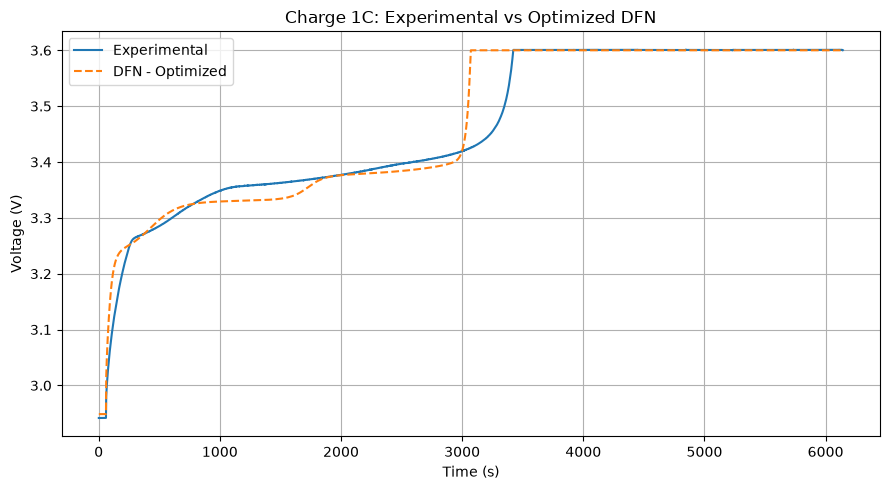

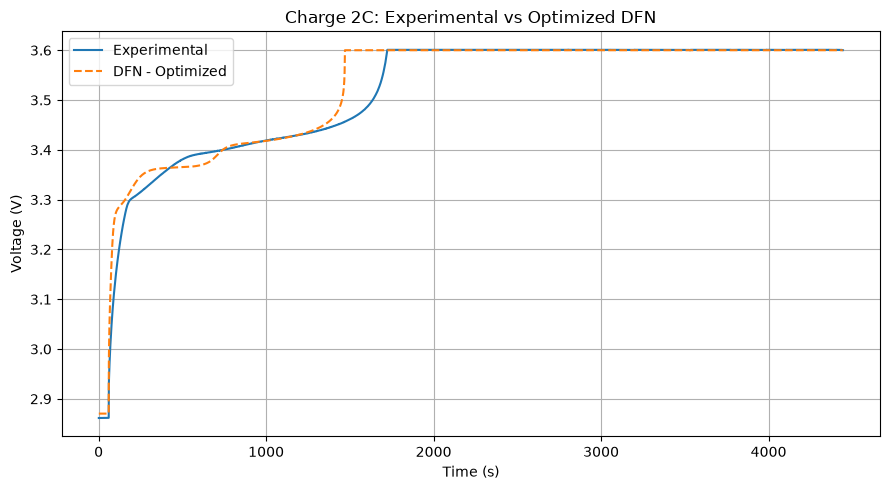

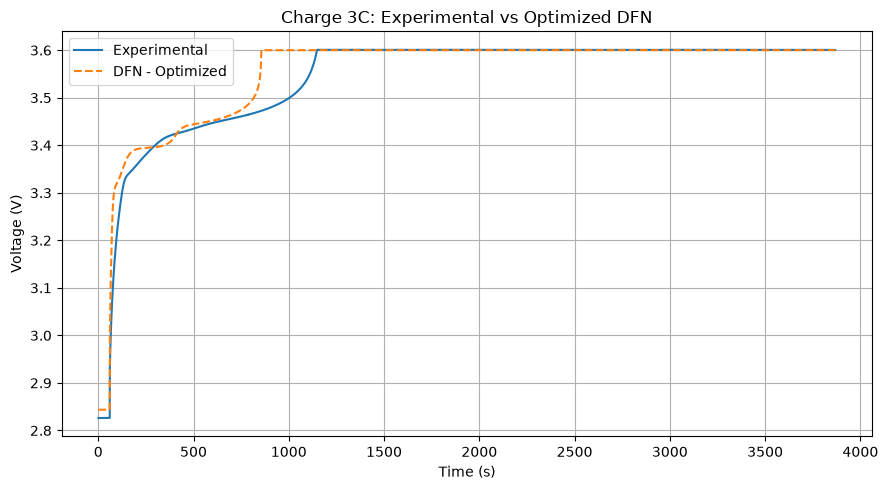

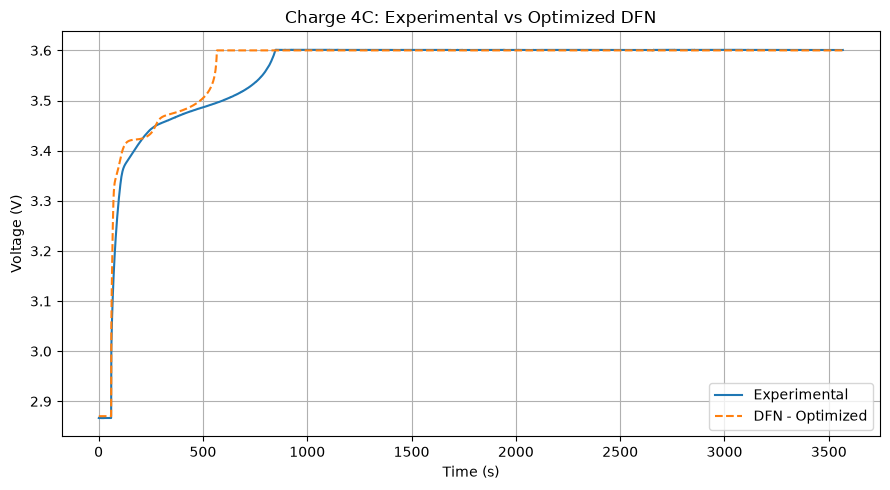

In [124]:
# ============================================================
# FINAL VOLTAGE COMPARISON PLOTS
# ============================================================

import matplotlib.pyplot as plt

final_charge_results = {}

for name, dataset in charge_datasets.items():

    initial_soc = charge_initial_soc[name]

    # Correct argument order:
    # dataset, initial_soc, x
    t_model, V_model = simulate_charge_for_optimization(
        dataset,
        initial_soc,
        x_final
    )

    t_exp = np.asarray(dataset["time"], dtype=float)
    V_exp = np.asarray(dataset["voltage"], dtype=float)

    # Sort experimental data
    order = np.argsort(t_exp)
    t_exp = t_exp[order]
    V_exp = V_exp[order]

    # Remove duplicate timestamps
    t_exp, idx = np.unique(t_exp, return_index=True)
    V_exp = V_exp[idx]

    # Interpolate model onto experimental time points
    V_model_interp = np.interp(
        t_exp,
        t_model,
        V_model
    )

    # Residual = Experimental - Model
    residual = V_exp - V_model_interp

    final_charge_results[name] = {
        "time": t_exp,
        "V_exp": V_exp,
        "V_model": V_model_interp,
        "residual": residual
    }

# Plot each charge dataset
for name, result in final_charge_results.items():

    plt.figure(figsize=(9, 5))

    plt.plot(
        result["time"],
        result["V_exp"],
        label="Experimental",
        linewidth=1.5
    )

    plt.plot(
        result["time"],
        result["V_model"],
        "--",
        label="DFN - Optimized",
        linewidth=1.5
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(f"{name}: Experimental vs Optimized DFN")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [125]:
t_model, V_model = simulate_charge_for_optimization(
    dataset=dataset,
    initial_soc=initial_soc,
    x=x_final
)

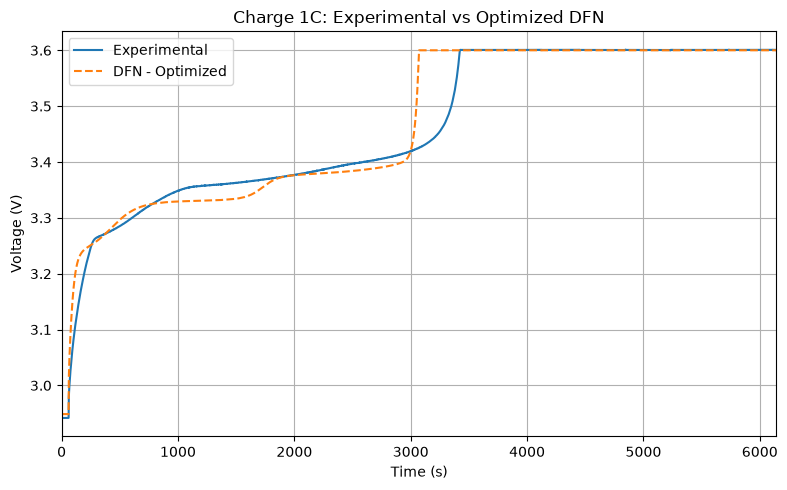

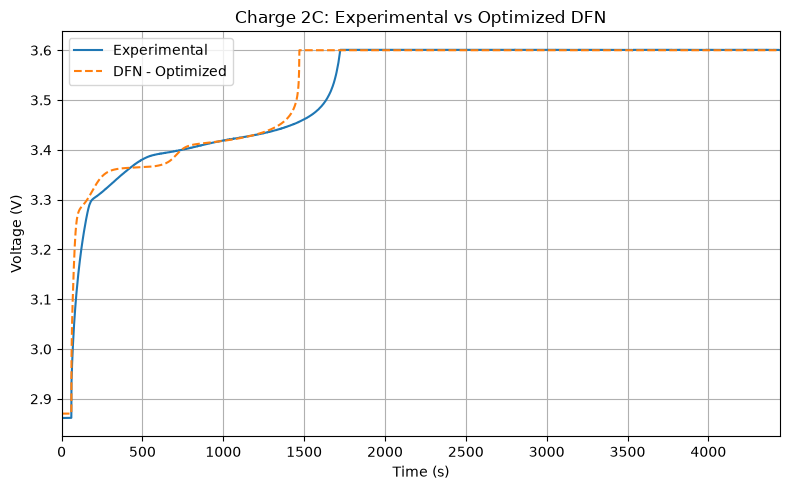

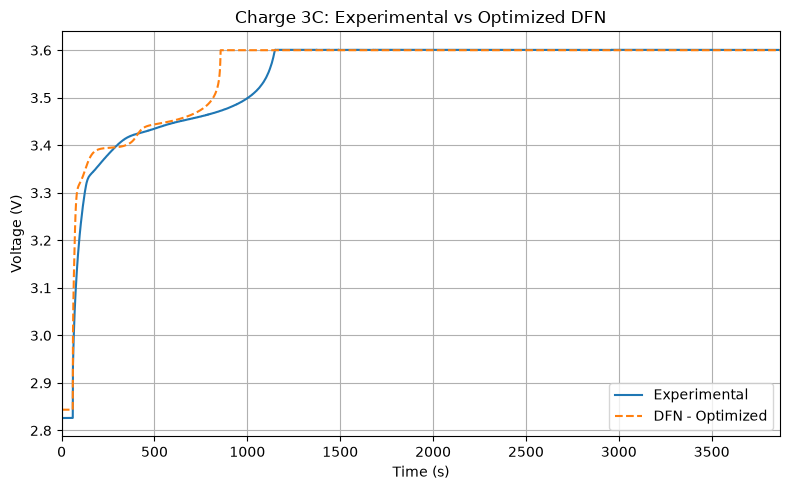

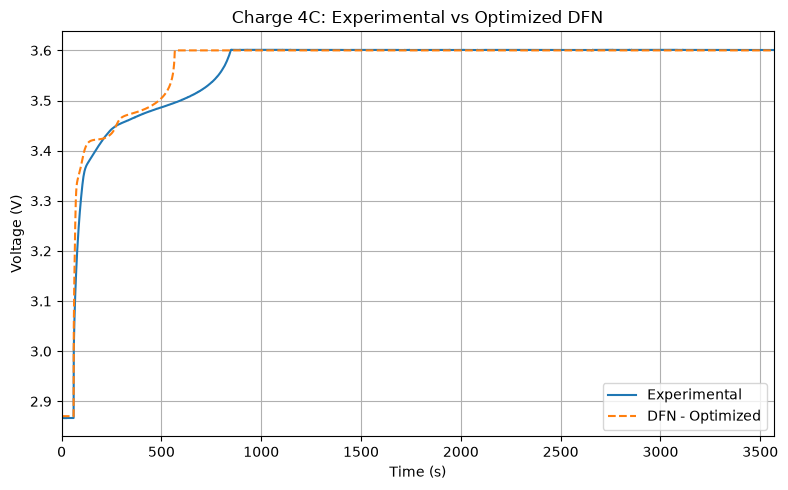

In [126]:
# ============================================================
# CLEAN FINAL CHARGE PLOTS
# ============================================================

for name, dataset in charge_datasets.items():

    initial_soc = charge_initial_soc[name]

    t_model, V_model = simulate_charge_for_optimization(
        dataset=dataset,
        initial_soc=initial_soc,
        x=x_final
    )

    t_exp = np.asarray(dataset["time"], dtype=float)
    V_exp = np.asarray(dataset["voltage"], dtype=float)

    # Sort experimental data
    order = np.argsort(t_exp)
    t_exp = t_exp[order]
    V_exp = V_exp[order]

    # Remove duplicate timestamps
    t_exp, idx = np.unique(t_exp, return_index=True)
    V_exp = V_exp[idx]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        t_exp,
        V_exp,
        label="Experimental",
        linewidth=1.5
    )

    # Plot ONLY the actual model solution
    plt.plot(
        t_model,
        V_model,
        "--",
        label="DFN - Optimized",
        linewidth=1.5
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(f"{name}: Experimental vs Optimized DFN")

    plt.xlim(
        0,
        max(t_exp[-1], t_model[-1])
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

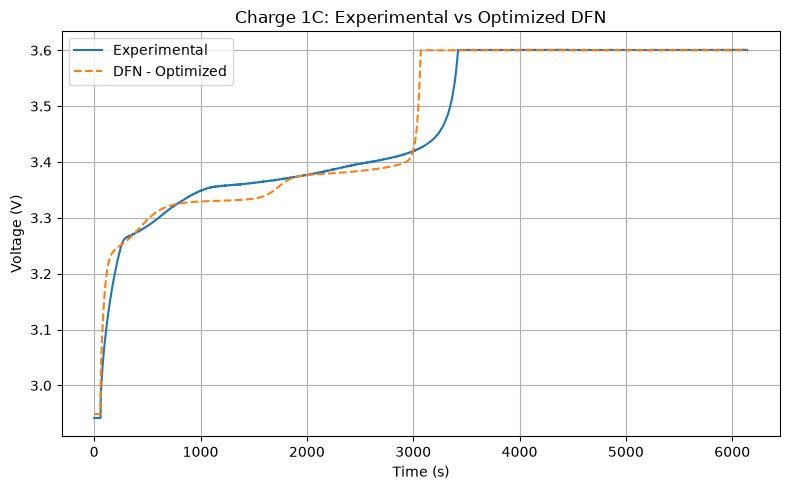

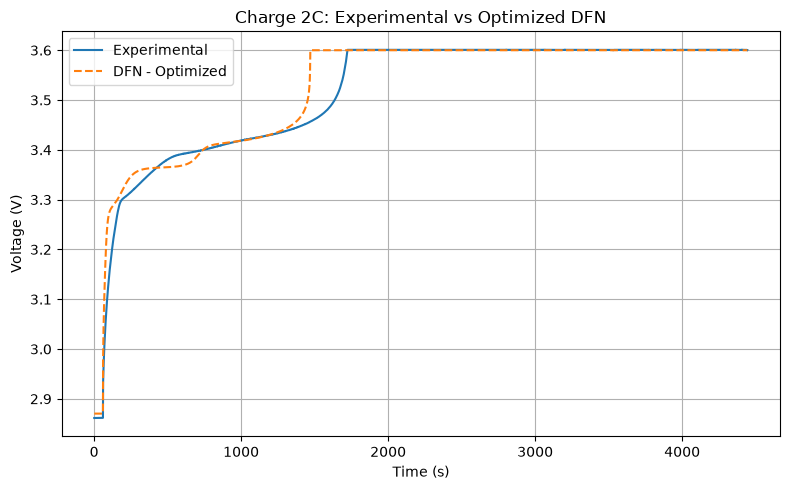

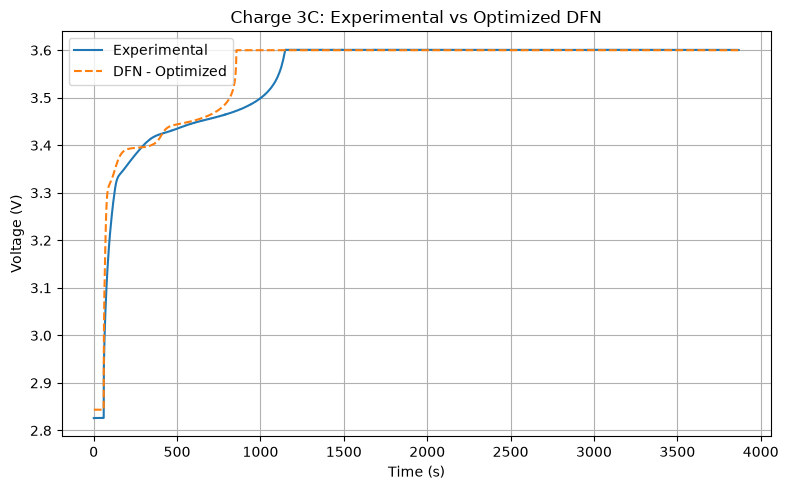

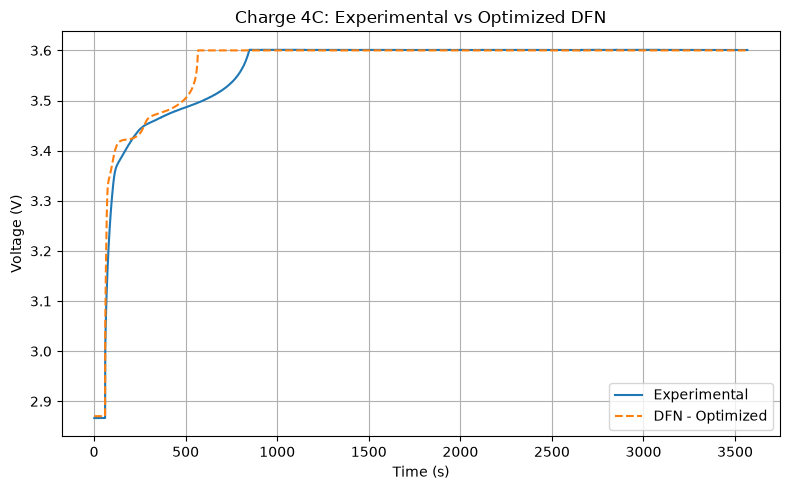

In [127]:
# ============================================================
# FINAL CLEAN CHARGE VALIDATION PLOTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

final_charge_results = {}

for name, dataset in charge_datasets.items():

    initial_soc = charge_initial_soc[name]

    t_model, V_model = simulate_charge_for_optimization(
        dataset=dataset,
        initial_soc=initial_soc,
        x=x_final
    )

    t_exp = np.asarray(dataset["time"], dtype=float)
    I_exp = np.asarray(dataset["current"], dtype=float)
    V_exp = np.asarray(dataset["voltage"], dtype=float)

    # Sort
    order = np.argsort(t_exp)
    t_exp = t_exp[order]
    I_exp = I_exp[order]
    V_exp = V_exp[order]

    # Remove duplicate times
    t_exp, idx = np.unique(t_exp, return_index=True)
    I_exp = I_exp[idx]
    V_exp = V_exp[idx]

    # Interpolate model only over its actual solution range
    valid = t_exp <= t_model[-1]

    t_compare = t_exp[valid]
    V_exp_compare = V_exp[valid]

    V_model_compare = np.interp(
        t_compare,
        t_model,
        V_model
    )

    residual = V_exp_compare - V_model_compare

    final_charge_results[name] = {
        "t_exp": t_exp,
        "V_exp": V_exp,
        "t_model": t_model,
        "V_model": V_model,
        "t_compare": t_compare,
        "V_exp_compare": V_exp_compare,
        "V_model_compare": V_model_compare,
        "residual": residual
    }

    # --------------------------------------------------------
    # Voltage plot
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        t_exp,
        V_exp,
        label="Experimental",
        linewidth=1.5
    )

    plt.plot(
        t_model,
        V_model,
        "--",
        label="DFN - Optimized",
        linewidth=1.5
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(f"{name}: Experimental vs Optimized DFN")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

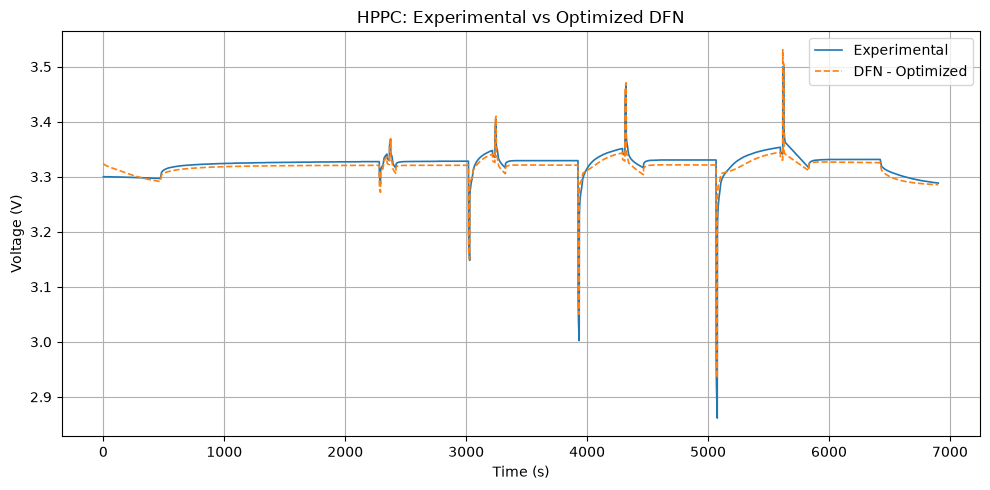

In [128]:
# ============================================================
# FINAL HPPC VALIDATION
# ============================================================

t_hppc_model, V_hppc_model = simulate_hppc(x_final)

V_hppc_model_interp = np.interp(
    t_hppc,
    t_hppc_model,
    V_hppc_model
)

hppc_residual = V_hppc - V_hppc_model_interp

plt.figure(figsize=(10, 5))

plt.plot(
    t_hppc,
    V_hppc,
    label="Experimental",
    linewidth=1.2
)

plt.plot(
    t_hppc_model,
    V_hppc_model,
    "--",
    label="DFN - Optimized",
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("HPPC: Experimental vs Optimized DFN")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

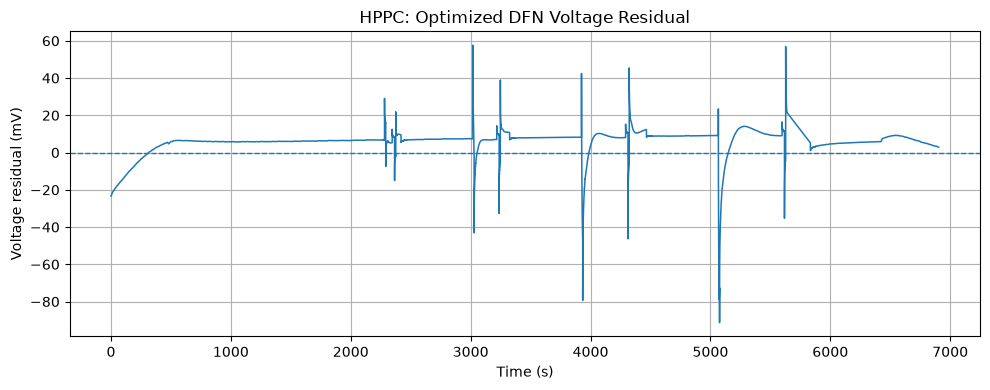

In [129]:
# ============================================================
# FINAL HPPC RESIDUAL
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t_hppc,
    hppc_residual * 1000,
    linewidth=1.1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage residual (mV)")
plt.title("HPPC: Optimized DFN Voltage Residual")

plt.grid(True)
plt.tight_layout()

plt.show()

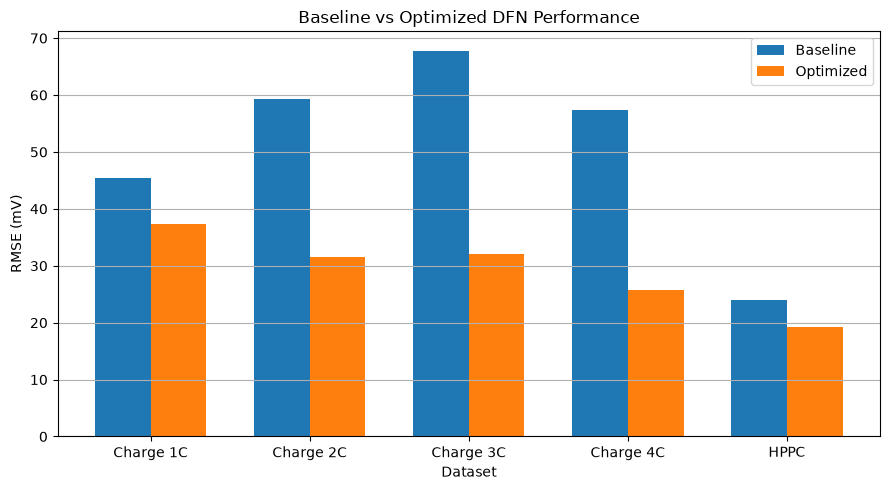

In [130]:
# ============================================================
# BASELINE VS OPTIMIZED RMSE
# ============================================================

dataset_names = list(baseline_rmse.keys())

baseline_values = np.array([
    baseline_rmse[name] * 1000
    for name in dataset_names
])

optimized_values = np.array([
    rmse_final[name] * 1000
    for name in dataset_names
])

x_pos = np.arange(len(dataset_names))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x_pos - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x_pos + width / 2,
    optimized_values,
    width,
    label="Optimized"
)

plt.xticks(x_pos, dataset_names)
plt.ylabel("RMSE (mV)")
plt.xlabel("Dataset")
plt.title("Baseline vs Optimized DFN Performance")

plt.legend()
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [131]:
# ============================================================
# PART 5 - FINAL VALIDATION
# FINAL OPTIMIZED PARAMETER SET
# ============================================================

x_final = np.array([
    0.02515325,   # Positive electrode OCP shift [V]
    3.53854046,   # Negative electrode j0 multiplier
    0.20000000,   # Electrolyte conductivity multiplier
    1.06383556    # Electrolyte diffusivity multiplier
])

print("=" * 75)
print("PART 5 - FINAL VALIDATION")
print("=" * 75)

print(f"Positive electrode OCP shift : {x_final[0]:.8f} V")
print(f"Negative j0 multiplier       : {x_final[1]:.8f} x")
print(f"Electrolyte conductivity    : {x_final[2]:.8f} x")
print(f"Electrolyte diffusivity     : {x_final[3]:.8f} x")

PART 5 - FINAL VALIDATION
Positive electrode OCP shift : 0.02515325 V
Negative j0 multiplier       : 3.53854046 x
Electrolyte conductivity    : 0.20000000 x
Electrolyte diffusivity     : 1.06383556 x


In [132]:
# ============================================================
# FULL HPPC SIMULATION FOR PART 5
# ============================================================

model_hppc_final = pybamm.lithium_ion.DFN()

params_hppc_final = make_parameter_values(x_final)

current_function_hppc = pybamm.Interpolant(
    t_hppc,
    I_hppc,
    pybamm.t
)

params_hppc_final["Current function [A]"] = current_function_hppc

sim_hppc_final = pybamm.Simulation(
    model=model_hppc_final,
    parameter_values=params_hppc_final
)

solution_hppc_final = sim_hppc_final.solve(
    t_eval=t_hppc,
    initial_soc=soc_hppc
)

print("HPPC simulation completed successfully.")
print(f"Simulation time points: {len(solution_hppc_final.t)}")

HPPC simulation completed successfully.
Simulation time points: 15356


In [133]:
# ============================================================
# HPPC VOLTAGE ERROR METRICS
# ============================================================

t_sim = solution_hppc_final.t

V_sim = solution_hppc_final[
    "Terminal voltage [V]"
].entries

# Interpolate simulation onto experimental time points
V_sim_interp = np.interp(
    t_hppc,
    t_sim,
    V_sim
)

# Experimental - simulated
V_error = V_hppc - V_sim_interp

# RMSE
rmse_hppc_final = np.sqrt(
    np.mean(V_error**2)
)

# MAE
mae_hppc_final = np.mean(
    np.abs(V_error)
)

# Maximum absolute error
max_error_hppc = np.max(
    np.abs(V_error)
)

print("\n" + "=" * 75)
print("PART 5 - HPPC VALIDATION METRICS")
print("=" * 75)

print(f"RMSE              : {rmse_hppc_final*1000:.3f} mV")
print(f"MAE               : {mae_hppc_final*1000:.3f} mV")
print(f"Maximum error     : {max_error_hppc*1000:.3f} mV")
print("=" * 75)


PART 5 - HPPC VALIDATION METRICS
RMSE              : 19.313 mV
MAE               : 14.182 mV
Maximum error     : 91.296 mV


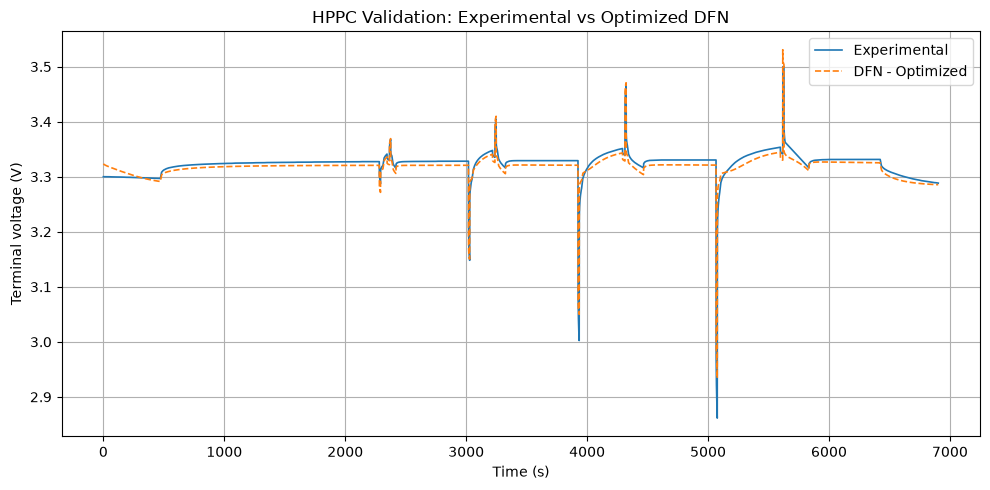

In [134]:
# ============================================================
# HPPC: EXPERIMENTAL VS OPTIMIZED DFN
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t_hppc,
    V_hppc,
    label="Experimental",
    linewidth=1.2
)

plt.plot(
    t_sim,
    V_sim,
    "--",
    label="DFN - Optimized",
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel("Terminal voltage (V)")
plt.title("HPPC Validation: Experimental vs Optimized DFN")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

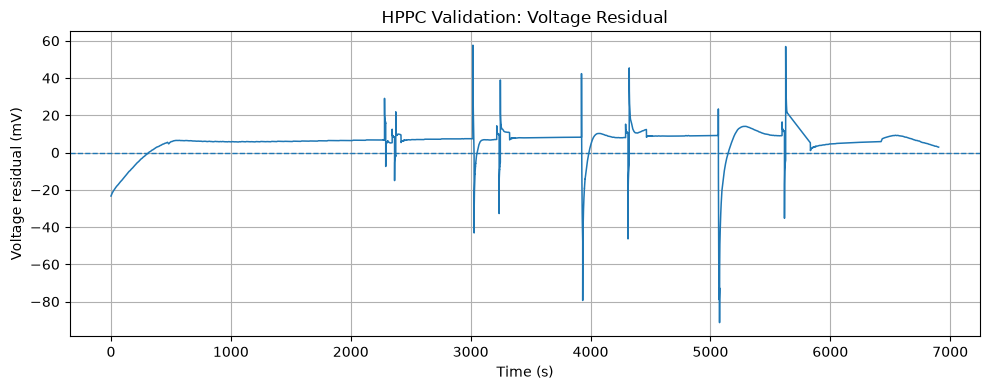

In [135]:
# ============================================================
# HPPC VOLTAGE RESIDUAL
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t_hppc,
    V_error * 1000,
    linewidth=1.1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage residual (mV)")
plt.title("HPPC Validation: Voltage Residual")

plt.grid(True)
plt.tight_layout()

plt.show()

In [136]:
# ============================================================
# CHECK ELECTRODE POTENTIAL VARIABLES
# ============================================================

available_variables = solution_hppc_final.all_models[0].variables.keys()

for variable_name in [
    "Negative electrode potential [V]",
    "Positive electrode potential [V]",
    "Electrolyte potential [V]",
    "Terminal voltage [V]"
]:
    if variable_name in available_variables:
        print("FOUND:", variable_name)
    else:
        print("NOT FOUND:", variable_name)

FOUND: Negative electrode potential [V]
FOUND: Positive electrode potential [V]
FOUND: Electrolyte potential [V]
FOUND: Terminal voltage [V]


Raw negative electrode potential shape: (20, 15356)
X-averaged negative electrode potential shape: (15356,)
Time shape: (15356,)


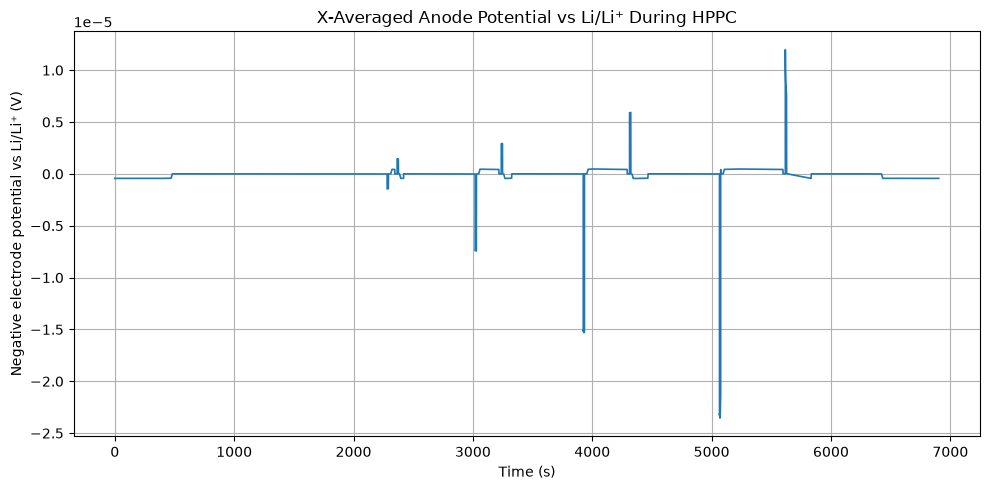

In [137]:
# ============================================================
# PART 5 - ANODE POTENTIAL VS Li/Li+
# X-AVERAGED NEGATIVE ELECTRODE POTENTIAL
# ============================================================

phi_n_raw = solution_hppc_final[
    "Negative electrode potential [V]"
].entries

print("Raw negative electrode potential shape:",
      phi_n_raw.shape)

# PyBaMM returns potential as:
# spatial points × time points
#
# Average over spatial direction
if phi_n_raw.ndim == 2:
    phi_n = np.mean(phi_n_raw, axis=0)
else:
    phi_n = phi_n_raw

print("X-averaged negative electrode potential shape:",
      phi_n.shape)

print("Time shape:",
      t_sim.shape)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    t_sim,
    phi_n,
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel(
    "Negative electrode potential vs Li/Li⁺ (V)"
)

plt.title(
    "X-Averaged Anode Potential vs Li/Li⁺ During HPPC"
)

plt.grid(True)
plt.tight_layout()

plt.show()

Raw positive electrode potential shape: (20, 15356)
X-averaged positive electrode potential shape: (15356,)


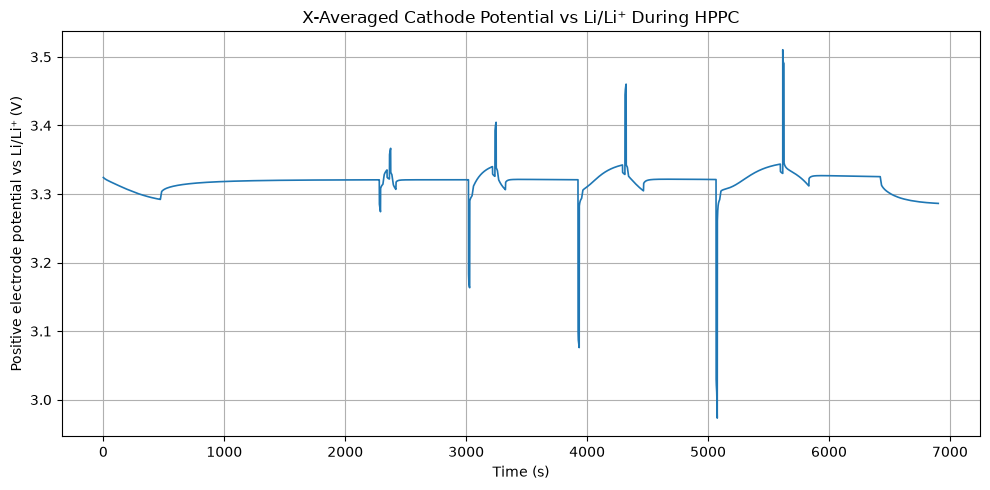

In [138]:
# ============================================================
# POSITIVE ELECTRODE POTENTIAL VS Li/Li+
# ============================================================

phi_p_raw = solution_hppc_final[
    "Positive electrode potential [V]"
].entries

print("Raw positive electrode potential shape:",
      phi_p_raw.shape)

if phi_p_raw.ndim == 2:
    phi_p = np.mean(phi_p_raw, axis=0)
else:
    phi_p = phi_p_raw

print("X-averaged positive electrode potential shape:",
      phi_p.shape)

plt.figure(figsize=(10, 5))

plt.plot(
    t_sim,
    phi_p,
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel(
    "Positive electrode potential vs Li/Li⁺ (V)"
)

plt.title(
    "X-Averaged Cathode Potential vs Li/Li⁺ During HPPC"
)

plt.grid(True)
plt.tight_layout()

plt.show()

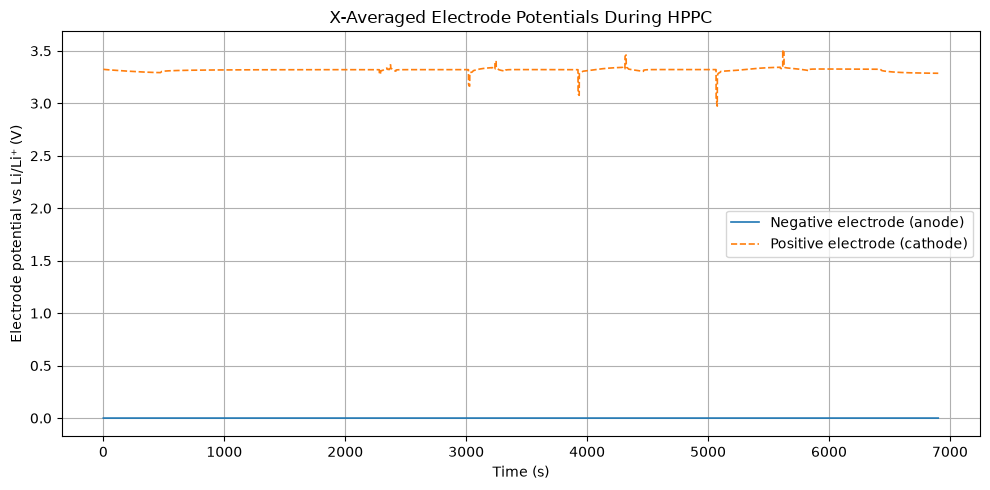

In [139]:
# ============================================================
# ELECTRODE POTENTIALS DURING HPPC
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t_sim,
    phi_n,
    label="Negative electrode (anode)",
    linewidth=1.2
)

plt.plot(
    t_sim,
    phi_p,
    "--",
    label="Positive electrode (cathode)",
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel("Electrode potential vs Li/Li⁺ (V)")

plt.title(
    "X-Averaged Electrode Potentials During HPPC"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Anode OCP shape: (15356,)


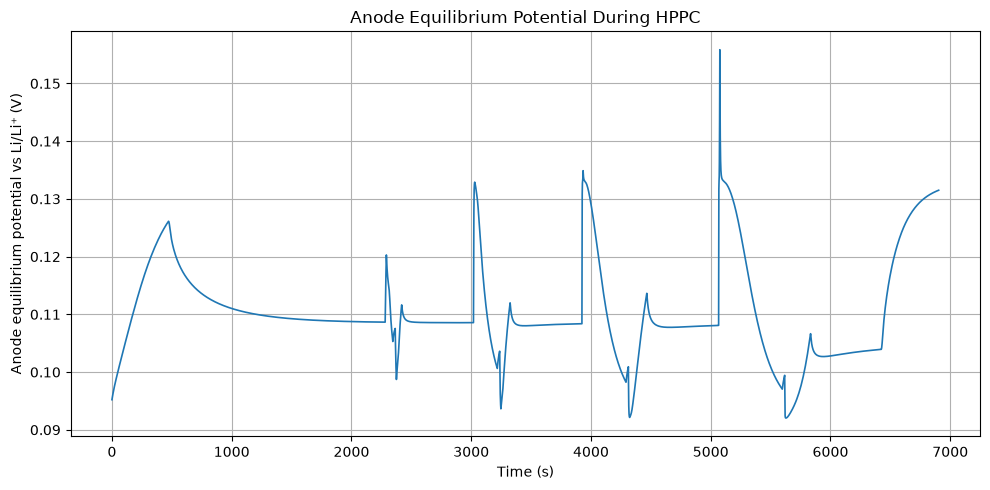

In [140]:
# ============================================================
# PART 5 - ANODE EQUILIBRIUM POTENTIAL
# ============================================================

phi_n_ocp = solution_hppc_final[
    "X-averaged negative electrode open-circuit potential [V]"
].entries

print("Anode OCP shape:", phi_n_ocp.shape)

plt.figure(figsize=(10, 5))

plt.plot(
    t_sim,
    phi_n_ocp,
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel("Anode equilibrium potential vs Li/Li⁺ (V)")
plt.title("Anode Equilibrium Potential During HPPC")

plt.grid(True)
plt.tight_layout()
plt.show()

In [141]:
# ============================================================
# FINAL PART 5 HPPC METRICS
# ============================================================

V_error = V_hppc - V_sim_interp

rmse_hppc = np.sqrt(
    np.mean(V_error**2)
)

mae_hppc = np.mean(
    np.abs(V_error)
)

max_abs_error = np.max(
    np.abs(V_error)
)

mean_error = np.mean(V_error)

std_error = np.std(V_error)

print("=" * 75)
print("PART 5 - FINAL HPPC VALIDATION")
print("=" * 75)

print(f"RMSE              = {rmse_hppc*1000:.3f} mV")
print(f"MAE               = {mae_hppc*1000:.3f} mV")
print(f"Maximum error     = {max_abs_error*1000:.3f} mV")
print(f"Mean error        = {mean_error*1000:.3f} mV")
print(f"Error std. dev.   = {std_error*1000:.3f} mV")
print("=" * 75)

PART 5 - FINAL HPPC VALIDATION
RMSE              = 19.313 mV
MAE               = 14.182 mV
Maximum error     = 91.296 mV
Mean error        = 0.688 mV
Error std. dev.   = 19.301 mV


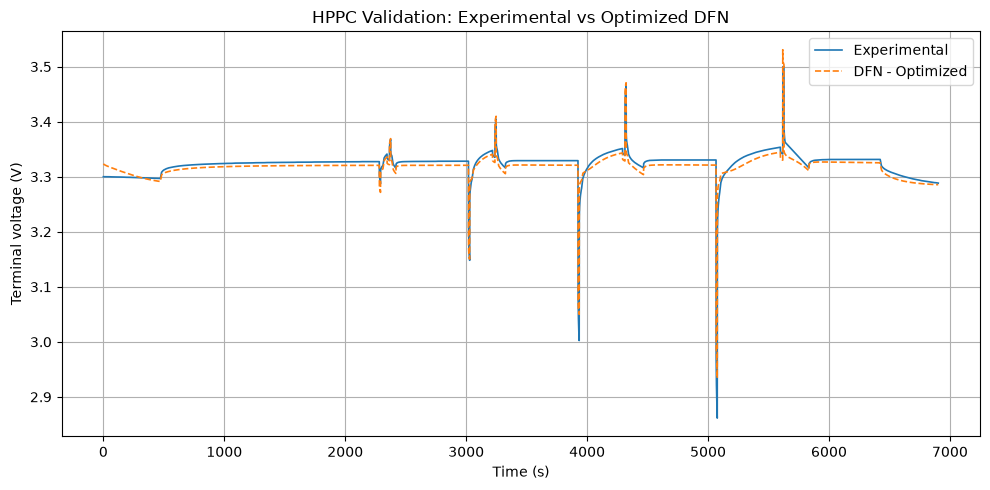

In [142]:
# ============================================================
# PART 5 - FINAL HPPC VOLTAGE VALIDATION FIGURE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t_hppc,
    V_hppc,
    label="Experimental",
    linewidth=1.2
)

plt.plot(
    t_sim,
    V_sim,
    "--",
    label="DFN - Optimized",
    linewidth=1.2
)

plt.xlabel("Time (s)")
plt.ylabel("Terminal voltage (V)")
plt.title("HPPC Validation: Experimental vs Optimized DFN")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

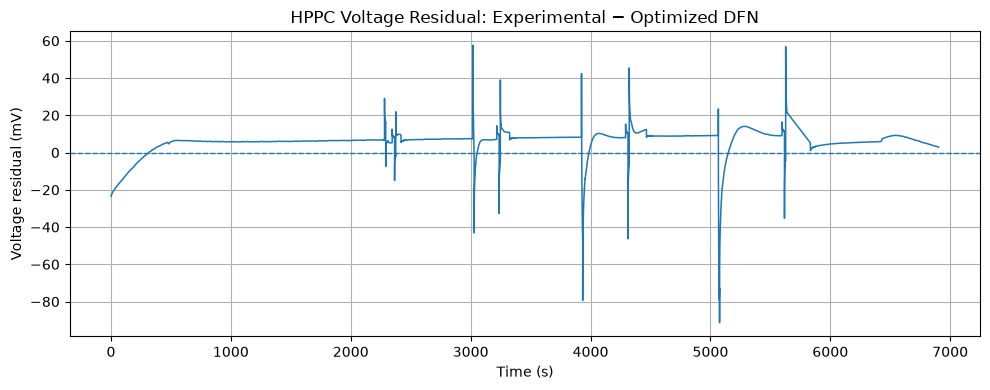

In [143]:
# ============================================================
# PART 5 - FINAL HPPC RESIDUAL
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t_hppc,
    V_error * 1000,
    linewidth=1.1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage residual (mV)")
plt.title("HPPC Voltage Residual: Experimental − Optimized DFN")

plt.grid(True)
plt.tight_layout()
plt.show()

In [144]:
import json
import os

# Save in the current Jupyter working directory
save_folder = os.getcwd()

# Create the JSON file path
json_path = os.path.join(
    save_folder,
    "optimized_parameters.json"
)

optimized_parameters = {
    "model": "Doyle-Fuller-Newman (DFN)",
    "base_parameter_set": "Prada2013",
    "optimization_method": "L-BFGS-B",

    "optimized_parameters": {
        "Positive OCP shift [V]": 0.02515325,
        "Negative electrode exchange-current density multiplier": 3.53854046,
        "Electrolyte conductivity multiplier": 0.20000000,
        "Electrolyte diffusivity multiplier": 1.06383556
    },

    "parameter_bounds": {
        "Positive OCP shift [V]": [0.0, 0.04],
        "Negative electrode exchange-current density multiplier": [0.5, 4.0],
        "Electrolyte conductivity multiplier": [0.2, 1.5],
        "Electrolyte diffusivity multiplier": [0.2, 3.0]
    },

    "validation_results": {
        "Charge 1C": {
            "RMSE [mV]": 37.252,
            "MAE [mV]": 16.114
        },
        "Charge 2C": {
            "RMSE [mV]": 31.581,
            "MAE [mV]": 11.954
        },
        "Charge 3C": {
            "RMSE [mV]": 31.999,
            "MAE [mV]": 12.529
        },
        "Charge 4C": {
            "RMSE [mV]": 25.690,
            "MAE [mV]": 9.803
        },
        "HPPC": {
            "RMSE [mV]": 19.313,
            "MAE [mV]": 14.182
        },
        "Mean": {
            "RMSE [mV]": 29.167,
            "MAE [mV]": 12.916
        }
    }
}

# Save JSON
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(optimized_parameters, f, indent=4)

print("=" * 70)
print("JSON FILE SAVED SUCCESSFULLY")
print("=" * 70)
print(f"Location: {json_path}")

JSON FILE SAVED SUCCESSFULLY
Location: C:\Users\hp\Desktop\MEAtec\optimized_parameters.json


In [145]:
save_folder = os.path.join(os.getcwd(), "parameters")
os.makedirs(save_folder, exist_ok=True)

json_path = os.path.join(
    save_folder,
    "optimized_parameters.json"
)

In [146]:
import json
import os

# ============================================================
# SAVE OPTIMIZED PARAMETERS DIRECTLY FROM OPTIMIZATION
# ============================================================

# x_opt_expanded comes directly from the L-BFGS-B optimization
print("Optimized parameter vector:")
print(x_opt_expanded)

# Save in current Jupyter working directory
save_folder = os.getcwd()

json_path = os.path.join(
    save_folder,
    "optimized_parameters.json"
)

# Create dictionary directly from optimization result
optimized_parameters = {
    "Positive OCP shift [V]": float(x_opt_expanded[0]),
    "Negative electrode exchange-current density multiplier": float(x_opt_expanded[1]),
    "Electrolyte conductivity multiplier": float(x_opt_expanded[2]),
    "Electrolyte diffusivity multiplier": float(x_opt_expanded[3])
}

# Save
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(optimized_parameters, f, indent=4)

print("\n" + "=" * 70)
print("OPTIMIZED PARAMETERS SAVED")
print("=" * 70)
print(f"File: {json_path}")
print("\nSaved values:")

for name, value in optimized_parameters.items():
    print(f"{name:<65} = {value}")

Optimized parameter vector:
[0.02515325 3.53854046 0.2        1.06383556]

OPTIMIZED PARAMETERS SAVED
File: C:\Users\hp\Desktop\MEAtec\optimized_parameters.json

Saved values:
Positive OCP shift [V]                                            = 0.025153253153150527
Negative electrode exchange-current density multiplier            = 3.5385404565300274
Electrolyte conductivity multiplier                               = 0.2
Electrolyte diffusivity multiplier                                = 1.0638355595206326


Anode reaction overpotential shape: (15356,)


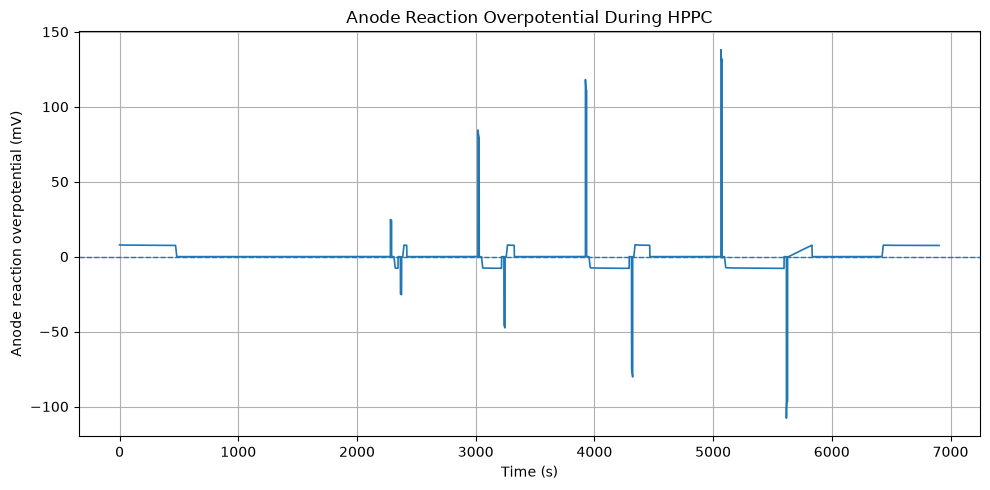

In [147]:
# ============================================================
# NEGATIVE ELECTRODE REACTION OVERPOTENTIAL
# ============================================================

eta_n = solution_hppc_final[
    "X-averaged negative electrode reaction overpotential [V]"
].entries

print("Anode reaction overpotential shape:", eta_n.shape)

plt.figure(figsize=(10, 5))

plt.plot(
    t_sim,
    eta_n * 1000,
    linewidth=1.2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Anode reaction overpotential (mV)")
plt.title("Anode Reaction Overpotential During HPPC")

plt.grid(True)
plt.tight_layout()
plt.show()